# CRISP-DM — Modelamiento y Evaluacion de Riesgo Trimestral v3

Este notebook implementa la fase de modelamiento del proceso CRISP-DM para la prediccion del score de riesgo trimestral.
El dataset utilizado es `training_dataset_riesgo_trimestral_v3.csv`, que contiene variables financieras, flags de distress
y ratios de empresas listadas en mercados regulados.

**Variables objetivo:**

| Variable | Tipo | Tarea |
|---|---|---|
| `risk_score_next` | Continua [0,1] | Regresion |
| `target_residual_next` | Continua [-1,1] | Regresion (componente residual) |
| `target_distress_next` | Binaria {0,1} | Clasificacion binaria |
| `target_class_next` | Multiclase {0,1,2} | Clasificacion multiclase |

**Division temporal:**
- Entrenamiento: registros con `fy <= ANIO_CORTE_TRAIN`
- Validacion: registros con `fy > ANIO_CORTE_TRAIN`

---

## 0. Instalacion de Dependencias

In [2]:
# Liberias locales
!pip install --ignore-installed matplotlib

  Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\DataSecJaveriana\\.venv\\Lib\\site-packages\\PIL\\_imaging.cp311-win_amd64.pyd'
Check the permissions.



In [3]:
# Instalacion de librerias necesarias para el notebook.
# Se verifica la existencia de cada paquete antes de intentar instalarlo.

import subprocess
import sys

paquetes_requeridos = [
    ('xgboost',         'xgboost'),
    ('lightgbm',        'lightgbm'),
    ('ydata_profiling', 'ydata-profiling[notebook]'),
    ('imblearn',        'imbalanced-learn'),
    ('optuna',          'optuna'),
    ('torch',           'torch'),
    ('torch_geometric', 'torch_geometric'),
]

for modulo, paquete in paquetes_requeridos:
    try:
        __import__(modulo)
        print(f'OK: {paquete}')
    except ImportError:
        print(f'Instalando: {paquete}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', paquete, '-q'])
        print(f'Instalado:  {paquete}')

print('\nDependencias listas.')

OK: xgboost
OK: lightgbm
OK: ydata-profiling[notebook]
OK: imbalanced-learn
OK: optuna
OK: torch
OK: torch_geometric

Dependencias listas.


## 1. Importaciones y Configuracion Global

In [4]:
# Importacion de todas las librerias utilizadas en el notebook.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
import copy

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# -- Preprocesamiento --------------------------------------------------------
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# -- Modelos sklearn ----------------------------------------------------------
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier
)

# -- Boosting ----------------------------------------------------------------
import xgboost as xgb
import lightgbm as lgb

# -- PyTorch -----------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# -- PyTorch Geometric (GNN) -------------------------------------------------
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from torch_geometric.loader import DataLoader as PyGLoader

# -- Balanceo ----------------------------------------------------------------
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from collections import Counter

# -- Metricas ----------------------------------------------------------------
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# -- Configuracion global ----------------------------------------------------
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
RANDOM_STATE = 42
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f'XGBoost {xgb.__version__} | LightGBM {lgb.__version__} | Optuna {optuna.__version__}')
print(f'PyTorch {torch.__version__} | Dispositivo: {DEVICE}')
print('Importaciones completadas.')

XGBoost 3.2.0 | LightGBM 4.6.0 | Optuna 4.8.0
PyTorch 2.11.0+cpu | Dispositivo: cpu
Importaciones completadas.


## 2. Parametros de Division Temporal

Se modifica esta celda para controlar los cortes de entrenamiento y validacion sin alterar el resto del notebook.

In [5]:
# ===========================================================================
# PARAMETROS DE DIVISION TEMPORAL
# Se modifica ANIO_CORTE_TRAIN para cambiar el punto de corte.
# Entrenamiento: fy <= ANIO_CORTE_TRAIN
# Validacion   : fy >  ANIO_CORTE_TRAIN
# ===========================================================================

ANIO_CORTE_TRAIN = 2023   # Cambiar este valor para probar distintos cortes

# Columna del dataset que representa el anio fiscal
COL_TIEMPO = 'fy'

print(f'Corte temporal definido: fy <= {ANIO_CORTE_TRAIN} --> Entrenamiento')
print(f'                         fy >  {ANIO_CORTE_TRAIN} --> Validacion')

Corte temporal definido: fy <= 2023 --> Entrenamiento
                         fy >  2023 --> Validacion


## 3. Carga del Dataset

In [6]:
# Carga del dataset desde la ruta especificada.
# Se recomienda colocar el archivo en el mismo directorio del notebook
# o ajustar la ruta DATA_PATH segun corresponda.

DATA_PATH = '../../data_variables_crudas/training_dataset_riesgo_trimestral_v3.csv'

df = pd.read_csv(DATA_PATH)

print(f'Dataset cargado: {df.shape[0]:,} registros x {df.shape[1]} columnas')
print(f'Rango temporal: fy {df[COL_TIEMPO].min()} - {df[COL_TIEMPO].max()}')
print()
df.head(10)

Dataset cargado: 89,441 registros x 119 columnas
Rango temporal: fy 2013 - 2025



,stprba,sic,countryba,adsh,cik,name,form,period,filed,fy,...,_REDUNDANTE_fe_anual_cash_operating,_REDUNDANTE_fe_anual_net_income,_REDUNDANTE_fe_flag_insolvencia,_REDUNDANTE_fe_ratio_quick,fe_clipped_fe_ratio_cashflow_deuda,fe_clipped_fe_shares_book_value,fe_clipped_fe_shares_assets_per_share,fe_clipped_fe_delta_liquidez_qoq,fe_clipped_fe_delta_apalancamiento_qoq,fe_sic_division
0,NY,5122.0,US,0001144204-18-051414,2034,ACETO CORP,10-K,20180630.0,1970-01-01 00:00:00.020180928,2018,...,1.018060e+08,-3.161210e+08,0.0,1.208361,0,0,0,0,0,F
1,NY,5122.0,US,0001144204-18-058572,2034,ACETO CORP,10-Q,20180930.0,1970-01-01 00:00:00.020181109,2019,...,-1.857400e+08,-8.436800e+07,0.0,1.078218,0,0,0,0,0,F
2,CT,3420.0,US,0001026608-18-000019,2098,ACME UNITED CORP,10-Q,20180331.0,1970-01-01 00:00:00.020180510,2018,...,-1.830000e+07,3.056000e+06,0.0,2.538958,0,0,0,0,0,D
3,CT,3420.0,US,0001026608-18-000027,2098,ACME UNITED CORP,10-Q,20180630.0,1970-01-01 00:00:00.020180809,2018,...,-1.049400e+07,6.400000e+06,0.0,2.210425,0,0,0,0,0,D
4,CT,3420.0,US,0001026608-18-000047,2098,ACME UNITED CORP,10-Q,20180930.0,1970-01-01 00:00:00.020181109,2018,...,-5.994667e+06,5.342667e+06,0.0,3.277474,0,0,0,0,0,D
5,CT,3420.0,US,0001026608-19-000011,2098,ACME UNITED CORP,10-K,20181231.0,1970-01-01 00:00:00.020190315,2018,...,4.475269e+06,4.598350e+06,0.0,2.368929,0,0,0,0,0,D
6,CT,3420.0,US,0001026608-19-000026,2098,ACME UNITED CORP,10-Q,20190331.0,1970-01-01 00:00:00.020190509,2019,...,-2.732000e+06,3.228000e+06,0.0,2.760028,0,0,0,0,0,D
7,CT,3420.0,US,0001026608-19-000033,2098,ACME UNITED CORP,10-Q,20190630.0,1970-01-01 00:00:00.020190807,2019,...,1.768000e+06,6.956000e+06,0.0,2.186759,0,0,0,0,0,D
8,CT,3420.0,US,0001026608-19-000043,2098,ACME UNITED CORP,10-Q,20190930.0,1970-01-01 00:00:00.020191107,2019,...,9.690667e+06,6.049333e+06,0.0,2.295556,0,0,0,0,0,D
9,CT,3420.0,US,0001564590-20-010850,2098,ACME UNITED CORP,10-K,20191231.0,1970-01-01 00:00:00.020200313,2019,...,1.470223e+07,5.513608e+06,0.0,2.043344,0,0,0,0,0,D


In [7]:
# ============================================================================
# VALIDACIÓN PREVIA — Integridad del CSV v3
# ----------------------------------------------------------------------------
# Esta celda no modifica el dataset, solo verifica que sea el correcto.
# Si alguno de los checks falla, hay que resolver antes de continuar.
# ============================================================================

print("="*72)
print("VALIDACIÓN PREVIA — ¿El CSV es realmente el v3 oficial?")
print("="*72)

# --- Check 1: Dimensiones esperadas según REPORTE_FASE1 y RESUMEN_SPRINT2_V3
print(f"\n[1] Dimensiones del dataset:")
print(f"    Filas    : {df.shape[0]:>7,}   (esperado: 89,441)")
print(f"    Columnas : {df.shape[1]:>7,}   (esperado: 119)")
ok_filas = df.shape[0] == 89441
ok_cols  = df.shape[1] == 119
print(f"    Filas OK?    {'OK' if ok_filas else 'DIFIERE DEL REPORTE'}")
print(f"    Columnas OK? {'OK' if ok_cols else 'DIFIERE DEL REPORTE'}")

# --- Check 2: Rango temporal
print(f"\n[2] Rango temporal:")
print(f"    fy min : {df['fy'].min()}   (esperado: 2013)")
print(f"    fy max : {df['fy'].max()}   (esperado: 2025)")

# --- Check 3: Empresas únicas
print(f"\n[3] Empresas únicas (CIK):")
n_empresas = df['cik'].nunique()
print(f"    {n_empresas:,}   (esperado: 5,291)")
print(f"    OK? {'OK' if n_empresas == 5291 else 'DIFIERE'}")

# --- Check 4: ¿Existe 'risk_score_prev' (debería estar ELIMINADA en v3)?
print(f"\n[4] Variable 'risk_score_prev' (debería NO existir en v3):")
existe_prev = 'risk_score_prev' in df.columns
if existe_prev:
    print(f"    EXISTE — versión vieja del CSV o merge mal hecho")
    print(f"    Reemplazada en v3 por 'fe_delta_risk_score_prev'")
else:
    print(f"    OK — no existe")

# --- Check 5: Columnas duplicadas (sufijo .1)
print(f"\n[5] Columnas duplicadas (sufijo .1):")
duplicadas = [c for c in df.columns if c.endswith('.1')]
if duplicadas:
    print(f"    DUPLICADAS detectadas: {duplicadas}")
    print(f"    Probable merge mal hecho. El notebook excluye 'risk_score_0_1.1',")
    print(f"    pero conviene revisar si hay otras")
else:
    print(f"    OK — sin duplicados")

# --- Check 6: Variables clave presentes
print(f"\n[6] Variables clave presentes:")
clave = {
    'altman_zscore'       : 'INGREDIENTE — NO debe ir al modelo',
    'risk_score_0_1'      : 'INGREDIENTE — NO debe ir al modelo',
    'risk_score_next'     : 'TARGET regresión',
    'target_residual_next': 'TARGET nuevo en v2',
    'target_distress_next': 'TARGET binario',
    'target_class_next'   : 'TARGET multiclase',
    'fe_ctx_sic_sector'   : 'Ordinal SIC (67 valores)',
    'fe_sic_division'     : 'String SIC (A-J)',
}
for c, desc in clave.items():
    estado = 'OK' if c in df.columns else 'FALTA'
    print(f"    [{estado:5}] {c:25} -- {desc}")

# --- Check 7: Columnas Cat A prohibidas que se hayan colado
print(f"\n[7] Columnas Cat A prohibidas (NO deberían estar en el CSV):")
prohibidas = [
    'fe_zscore_x1_wc_assets', 'fe_zscore_x2_re_assets',
    'fe_zscore_x3_ebit_assets', 'fe_zscore_x4_equity_liab',
    'fe_zscore_x5_rev_assets',
    'fe_zscore_altman', 'fe_zscore_risk_score',
    'fe_flag_altman_distress', 'fe_flag_altman_grey'
]
coladas = [c for c in prohibidas if c in df.columns]
if coladas:
    print(f"    COLADAS: {coladas}")
    print(f"    Hay leakage en el CSV — el Builder no las excluyó")
else:
    print(f"    OK — ninguna Cat A en el CSV")

# --- Check 8: Conteo de dummies sectoriales
print(f"\n[8] Dummies sectoriales 'fe_sic_div_*':")
dummies_sic = sorted([c for c in df.columns if c.startswith('fe_sic_div_')])
print(f"    Encontradas: {len(dummies_sic)}")
for d in dummies_sic:
    pct = df[d].mean() * 100
    print(f"      {d:18} -> {pct:5.2f}% positivos")

# --- Check 9: Conteo de columnas REDUNDANTE
print(f"\n[9] Columnas marcadas como _REDUNDANTE_:")
redundantes = sorted([c for c in df.columns if c.startswith('_REDUNDANTE_')])
print(f"    Encontradas: {len(redundantes)}  (esperado: 4)")
for r in redundantes:
    print(f"      {r}")

# --- Check 10: NaN totales en el dataset
print(f"\n[10] NaN totales en el dataset:")
total_nan = df.isnull().sum().sum()
print(f"     Total: {total_nan:,}")
if total_nan > 0:
    cols_con_nan = df.isnull().sum()
    cols_con_nan = cols_con_nan[cols_con_nan > 0].sort_values(ascending=False)
    print(f"     Columnas con NaN ({len(cols_con_nan)}):")
    for c, n in cols_con_nan.head(10).items():
        print(f"       {c:40} {n:,} NaN ({n/len(df)*100:.1f}%)")

print("\n" + "="*72)
print("FIN DE VALIDACIÓN PREVIA")
print("="*72)

VALIDACIÓN PREVIA — ¿El CSV es realmente el v3 oficial?

[1] Dimensiones del dataset:
    Filas    :  89,441   (esperado: 89,441)
    Columnas :     119   (esperado: 119)
    Filas OK?    OK
    Columnas OK? OK

[2] Rango temporal:
    fy min : 2013   (esperado: 2013)
    fy max : 2025   (esperado: 2025)

[3] Empresas únicas (CIK):
    5,291   (esperado: 5,291)
    OK? OK

[4] Variable 'risk_score_prev' (debería NO existir en v3):
    OK — no existe

[5] Columnas duplicadas (sufijo .1):
    OK — sin duplicados

[6] Variables clave presentes:
    [OK   ] altman_zscore             -- INGREDIENTE — NO debe ir al modelo
    [OK   ] risk_score_0_1            -- INGREDIENTE — NO debe ir al modelo
    [OK   ] risk_score_next           -- TARGET regresión
    [OK   ] target_residual_next      -- TARGET nuevo en v2
    [OK   ] target_distress_next      -- TARGET binario
    [OK   ] target_class_next         -- TARGET multiclase
    [OK   ] fe_ctx_sic_sector         -- Ordinal SIC (67 valores)
 

## 4. Perfil Exploratorio del Dataset (EDA)

### 4.1 Inspeccion General

In [8]:
# Inspeccion basica: tipos de dato, nulos y estadisticas descriptivas.

print('=== Tipos de dato y nulos ===')
info_df = pd.DataFrame({
    'dtype'   : df.dtypes,
    'nulos'   : df.isnull().sum(),
    'pct_nulo': (df.isnull().sum() / len(df) * 100).round(2),
    'unicos'  : df.nunique(),
})
print(info_df.to_string())
print()
print('=== Estadisticas descriptivas (variables numericas) ===')
df.describe().T

=== Tipos de dato y nulos ===
                                          dtype  nulos  pct_nulo  unicos
stprba                                   object   5144      5.75      57
sic                                     float64      0      0.00     394
countryba                                object    187      0.21      53
adsh                                     object      0      0.00   89441
cik                                       int64      0      0.00    5291
name                                     object      0      0.00    6212
form                                     object      0      0.00       4
period                                  float64      0      0.00     156
filed                                    object      0      0.00    2890
fy                                        int64      0      0.00      13
fp                                       object      0      0.00       4
fye                                     float64      0      0.00      14
altman_zscore        

,count,mean,std,min,25%,50%,75%,max
sic,89441.0,4.872814e+03,2118.002058,100.0,2860.0,4400.0,7310.0,9995.0
cik,89441.0,1.236029e+06,467149.711675,2034.0,1003078.0,1351636.0,1588014.0,2054696.0
period,89441.0,2.020182e+07,31556.817188,20120531.0,20180630.0,20210228.0,20230331.0,20251031.0
fy,89441.0,2.020161e+03,3.169945,2013.0,2018.0,2021.0,2023.0,2025.0
fye,89441.0,1.099208e+03,291.306514,131.0,1231.0,1231.0,1231.0,1231.0
...,...,...,...,...,...,...,...,...
fe_clipped_fe_ratio_cashflow_deuda,89441.0,6.160486e-03,0.078247,0.0,0.0,0.0,0.0,1.0
fe_clipped_fe_shares_book_value,89441.0,6.395277e-03,0.079715,0.0,0.0,0.0,0.0,1.0
fe_clipped_fe_shares_assets_per_share,89441.0,7.714583e-03,0.087494,0.0,0.0,0.0,0.0,1.0
fe_clipped_fe_delta_liquidez_qoq,89441.0,4.393958e-03,0.066142,0.0,0.0,0.0,0.0,1.0


### 4.2 Distribucion de Variables Objetivo

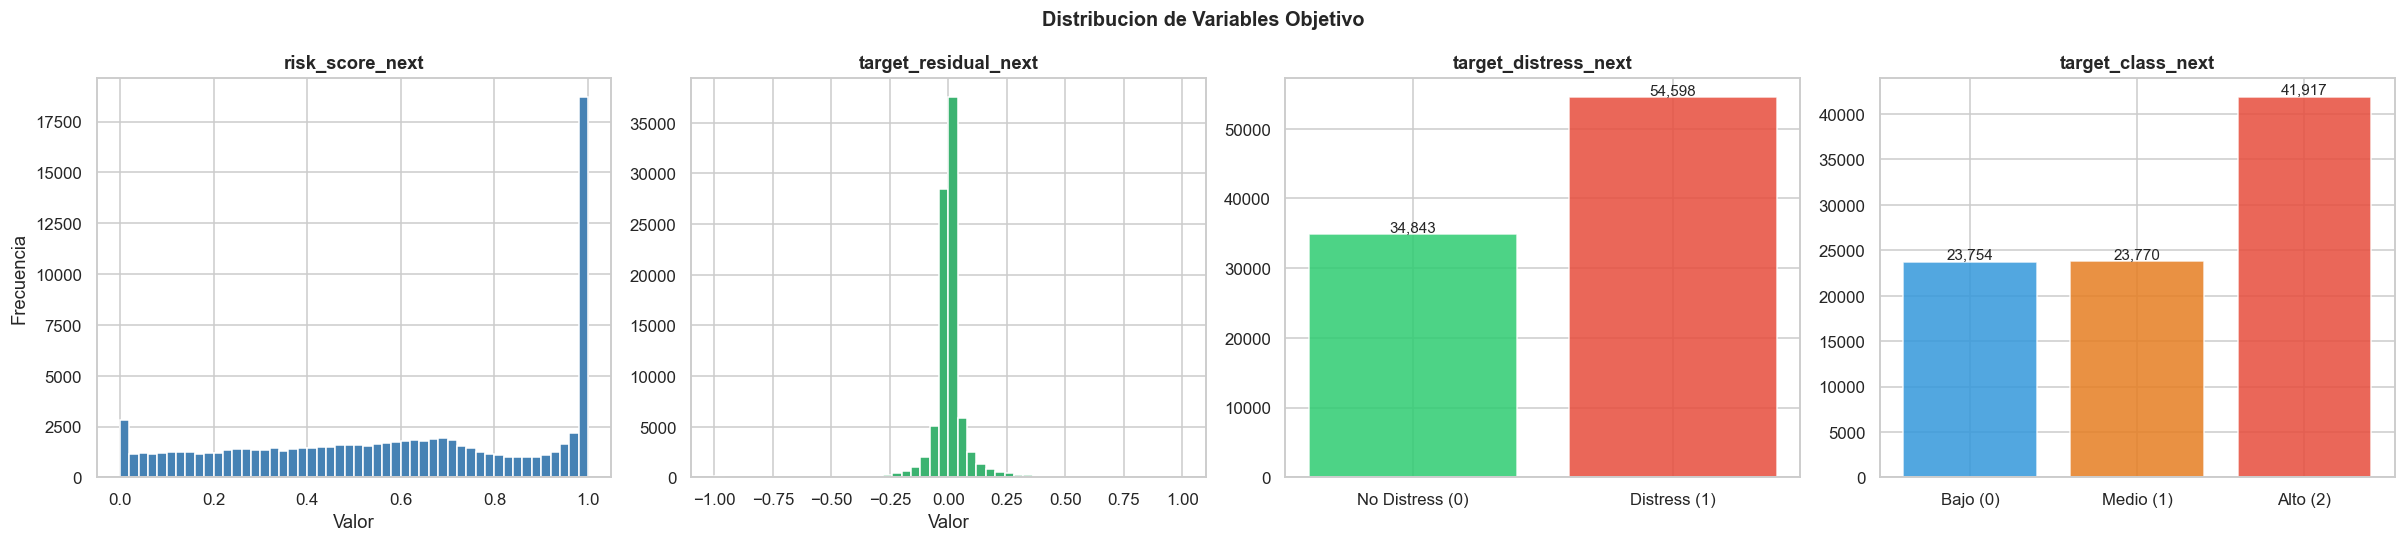

In [9]:
# Visualizacion de la distribucion de las cuatro variables objetivo.

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# risk_score_next
axes[0].hist(df['risk_score_next'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('risk_score_next', fontweight='bold')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')

# target_residual_next
axes[1].hist(df['target_residual_next'], bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_title('target_residual_next', fontweight='bold')
axes[1].set_xlabel('Valor')

# target_distress_next
vc_bin = df['target_distress_next'].value_counts().sort_index()
axes[2].bar(['No Distress (0)', 'Distress (1)'], vc_bin.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', alpha=0.85)
axes[2].set_title('target_distress_next', fontweight='bold')
for i, v in enumerate(vc_bin.values):
    axes[2].text(i, v + 300, f'{v:,}', ha='center', fontsize=10)

# target_class_next
vc_mc = df['target_class_next'].value_counts().sort_index()
axes[3].bar(['Bajo (0)', 'Medio (1)', 'Alto (2)'], vc_mc.values,
            color=['#3498db', '#e67e22', '#e74c3c'], edgecolor='white', alpha=0.85)
axes[3].set_title('target_class_next', fontweight='bold')
for i, v in enumerate(vc_mc.values):
    axes[3].text(i, v + 300, f'{v:,}', ha='center', fontsize=10)

plt.suptitle('Distribucion de Variables Objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Analisis de Columnas: Redundancias y Recomendaciones de Exclusion

In [10]:
# Identificacion de columnas que se recomienda excluir del modelamiento
# por ser identificadores, redundantes, de baja varianza o con data leakage.

print('=' * 72)
print('ANALISIS DE COLUMNAS — RECOMENDACIONES DE EXCLUSION')
print('=' * 72)

# 1. Identificadores y metadatos
id_meta = ['adsh', 'cik', 'name', 'sic', 'form', 'period', 'filed',
           'fy', 'fp', 'fye']
print('\n[1] Identificadores y metadatos (no aportan señal predictiva):')
for c in id_meta:
    print(f'    {c}')

# 2. Columnas con prefijo _REDUNDANTE_
red_cols = [c for c in df.columns if 'REDUNDANTE' in c]
print(f'\n[2] Columnas marcadas como REDUNDANTE (ya presentes en otras variables):')
for c in red_cols:
    print(f'    {c}')

# 3. Variables con data leakage potencial
leakage_cols = ['risk_score_0_1', 'risk_score_0_1.1', 'risk_score_prev', 'altman_zscore']
print(f'\n[3] Variables con alta correlacion con el target (data leakage potencial):')
for c in leakage_cols:
    if c in df.columns:
        corr = df[c].corr(df['risk_score_next'])
        print(f'    {c:40s}  corr(risk_score_next) = {corr:.4f}')

# 4. Columnas de baja varianza (>97% valor dominante)
print(f'\n[4] Columnas binarias con baja varianza (valor dominante > 97%):')
print('    Estas columnas aportan muy poca informacion discriminante.')
for c in df.columns:
    if df[c].nunique() <= 2:
        dom = df[c].value_counts(normalize=True).max()
        if dom > 0.97:
            print(f'    {c:50s}  dominante={dom:.3f}')

# 5. Columnas fe_clipped (indicadores binarios de valores extremos)
clip_cols = [c for c in df.columns if 'fe_clipped' in c]
print(f'\n[5] Columnas fe_clipped (indicadores de recorte de outliers — informacion ya contenida en la variable original):')
for c in clip_cols:
    dom = df[c].value_counts(normalize=True).max()
    print(f'    {c:50s}  dominante={dom:.3f}')

# 6. Columnas fe_sic_division (string) — ya codificada en fe_sic_div_*
print(f'\n[6] fe_sic_division: variable de texto ya codificada en columnas fe_sic_div_* (redundante).')
print(f'    stprba, countryba: alta cardinalidad con muchos nulos, baja utilidad si ya existe fe_sic_division.')

print()
print('NOTA: Las columnas de los grupos [1], [2] y [3] se excluyen automaticamente.')
print('      Las de los grupos [4] y [5] pueden excluirse opcionalmente (ver celda de definicion de FEATURE_COLS).')

ANALISIS DE COLUMNAS — RECOMENDACIONES DE EXCLUSION

[1] Identificadores y metadatos (no aportan señal predictiva):
    adsh
    cik
    name
    sic
    form
    period
    filed
    fy
    fp
    fye

[2] Columnas marcadas como REDUNDANTE (ya presentes en otras variables):
    _REDUNDANTE_fe_anual_cash_operating
    _REDUNDANTE_fe_anual_net_income
    _REDUNDANTE_fe_flag_insolvencia
    _REDUNDANTE_fe_ratio_quick

[3] Variables con alta correlacion con el target (data leakage potencial):
    risk_score_0_1                            corr(risk_score_next) = 0.9395
    altman_zscore                             corr(risk_score_next) = -0.7897

[4] Columnas binarias con baja varianza (valor dominante > 97%):
    Estas columnas aportan muy poca informacion discriminante.
    fe_ctx_amendment                                    dominante=0.974
    fe_flag_sin_revenue                                 dominante=0.977
    fe_sic_div_C                                        dominante=0.990
    f

### 4.4 Perfil Automatico con ydata-profiling

In [11]:
# Generacion de un perfil exploratorio automatico sobre una muestra del dataset.
# Se limita a 5000 registros para evitar tiempos de ejecucion excesivos.
# El reporte completo se guarda en disco como archivo HTML.

from ydata_profiling import ProfileReport

MUESTRA_PERFIL = 5000
df_muestra = df.sample(n=MUESTRA_PERFIL, random_state=RANDOM_STATE)

perfil = ProfileReport(
    df_muestra,
    title='Perfil Exploratorio — Dataset Riesgo v3',
    explorative=True,
    minimal=True,         # Cambiar a False para un reporte mas detallado (mas lento)
)

perfil.to_file('perfil_riesgo_v3.html')
print('Perfil guardado en: perfil_riesgo_v3.html')
print('Se puede abrir el archivo HTML en el navegador para la exploracion completa.')

# Mostrar inline (puede ser lento en notebooks con muchas columnas)
# perfil.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 119/119 [00:00<00:00, 444.34it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Perfil guardado en: perfil_riesgo_v3.html
Se puede abrir el archivo HTML en el navegador para la exploracion completa.


### 4.5 Distribucion Temporal

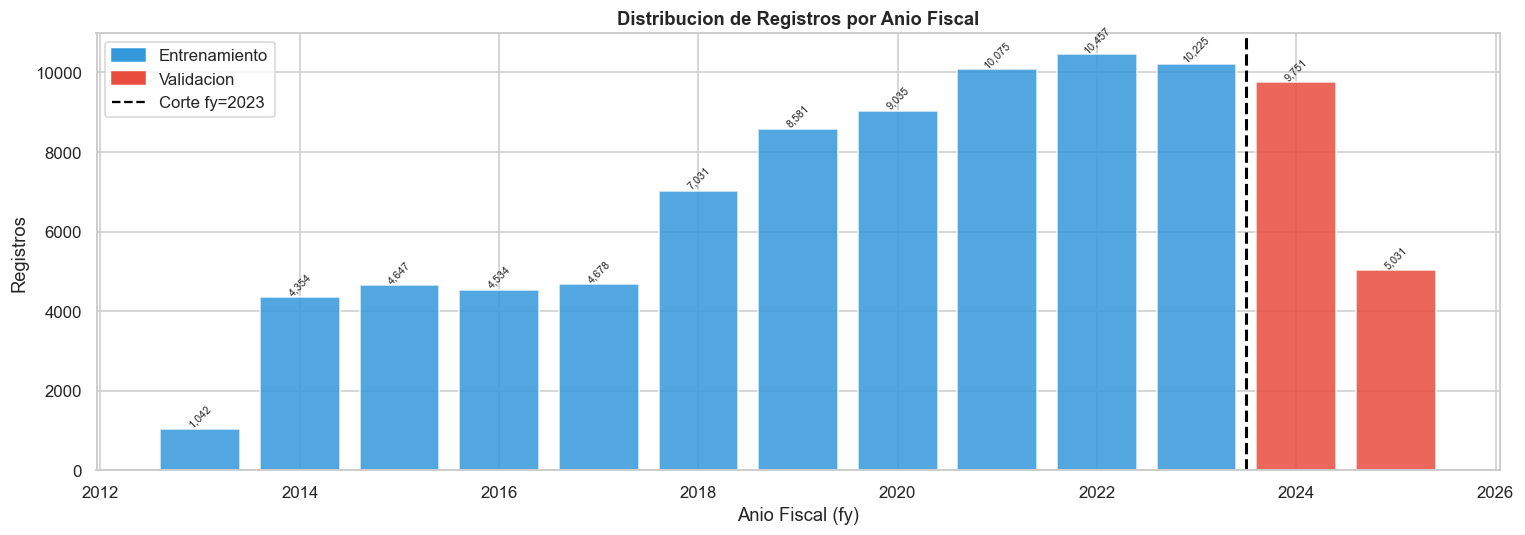

Entrenamiento (fy <= 2023): 74,659 registros (83.5%)
Validacion    (fy >  2023): 14,782  registros (16.5%)


In [12]:
# Inspeccion de la distribucion de registros por anio fiscal
# y visualizacion del punto de corte entre entrenamiento y validacion.

conteo_fy = df.groupby('fy').size().reset_index(name='registros')
conteo_fy['conjunto'] = conteo_fy['fy'].apply(
    lambda y: 'Entrenamiento' if y <= ANIO_CORTE_TRAIN else 'Validacion'
)

fig, ax = plt.subplots(figsize=(14, 5))
colores_conj = {'Entrenamiento': '#3498db', 'Validacion': '#e74c3c'}
for _, row in conteo_fy.iterrows():
    ax.bar(row['fy'], row['registros'],
           color=colores_conj[row['conjunto']], edgecolor='white', alpha=0.85)

ax.axvline(x=ANIO_CORTE_TRAIN + 0.5, color='black', linestyle='--', lw=2,
           label=f'Corte: fy={ANIO_CORTE_TRAIN}')
ax.set_xlabel('Anio Fiscal (fy)')
ax.set_ylabel('Registros')
ax.set_title('Distribucion de Registros por Anio Fiscal', fontweight='bold')
ax.legend()

from matplotlib.patches import Patch
leyenda = [Patch(color=v, label=k) for k, v in colores_conj.items()]
ax.legend(handles=leyenda + [plt.Line2D([0], [0], color='black', linestyle='--',
          label=f'Corte fy={ANIO_CORTE_TRAIN}')])

for _, row in conteo_fy.iterrows():
    ax.text(row['fy'], row['registros'] + 50, f"{row['registros']:,}",
            ha='center', fontsize=7, rotation=45)

plt.tight_layout()
plt.show()

n_train = conteo_fy.loc[conteo_fy['conjunto']=='Entrenamiento', 'registros'].sum()
n_val   = conteo_fy.loc[conteo_fy['conjunto']=='Validacion',   'registros'].sum()
print(f'Entrenamiento (fy <= {ANIO_CORTE_TRAIN}): {n_train:,} registros ({n_train/len(df)*100:.1f}%)')
print(f'Validacion    (fy >  {ANIO_CORTE_TRAIN}): {n_val:,}  registros ({n_val/len(df)*100:.1f}%)')

## 5. Definicion de Features y Variables Objetivo

In [13]:
# Definicion de las columnas excluidas del modelamiento y las variables objetivo.
# Se puede ampliar EXCLUIR_ADICIONAL con columnas de baja varianza o redundantes
# identificadas en la seccion de EDA.
#
# ============================================================================
# CHANGELOG vs version original:
#   FIX 1: Se agrega 'fe_ctx_sic_sector' a EXCLUIR_BASE.
#          Razon: el reporte v3 establece que 'fe_ctx_sic_sector' (ordinal)
#          y 'fe_sic_div_*' (dummies one-hot) NO deben coexistir como features.
#          La auditoria confirmo correlaciones de -0.688 con fe_sic_div_D y
#          +0.776 con fe_sic_div_I, lo que distorsiona feature importance
#          y rompe la independencia en modelos lineales.
#          Se conservan las dummies (mejor para modelos lineales y arboles).
#
#   FIX 2: Se elimina 'risk_score_prev' de EXCLUIR_BASE.
#          Razon: la auditoria confirmo que esta variable NO existe en el v3.
#          Excluir una columna inexistente no rompe nada pero genera ruido
#          documental. Se elimina para mantener limpio el codigo.
# ============================================================================

# -- Columnas de exclusion obligatoria (identificadores y leakage) ------------
EXCLUIR_BASE = [
    # Identificadores y metadatos
    'adsh', 'cik', 'name', 'sic', 'form', 'period', 'filed',
    'fy', 'fp', 'fye', 'stprba', 'countryba',
    # Columna de texto ya codificada en fe_sic_div_*
    'fe_sic_division',
    # FIX 1: Ordinal SIC redundante con las dummies fe_sic_div_*
    # (corr alta con fe_sic_div_D y fe_sic_div_I)
    'fe_ctx_sic_sector',
    # Data leakage: correlacion > 0.93 con risk_score_next
    'risk_score_0_1', 'risk_score_0_1.1', 'altman_zscore',
    # FIX 2: 'risk_score_prev' eliminada — no existe en el dataset v3
    # 'risk_score_prev',  <-- eliminado, ya no aplica
    # Columnas explicitamente marcadas como redundantes en el dataset
    '_REDUNDANTE_fe_anual_cash_operating',
    '_REDUNDANTE_fe_anual_net_income',
    '_REDUNDANTE_fe_flag_insolvencia',
    '_REDUNDANTE_fe_ratio_quick',
]

# -- Columnas de exclusion opcional (baja varianza / informacion redundante) --
EXCLUIR_ADICIONAL = [
    # Indicadores de recorte de outliers — baja varianza (>99% ceros)
    'fe_clipped_fe_ratio_cashflow_deuda',
    'fe_clipped_fe_shares_book_value',
    'fe_clipped_fe_shares_assets_per_share',
    'fe_clipped_fe_delta_liquidez_qoq',
    'fe_clipped_fe_delta_apalancamiento_qoq',
    # Columnas binarias de muy baja varianza (>97% valor dominante)
    'fe_ctx_amendment',       # 97.4% = 0
    'fe_flag_sin_revenue',    # 97.7% = 0
    'fe_sic_div_C',           # 99.0% = 0
    'fe_sic_div_F',           # 97.5% = 0
    'fe_sic_div_J',           # 99.9% = 0
]

# -- Variables objetivo ------------------------------------------------------
TARGET_REG1  = 'risk_score_next'
TARGET_REG2  = 'target_residual_next'
TARGET_BIN   = 'target_distress_next'
TARGET_MULTI = 'target_class_next'
TARGET_COLS  = [TARGET_REG1, TARGET_REG2, TARGET_BIN, TARGET_MULTI]

# -- Construccion de FEATURE_COLS --------------------------------------------
EXCLUIR_TOTAL = set(EXCLUIR_BASE + EXCLUIR_ADICIONAL + TARGET_COLS + [COL_TIEMPO])
FEATURE_COLS  = [c for c in df.columns if c not in EXCLUIR_TOTAL]

print(f'Features incluidos en el modelo: {len(FEATURE_COLS)}')
print(f'Columnas excluidas (base)     : {len(EXCLUIR_BASE)}')
print(f'Columnas excluidas (opcional) : {len(EXCLUIR_ADICIONAL)}')
print()
print('--- CAMBIOS APLICADOS ---')
print('  FIX 1: fe_ctx_sic_sector EXCLUIDO (redundante con dummies)')
print('  FIX 2: risk_score_prev removido del listado (no existe en v3)')
print()
for c in FEATURE_COLS:
    nulos = df[c].isnull().sum()
    print(f'  {c:<50} dtype={str(df[c].dtype):<12} nulos={nulos:,}')

Features incluidos en el modelo: 85
Columnas excluidas (base)     : 21
Columnas excluidas (opcional) : 10

--- CAMBIOS APLICADOS ---
  FIX 1: fe_ctx_sic_sector EXCLUIDO (redundante con dummies)
  FIX 2: risk_score_prev removido del listado (no existe en v3)

  fe_delta_zscore_qoq                                dtype=float64      nulos=0
  fe_delta_risk_score_qoq                            dtype=float64      nulos=0
  fe_delta_risk_score_prev                           dtype=float64      nulos=0
  fe_delta_risk_deterioro                            dtype=float64      nulos=0
  fe_ctx_fp_orden                                    dtype=int64        nulos=0
  fe_ctx_filing_lag                                  dtype=int64        nulos=0
  fe_anual_gross_profit                              dtype=float64      nulos=0
  fe_anual_revenue                                   dtype=float64      nulos=0
  fe_anual_ebit                                      dtype=float64      nulos=0
  fe_anual_cash_inves

In [14]:
# Validacion rapida del FIX
print(f"fe_ctx_sic_sector excluido?  {'SI' if 'fe_ctx_sic_sector' not in FEATURE_COLS else 'NO'}")
print(f"Dummies fe_sic_div_* en modelo: {len([c for c in FEATURE_COLS if c.startswith('fe_sic_div_')])}")
print(f"Total FEATURE_COLS: {len(FEATURE_COLS)}  (esperado: 85)")

fe_ctx_sic_sector excluido?  SI
Dummies fe_sic_div_* en modelo: 6
Total FEATURE_COLS: 85  (esperado: 85)


In [15]:
## *******************************Eliminar


# ============================================================================
# VALIDACIÓN — Auditoría de FEATURE_COLS contra reglas del v3
# ----------------------------------------------------------------------------
# Confirma que las features que entran al modelo cumplen las reglas
# documentadas en REPORTE_FASE1_DATASET_BUILDER_V2 y RESUMEN_SPRINT2_V3.
# ============================================================================

print("="*72)
print("AUDITORÍA DE FEATURE_COLS")
print("="*72)

print(f"\nTotal de features que entran al modelo: {len(FEATURE_COLS)}")

# --- Check A: Variables prohibidas que se hayan colado a FEATURE_COLS
print(f"\n[A] Variables prohibidas en FEATURE_COLS (target leakage directo):")
prohibidas_estrictas = [
    'altman_zscore', 'risk_score_0_1', 'risk_score_0_1.1',
    'risk_score_next', 'target_residual_next',
    'target_distress_next', 'target_class_next',
    'fe_zscore_x1_wc_assets', 'fe_zscore_x2_re_assets',
    'fe_zscore_x3_ebit_assets', 'fe_zscore_x4_equity_liab',
    'fe_zscore_x5_rev_assets',
    'fe_zscore_altman', 'fe_zscore_risk_score',
    'fe_flag_altman_distress', 'fe_flag_altman_grey',
]
fugas = [c for c in prohibidas_estrictas if c in FEATURE_COLS]
if fugas:
    print(f"    LEAKAGE DETECTADO: {fugas}")
else:
    print(f"    OK — ninguna variable prohibida en FEATURE_COLS")

# --- Check B: Coexistencia ordinal SIC + dummies SIC (regla v3)
print(f"\n[B] Coexistencia 'fe_ctx_sic_sector' + dummies 'fe_sic_div_*':")
ordinal_en_features = 'fe_ctx_sic_sector' in FEATURE_COLS
dummies_en_features = [c for c in FEATURE_COLS if c.startswith('fe_sic_div_')]
print(f"    Ordinal en FEATURE_COLS?  {'SI' if ordinal_en_features else 'NO'}")
print(f"    Dummies en FEATURE_COLS:  {len(dummies_en_features)}")
for d in dummies_en_features:
    print(f"      - {d}")

if ordinal_en_features and len(dummies_en_features) > 0:
    print(f"\n    PROBLEMA: ambas representaciones del sector COEXISTEN")
    print(f"    El reporte v3 dice: 'una o la otra, no ambas (corr trivial 1.0)'")

    # Medir correlación real entre ordinal y dummies
    print(f"\n    Correlación ordinal vs cada dummy:")
    for d in dummies_en_features:
        corr = df['fe_ctx_sic_sector'].corr(df[d])
        flag = "ALTA" if abs(corr) > 0.5 else "ok"
        print(f"      {d:18} corr={corr:+.3f}  [{flag}]")
elif ordinal_en_features:
    print(f"    OK — solo el ordinal entra al modelo")
elif len(dummies_en_features) > 0:
    print(f"    OK — solo las dummies entran al modelo")

# --- Check C: Variables Cat B autoregresivas (deberían estar)
print(f"\n[C] Cat B autoregresivas (deberían estar en FEATURE_COLS):")
cat_b = ['fe_delta_zscore_qoq', 'fe_delta_risk_score_qoq',
         'fe_delta_risk_score_prev', 'fe_delta_risk_deterioro']
for c in cat_b:
    estado = 'OK' if c in FEATURE_COLS else 'FALTA'
    presente_en_df = c in df.columns
    nota = '' if presente_en_df else ' (no existe en el CSV)'
    print(f"    [{estado:5}] {c}{nota}")

# --- Check D: Conteo por familia de feature
print(f"\n[D] Conteo de features por familia (prefijo):")
prefijos_a_contar = [
    ('fe_ratio_'   , 'Ratios financieros'),
    ('fe_anual_'   , 'Anualizados TTM'),
    ('fe_flag_'    , 'Flags fundamentales'),
    ('fe_delta_'   , 'Deltas / momentum'),
    ('fe_shares_'  , 'Shares / acciones'),
    ('fe_ctx_'     , 'Contextuales'),
    ('fe_imputed_' , 'Auditoría imputación'),
    ('fe_isnull_'  , 'Auditoría NaN estructural'),
    ('fe_clipped_' , 'Auditoría clipping'),
    ('fe_sic_div_' , 'Dummies sectoriales'),
]
for pref, desc in prefijos_a_contar:
    n = sum(1 for c in FEATURE_COLS if c.startswith(pref))
    print(f"    {pref:14} ({desc:30}) -> {n:>3} features")

# --- Check E: Features sin prefijo fe_ (sospechosas)
print(f"\n[E] Features sin prefijo 'fe_' en FEATURE_COLS (revisar manualmente):")
sin_prefijo = [c for c in FEATURE_COLS if not c.startswith('fe_')]
if sin_prefijo:
    for c in sin_prefijo:
        print(f"    - {c}")
else:
    print(f"    OK — todas las features tienen prefijo fe_")

# --- Check F: NaN en FEATURE_COLS (debería ser 0 según reporte v3)
print(f"\n[F] NaN en FEATURE_COLS (esperado: 0):")
nan_features = df[FEATURE_COLS].isnull().sum().sum()
print(f"    Total NaN en features: {nan_features:,}")
if nan_features > 0:
    cols_nan = df[FEATURE_COLS].isnull().sum()
    cols_nan = cols_nan[cols_nan > 0].sort_values(ascending=False)
    print(f"    Columnas con NaN:")
    for c, n in cols_nan.items():
        print(f"      {c:40} {n:,} NaN")
else:
    print(f"    OK — sin NaN, no es necesario el SimpleImputer")

# --- Check G: Comparación con FEATURES_FINALES_V3 oficial (57 features)
print(f"\n[G] Comparación con FEATURES_FINALES_V3 oficial:")
print(f"    Reporte v3 dice: 57 features modelables (Cat B + Cat C)")
print(f"    Notebook actual: {len(FEATURE_COLS)} features")
diferencia = len(FEATURE_COLS) - 57
if diferencia > 0:
    print(f"    Diferencia: +{diferencia} features extra en el notebook")
    print(f"    Probablemente: flags auditoría (fe_imputed_, fe_isnull_) + dummies SIC")
elif diferencia < 0:
    print(f"    Diferencia: {diferencia} features faltantes")
else:
    print(f"    OK — coincide exactamente")

print("\n" + "="*72)
print("FIN DE AUDITORÍA")
print("="*72)

AUDITORÍA DE FEATURE_COLS

Total de features que entran al modelo: 85

[A] Variables prohibidas en FEATURE_COLS (target leakage directo):
    OK — ninguna variable prohibida en FEATURE_COLS

[B] Coexistencia 'fe_ctx_sic_sector' + dummies 'fe_sic_div_*':
    Ordinal en FEATURE_COLS?  NO
    Dummies en FEATURE_COLS:  6
      - fe_sic_div_B
      - fe_sic_div_D
      - fe_sic_div_E
      - fe_sic_div_G
      - fe_sic_div_H
      - fe_sic_div_I
    OK — solo las dummies entran al modelo

[C] Cat B autoregresivas (deberían estar en FEATURE_COLS):
    [OK   ] fe_delta_zscore_qoq
    [OK   ] fe_delta_risk_score_qoq
    [OK   ] fe_delta_risk_score_prev
    [OK   ] fe_delta_risk_deterioro

[D] Conteo de features por familia (prefijo):
    fe_ratio_      (Ratios financieros            ) ->  26 features
    fe_anual_      (Anualizados TTM               ) ->   5 features
    fe_flag_       (Flags fundamentales           ) ->   6 features
    fe_delta_      (Deltas / momentum             ) ->  12 f

## 6. Preparacion de Datos: Split Temporal y Preprocesamiento

In [16]:
# Division temporal del dataset segun el corte definido en la Seccion 2.
# A diferencia de un split aleatorio, este enfoque respeta la estructura
# temporal de los datos financieros y evita el data leakage temporal.
#
# ============================================================================
# CHANGELOG vs version original:
#   FIX 3a: Se elimina SimpleImputer(median) del pipeline.
#           Razon: la auditoria confirmo 0 NaN en FEATURE_COLS. El reporte v3
#           establece que el dataset entrega features sin nulos (la imputacion
#           ya se hizo en el notebook 2 de Sprint 2). Aplicar imputacion aqui
#           es redundante. Se valida con assert antes del fit.
#
#   FIX 3b: StandardScaler aplicado SOLO a features numericas continuas.
#           Razon: aplicar StandardScaler a flags binarios (fe_flag_*,
#           fe_imputed_*, fe_isnull_*, fe_sic_div_*) los convierte de {0,1}
#           a valores continuos con media 0 y std 1, lo cual:
#             - Degrada interpretabilidad de modelos lineales
#             - Genera problemas downstream con SMOTE (siguiente fix)
#             - No aporta nada (los binarios ya estan en escala comparable)
#           Se usa ColumnTransformer para escalar solo las continuas.
# ============================================================================

from sklearn.compose import ColumnTransformer

mask_train = df[COL_TIEMPO] <= ANIO_CORTE_TRAIN
mask_val   = df[COL_TIEMPO] >  ANIO_CORTE_TRAIN

df_train = df[mask_train].copy()
df_val   = df[mask_val].copy()

X_train_raw = df_train[FEATURE_COLS]
X_val_raw   = df_val[FEATURE_COLS]

# -- FIX 3a: Validacion previa de NaN (en lugar de imputar a ciegas) ---------
nan_train = X_train_raw.isnull().sum().sum()
nan_val   = X_val_raw.isnull().sum().sum()
assert nan_train == 0, f'NaN inesperados en train: {nan_train} (revisar dataset)'
assert nan_val   == 0, f'NaN inesperados en val: {nan_val} (revisar dataset)'
print(f'Validacion NaN: train={nan_train}, val={nan_val} -- OK')

# -- FIX 3b: Identificar features binarias vs continuas ----------------------
# Una feature se considera binaria si solo tiene valores en {0, 1}
# (evaluado sobre el conjunto de entrenamiento)
features_binarias = [
    c for c in FEATURE_COLS
    if set(X_train_raw[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})
]
features_continuas = [c for c in FEATURE_COLS if c not in features_binarias]

print(f'Features binarias  (no se escalan): {len(features_binarias)}')
print(f'Features continuas (StandardScaler): {len(features_continuas)}')

# -- Pipeline corregido: solo escala continuas ------------------------------
preprocesador = ColumnTransformer(
    transformers=[
        ('continuas', StandardScaler(), features_continuas),
        ('binarias',  'passthrough',    features_binarias),
    ],
    remainder='drop'
)

X_train_arr = preprocesador.fit_transform(X_train_raw)   # fit solo en train
X_val_arr   = preprocesador.transform(X_val_raw)          # transform en validacion

# Reconstruir DataFrame manteniendo el orden de columnas del transformer
columnas_finales = features_continuas + features_binarias
X_train = pd.DataFrame(X_train_arr, columns=columnas_finales, index=df_train.index)
X_val   = pd.DataFrame(X_val_arr,   columns=columnas_finales, index=df_val.index)

# Reordenar para que coincida con FEATURE_COLS (importante para feature importance)
X_train = X_train[FEATURE_COLS]
X_val   = X_val[FEATURE_COLS]

# Targets por tarea
y_reg1_tr  = df_train[TARGET_REG1].values
y_reg1_val = df_val[TARGET_REG1].values

y_reg2_tr  = df_train[TARGET_REG2].values
y_reg2_val = df_val[TARGET_REG2].values

y_bin_tr   = df_train[TARGET_BIN].values
y_bin_val  = df_val[TARGET_BIN].values

y_mc_tr    = df_train[TARGET_MULTI].values
y_mc_val   = df_val[TARGET_MULTI].values

N_FEAT    = X_train.shape[1]
N_CLASSES = 3

print()
print(f'Entrenamiento : {X_train.shape[0]:,} registros x {N_FEAT} features')
print(f'Validacion    : {X_val.shape[0]:,}  registros x {N_FEAT} features')
print(f'Nulos tras preprocesamiento (train): {X_train.isnull().sum().sum()}')
print(f'Nulos tras preprocesamiento (val)  : {X_val.isnull().sum().sum()}')

# -- Validacion: las binarias siguen siendo binarias post-procesamiento -----
print()
print('--- Validacion FIX 3b: las binarias siguen en {0, 1} ---')
binarias_corruptas = []
for c in features_binarias:
    valores_unicos = set(X_train[c].unique())
    if not valores_unicos.issubset({0, 1, 0.0, 1.0}):
        binarias_corruptas.append((c, valores_unicos))
if binarias_corruptas:
    print('PROBLEMA: las siguientes binarias fueron corrompidas:')
    for c, v in binarias_corruptas[:5]:
        print(f'  {c}: {v}')
else:
    print(f'OK: las {len(features_binarias)} features binarias siguen en {{0,1}}')

# -- Validacion: las continuas estan estandarizadas -------------------------
print()
print('--- Validacion FIX 3b: las continuas estan estandarizadas ---')
muestra_cont = X_train[features_continuas].describe().loc[['mean', 'std']]
mean_cont = muestra_cont.loc['mean'].abs().mean()
std_cont  = muestra_cont.loc['std'].mean()
print(f'  Media absoluta promedio (continuas, esperado ~0): {mean_cont:.4f}')
print(f'  Std promedio (continuas, esperado ~1)           : {std_cont:.4f}')

Validacion NaN: train=0, val=0 -- OK
Features binarias  (no se escalan): 38
Features continuas (StandardScaler): 47

Entrenamiento : 74,659 registros x 85 features
Validacion    : 14,782  registros x 85 features
Nulos tras preprocesamiento (train): 0
Nulos tras preprocesamiento (val)  : 0

--- Validacion FIX 3b: las binarias siguen en {0, 1} ---
OK: las 38 features binarias siguen en {0,1}

--- Validacion FIX 3b: las continuas estan estandarizadas ---
  Media absoluta promedio (continuas, esperado ~0): 0.0000
  Std promedio (continuas, esperado ~1)           : 1.0000


## 7. Balanceo de Datos para Clasificacion

El balanceo se aplica **exclusivamente sobre el conjunto de entrenamiento**.
El conjunto de validacion conserva la distribucion real para una evaluacion no sesgada.

Distribucion ORIGINAL en entrenamiento:
  Binaria    - {np.int64(0): 28845, np.int64(1): 45814}
  Multiclase - {np.int64(0): 19788, np.int64(1): 19692, np.int64(2): 35179}

Features categoricas para SMOTENC: 38 de 85
Estrategia aplicada: SMOTENC
  Binaria    tras balanceo - {np.int64(0): 45814, np.int64(1): 45814}
  Multiclase tras balanceo - {np.int64(0): 35179, np.int64(1): 35179, np.int64(2): 35179}

--- Validacion FIX 4: las binarias post-balanceo siguen en {0, 1} ---
OK: las 38 features binarias siguen en {0,1} tras balanceo


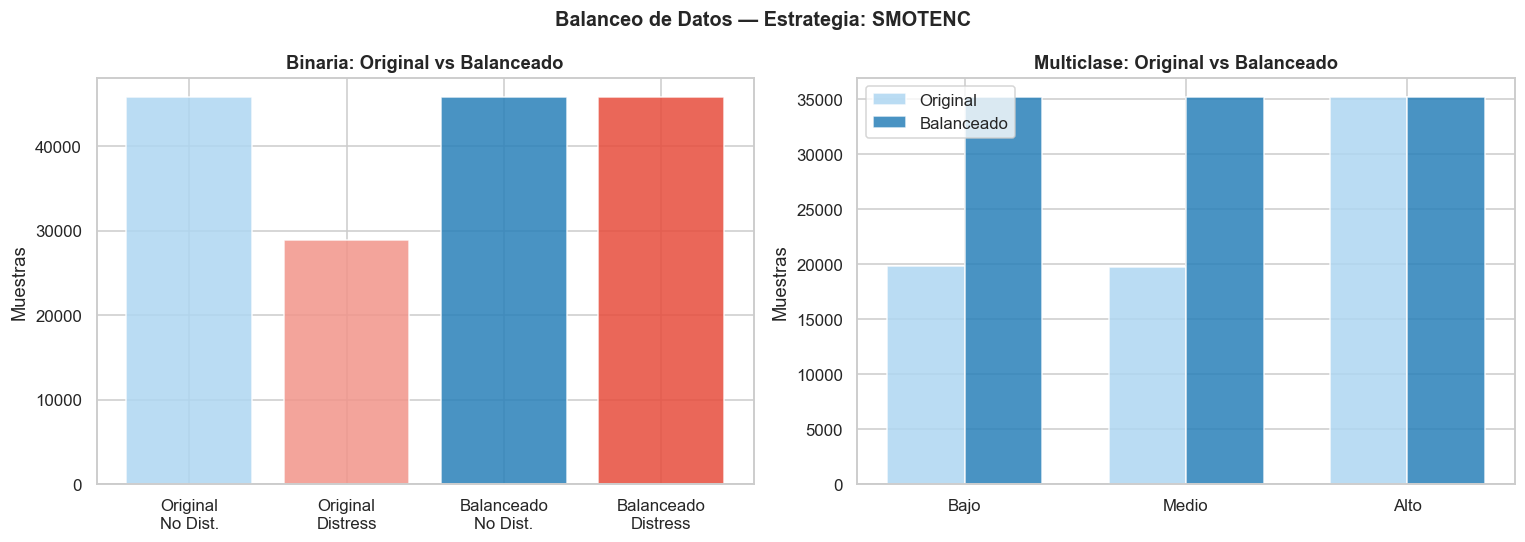

In [17]:
# Aplicacion de estrategias de balanceo para las tareas de clasificacion.
# Se comparan tres enfoques y se selecciona uno mediante ESTRATEGIA_BALANCEO.
#
# ============================================================================
# CHANGELOG vs version original:
#   FIX 4: Reemplazo de SMOTE por SMOTENC.
#          Razon: SMOTE estandar interpola linealmente entre vecinos para
#          generar ejemplos sinteticos. Eso funciona bien con features
#          continuas, pero CORROMPE features binarias: un flag {0,1} pasa
#          a tener valores como 0.42 o 0.78, que no representan ninguna
#          empresa real.
#
#          SMOTENC (SMOTE for Nominal and Continuous) trata las features
#          categoricas haciendo votacion mayoritaria entre vecinos en lugar
#          de interpolar, manteniendo los flags binarios en {0, 1}.
#
#          Requiere indicar los indices de las columnas categoricas via el
#          parametro categorical_features.
#
#   Adicional: SMOTETomek tambien se reemplaza por su version compatible
#              (SMOTENC + TomekLinks manual, opcional).
# ============================================================================

from imblearn.over_sampling import SMOTENC

ESTRATEGIA_BALANCEO = 'SMOTENC'   # Cambio: era 'SMOTE'

print('Distribucion ORIGINAL en entrenamiento:')
print(f'  Binaria    - {dict(sorted(Counter(y_bin_tr).items()))}')
print(f'  Multiclase - {dict(sorted(Counter(y_mc_tr).items()))}')
print()

# -- Identificar indices de columnas categoricas (binarias) ------------------
# Se calculan a partir de FEATURE_COLS y features_binarias (definidas en celda anterior)
indices_categoricas = [i for i, c in enumerate(FEATURE_COLS) if c in features_binarias]
print(f'Features categoricas para SMOTENC: {len(indices_categoricas)} de {len(FEATURE_COLS)}')

if ESTRATEGIA_BALANCEO == 'Ninguno':
    X_bal_bin = X_train.values; y_bal_bin = y_bin_tr
    X_bal_mc  = X_train.values; y_bal_mc  = y_mc_tr

elif ESTRATEGIA_BALANCEO == 'SMOTENC':
    # SMOTENC respeta features binarias (votacion mayoritaria en vez de interpolar)
    sampler_bin = SMOTENC(
        categorical_features=indices_categoricas,
        random_state=RANDOM_STATE,
        k_neighbors=5
    )
    sampler_mc = SMOTENC(
        categorical_features=indices_categoricas,
        random_state=RANDOM_STATE,
        k_neighbors=5
    )

    X_bal_bin, y_bal_bin = sampler_bin.fit_resample(X_train, y_bin_tr)
    X_bal_mc,  y_bal_mc  = sampler_mc.fit_resample(X_train,  y_mc_tr)

    if hasattr(X_bal_bin, 'values'):
        X_bal_bin = X_bal_bin.values
        X_bal_mc  = X_bal_mc.values

elif ESTRATEGIA_BALANCEO == 'RandomUnder':
    # RandomUnderSampler no genera sinteticos, no corrompe binarias
    sampler = RandomUnderSampler(random_state=RANDOM_STATE)
    X_bal_bin, y_bal_bin = sampler.fit_resample(X_train, y_bin_tr)
    X_bal_mc,  y_bal_mc  = sampler.fit_resample(X_train,  y_mc_tr)
    if hasattr(X_bal_bin, 'values'):
        X_bal_bin = X_bal_bin.values
        X_bal_mc  = X_bal_mc.values

else:
    # Fallback: si por error queda 'SMOTE' o 'SMOTETomek', advertir
    raise ValueError(
        f"ESTRATEGIA_BALANCEO='{ESTRATEGIA_BALANCEO}' no soportada con FIX 4. "
        f"Opciones: 'SMOTENC', 'RandomUnder', 'Ninguno'."
    )

print(f'Estrategia aplicada: {ESTRATEGIA_BALANCEO}')
print(f'  Binaria    tras balanceo - {dict(sorted(Counter(y_bal_bin).items()))}')
print(f'  Multiclase tras balanceo - {dict(sorted(Counter(y_bal_mc).items()))}')

# -- Validacion FIX 4: las binarias post-SMOTENC siguen siendo binarias ------
print()
print('--- Validacion FIX 4: las binarias post-balanceo siguen en {0, 1} ---')
df_bal_bin = pd.DataFrame(X_bal_bin, columns=FEATURE_COLS)
binarias_corruptas = []
for c in features_binarias:
    valores_unicos = set(df_bal_bin[c].unique())
    if not valores_unicos.issubset({0, 1, 0.0, 1.0}):
        binarias_corruptas.append((c, valores_unicos))

if binarias_corruptas:
    print(f'PROBLEMA: {len(binarias_corruptas)} binarias corrompidas tras balanceo:')
    for c, v in binarias_corruptas[:5]:
        muestra = sorted(list(v))[:5]
        print(f'  {c}: ...{muestra}...')
    print(f'  Esto NO deberia pasar con SMOTENC')
else:
    print(f'OK: las {len(features_binarias)} features binarias siguen en {{0,1}} tras balanceo')

# -- Visualizacion comparativa ----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binaria
etiq_bin = ['Original\nNo Dist.', 'Original\nDistress',
            'Balanceado\nNo Dist.', 'Balanceado\nDistress']
vals_bin = list(Counter(y_bin_tr).values()) + list(Counter(y_bal_bin).values())
cols_bin = ['#aed6f1','#f1948a','#2980b9','#e74c3c']
axes[0].bar(etiq_bin, vals_bin, color=cols_bin, edgecolor='white', alpha=0.85)
axes[0].set_title('Binaria: Original vs Balanceado', fontweight='bold')
axes[0].set_ylabel('Muestras')

# Multiclase
nombres_mc = {0: 'Bajo', 1: 'Medio', 2: 'Alto'}
cnt_orig = Counter(y_mc_tr)
cnt_bal  = Counter(y_bal_mc)
x_pos = np.arange(3)
ancho = 0.35
axes[1].bar(x_pos - ancho/2, [cnt_orig[i] for i in range(3)],
            ancho, label='Original',    color='#aed6f1', edgecolor='white', alpha=0.85)
axes[1].bar(x_pos + ancho/2, [cnt_bal[i] for i in range(3)],
            ancho, label='Balanceado',  color='#2980b9', edgecolor='white', alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([nombres_mc[i] for i in range(3)])
axes[1].set_title('Multiclase: Original vs Balanceado', fontweight='bold')
axes[1].set_ylabel('Muestras')
axes[1].legend()

plt.suptitle(f'Balanceo de Datos — Estrategia: {ESTRATEGIA_BALANCEO}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# =============================================================================
# ARQUITECTURAS DE REDES NEURONALES
# Se definen DNN, LSTM, GRU, Bi-LSTM, GCN y GAT como modulos de PyTorch.
# Cada arquitectura es reutilizable para regresion, clasificacion binaria
# y multiclase ajustando unicamente el parametro out_features.
# =============================================================================

# -- DNN: Red Neuronal Profunda con BatchNorm y Dropout ----------------------
# Ref: Woloszko (2020), Steinberg et al. (2023)
class DNNModel(nn.Module):
    def __init__(self, in_features, out_features, hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers, prev = [], in_features
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.head      = nn.Linear(prev, out_features)

    def forward(self, x):
        return self.head(self.backbone(x))


# -- LSTM: Long Short-Term Memory --------------------------------------------
# Ref: Zogaan et al. (2025), Tenorio et al. (2025), Chen et al. (2024)
class LSTMModel(nn.Module):
    def __init__(self, in_features, out_features, hidden=128, num_layers=2,
                 dropout=0.3, bidirectional=False):
        super().__init__()
        self.lstm = nn.LSTM(in_features, hidden, num_layers=num_layers,
                            dropout=dropout, batch_first=True,
                            bidirectional=bidirectional)
        factor    = 2 if bidirectional else 1
        self.head = nn.Linear(hidden * factor, out_features)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])


# -- GRU: Gated Recurrent Unit -----------------------------------------------
# Ref: Zogaan et al. (2025), Chen et al. (2024)
class GRUModel(nn.Module):
    def __init__(self, in_features, out_features, hidden=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.gru  = nn.GRU(in_features, hidden, num_layers=num_layers,
                           dropout=dropout, batch_first=True)
        self.head = nn.Linear(hidden, out_features)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        out, _ = self.gru(x)
        return self.head(out[:, -1, :])


# -- GCN: Graph Convolutional Network ----------------------------------------
# Ref: Das et al. (2023) — GCN/GraphSAGE supero modelos flat en datos SEC
class GCNModel(nn.Module):
    def __init__(self, in_features, out_features, hidden=128, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_features, hidden)
        self.conv2 = GCNConv(hidden, hidden // 2)
        self.head  = nn.Linear(hidden // 2, out_features)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = self.drop(x)
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.head(x)


# -- GAT: Graph Attention Network --------------------------------------------
# Ref: Yang et al. (2020) — ST-GNN/GAT para riesgo en redes dinamicas
class GATModel(nn.Module):
    def __init__(self, in_features, out_features, hidden=64, heads=4, dropout=0.3):
        super().__init__()
        self.conv1 = GATConv(in_features, hidden, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden * heads, hidden, heads=1, concat=False, dropout=dropout)
        self.head  = nn.Linear(hidden, out_features)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = self.drop(x)
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.head(x)


print('Arquitecturas definidas: DNN | LSTM | GRU | Bi-LSTM | GCN | GAT')

Arquitecturas definidas: DNN | LSTM | GRU | Bi-LSTM | GCN | GAT


In [19]:
# =============================================================================
# FUNCIONES DE ENTRENAMIENTO, INFERENCIA Y WRAPPER SKLEARN PARA PYTORCH
# El wrapper TorchWrapper permite que DNN/LSTM/GRU/Bi-LSTM tengan la misma
# interfaz fit/predict que los modelos sklearn, facilitando su uso en los
# mismos loops de entrenamiento.
# Los modelos GNN requieren construccion de grafos k-NN y se manejan
# en un loop separado dentro de cada tarea.
# =============================================================================

def _a_tensor(arr):
    """Convierte numpy array o pandas Series a tensor float32."""
    v = arr.values if hasattr(arr, 'values') else arr
    return torch.tensor(v, dtype=torch.float32)


def entrenar_nn(modelo, X_tr, y_tr, task='reg',
                epochs=40, batch_size=512, lr=1e-3, patience=5):
    """
    Entrena un modelo PyTorch (DNN, LSTM o GRU) con early-stopping
    sobre la perdida de entrenamiento.
    task: 'reg' | 'bin' | 'multi'
    """
    X_t = _a_tensor(X_tr)
    y_t = _a_tensor(y_tr)
    if task == 'bin':   y_t = y_t.float()
    if task == 'multi': y_t = y_t.long()

    loss_fn = {'reg': nn.MSELoss(),
               'bin': nn.BCEWithLogitsLoss(),
               'multi': nn.CrossEntropyLoss()}[task]

    loader = DataLoader(TensorDataset(X_t, y_t),
                        batch_size=batch_size, shuffle=True)
    modelo = modelo.to(DEVICE)
    opt    = optim.Adam(modelo.parameters(), lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=2, factor=0.5)

    mejor_loss, espera = float('inf'), 0
    modelo.train()
    for _ in range(epochs):
        ep_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out  = modelo(xb)
            loss = loss_fn(out.squeeze(-1) if task != 'multi' else out, yb)
            loss.backward()
            opt.step()
            ep_loss += loss.item()
        ep_loss /= len(loader)
        sched.step(ep_loss)
        if ep_loss < mejor_loss - 1e-5:
            mejor_loss, espera = ep_loss, 0
        else:
            espera += 1
            if espera >= patience:
                break
    return modelo


def inferir_nn(modelo, X_te, batch_size=1024):
    """Inferencia en batches. Retorna numpy array de logits/salidas crudas."""
    loader = DataLoader(TensorDataset(_a_tensor(X_te)), batch_size=batch_size)
    modelo.eval()
    preds = []
    with torch.no_grad():
        for (xb,) in loader:
            preds.append(modelo(xb.to(DEVICE)).cpu())
    return torch.cat(preds).numpy()


def construir_grafos_knn(X_arr, y_arr, k=5):
    """
    Construye una lista de grafos k-NN (uno por muestra) para GCN/GAT.
    Cada nodo central se conecta con sus k vecinos mas cercanos
    en el espacio de features usando distancia euclidiana.
    """
    from sklearn.neighbors import NearestNeighbors
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_arr)
    _, indices = nbrs.kneighbors(X_arr)
    grafos = []
    for i in range(len(X_arr)):
        nodos = indices[i]
        x_nodos = torch.tensor(X_arr[nodos], dtype=torch.float32)
        src = torch.zeros(k, dtype=torch.long)
        dst = torch.arange(1, k + 1, dtype=torch.long)
        edge_index = torch.stack([torch.cat([src, dst]),
                                  torch.cat([dst, src])])
        grafos.append(Data(x=x_nodos, edge_index=edge_index,
                           y=torch.tensor([y_arr[i]], dtype=torch.float32)))
    return grafos


def entrenar_gnn(modelo, grafos_tr, task='reg', epochs=15,
                 batch_size=256, lr=1e-3):
    """Entrena un modelo GCN o GAT sobre una lista de grafos PyG."""
    loss_fn = {'reg': nn.MSELoss(),
               'bin': nn.BCEWithLogitsLoss(),
               'multi': nn.CrossEntropyLoss()}[task]
    loader = PyGLoader(grafos_tr, batch_size=batch_size, shuffle=True)
    modelo = modelo.to(DEVICE)
    opt    = optim.Adam(modelo.parameters(), lr=lr, weight_decay=1e-4)
    modelo.train()
    for _ in range(epochs):
        for batch in loader:
            batch = batch.to(DEVICE)
            opt.zero_grad()
            out  = modelo(batch.x, batch.edge_index, batch.batch)
            y    = batch.y.squeeze(-1)
            loss = loss_fn(out.float().squeeze(-1) if task != 'multi' else out,
                           y.float() if task != 'multi' else y.long())
            loss.backward()
            opt.step()
    return modelo


def inferir_gnn(modelo, grafos_te, batch_size=256):
    """Inferencia GNN sobre lista de grafos. Retorna numpy array."""
    loader = PyGLoader(grafos_te, batch_size=batch_size, shuffle=False)
    modelo.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            preds.append(modelo(batch.x, batch.edge_index, batch.batch).cpu())
    return torch.cat(preds).numpy()


# -- Wrapper sklearn para DNN/LSTM/GRU/Bi-LSTM --------------------------------
# Permite usar estos modelos en el mismo dict y loop que los modelos sklearn.

class TorchWrapper:
    """
    Envuelve un modelo PyTorch para que exponga la interfaz fit/predict
    compatible con sklearn. Esto permite incluirlos en el mismo diccionario
    de modelos y ejecutarlos en el mismo loop de entrenamiento.
    """
    def __init__(self, build_fn, task='reg', epochs=40, batch_size=512, lr=1e-3):
        self.build_fn   = build_fn
        self.task       = task
        self.epochs     = epochs
        self.batch_size = batch_size
        self.lr         = lr
        self.modelo_    = None

    def fit(self, X, y):
        self.modelo_ = entrenar_nn(
            self.build_fn(), X, y,
            task=self.task, epochs=self.epochs,
            batch_size=self.batch_size, lr=self.lr
        )
        return self

    def predict(self, X):
        raw = inferir_nn(self.modelo_, X)
        if self.task == 'reg':
            return raw.flatten()
        elif self.task == 'bin':
            return (torch.sigmoid(torch.tensor(raw)).numpy().flatten() > 0.5).astype(int)
        else:
            return torch.softmax(torch.tensor(raw), dim=-1).numpy().argmax(axis=1)

    def predict_proba(self, X):
        raw = inferir_nn(self.modelo_, X)
        if self.task == 'bin':
            p = torch.sigmoid(torch.tensor(raw)).numpy().flatten()
            return np.stack([1 - p, p], axis=1)
        else:
            return torch.softmax(torch.tensor(raw), dim=-1).numpy()

    def __repr__(self):
        return f'TorchWrapper(task={self.task})'


print('Funciones de entrenamiento e inferencia definidas.')
print('Wrapper TorchWrapper listo para DNN, LSTM, GRU y Bi-LSTM.')

Funciones de entrenamiento e inferencia definidas.
Wrapper TorchWrapper listo para DNN, LSTM, GRU y Bi-LSTM.


## 8. Definicion de Modelos

**Para activar o desactivar modelos:** comentar o descomentar las entradas del diccionario.
Los modelos comentados son ignorados en todos los loops de entrenamiento siguientes.

In [20]:
# =============================================================================
# CELDA DE CONTROL DE MODELOS
# Se comenta cualquier entrada para desactivar ese modelo en TODAS las tareas.
# Los cambios aqui se propagan automaticamente a todos los loops de entrenamiento.
#
# Los 13 modelos disponibles son:
#   Ensamble/Boosting : Ridge, Lasso, ElasticNet, Random Forest,
#                       Gradient Boosting, XGBoost, LightGBM
#   Deep Learning     : DNN, LSTM, GRU, Bi-LSTM  (via TorchWrapper)
#   Grafos (GNN)      : GCN, GAT  (loop separado, requieren grafos k-NN)
# =============================================================================

# -- Modelos de Regresion ----------------------------------------------------
MODELOS_REG = {
    # -- Benchmarks lineales -------------------------------------------------
    #'Ridge'             : Ridge(alpha=1.0, random_state=RANDOM_STATE),
    #'Lasso'             : Lasso(alpha=0.001, max_iter=5000, random_state=RANDOM_STATE),
    #'ElasticNet'        : ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000,
    #                                 random_state=RANDOM_STATE),
    # -- Ensambles -----------------------------------------------------------
    #'Random Forest'     : RandomForestRegressor(n_estimators=200, max_depth=10,
    #                                            random_state=RANDOM_STATE, n_jobs=-1),
    #'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, max_depth=5,
    #                                                learning_rate=0.05,
    #                                                random_state=RANDOM_STATE),
    # -- Boosting avanzado ---------------------------------------------------
    'XGBoost'           : xgb.XGBRegressor(n_estimators=300, max_depth=6,
                                            learning_rate=0.05, subsample=0.8,
                                            colsample_bytree=0.8,
                                            objective='reg:squarederror',
                                            random_state=RANDOM_STATE,
                                            n_jobs=-1, verbosity=0),
    #'LightGBM'          : lgb.LGBMRegressor(n_estimators=300, max_depth=6,
    #                                         learning_rate=0.05, subsample=0.8,
    #                                         colsample_bytree=0.8,
    #                                         random_state=RANDOM_STATE,
    #                                         n_jobs=-1, verbose=-1),
    # -- Redes neuronales profundas (via TorchWrapper) -----------------------
    #'DNN'               : TorchWrapper(lambda: DNNModel(N_FEAT, 1),     task='reg'),
    #'LSTM'              : TorchWrapper(lambda: LSTMModel(N_FEAT, 1),    task='reg'),
    #'GRU'               : TorchWrapper(lambda: GRUModel(N_FEAT, 1),     task='reg'),
    #'Bi-LSTM'           : TorchWrapper(lambda: LSTMModel(N_FEAT, 1, bidirectional=True),
    #                                   task='reg'),
}

# -- Builders GNN para Regresion (loop separado) -----------------------------
# Se comenta 'GCN' o 'GAT' para desactivarlos.
GNN_REG_BUILDERS = {
    #'GCN' : lambda: GCNModel(N_FEAT, 1),
    #'GAT' : lambda: GATModel(N_FEAT, 1),
}

# -- Modelos de Clasificacion Binaria ----------------------------------------
MODELOS_BIN = {
    #'Logistic Regression' : LogisticRegression(max_iter=1000, C=0.5,
    #                                           random_state=RANDOM_STATE),
    #'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=10,
    #                                               random_state=RANDOM_STATE, n_jobs=-1),
    #'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, max_depth=5,
    #                                                    learning_rate=0.05,
    #                                                    random_state=RANDOM_STATE),
    'XGBoost'             : xgb.XGBClassifier(n_estimators=300, max_depth=6,
                                               learning_rate=0.05, subsample=0.8,
                                               colsample_bytree=0.8,
                                               eval_metric='logloss',
                                               random_state=RANDOM_STATE,
                                               n_jobs=-1, verbosity=0),
    #'LightGBM'            : lgb.LGBMClassifier(n_estimators=300, max_depth=6,
    #                                            learning_rate=0.05, subsample=0.8,
    #                                            colsample_bytree=0.8,
    #                                            random_state=RANDOM_STATE,
    #                                            n_jobs=-1, verbose=-1),
    #'DNN'                 : TorchWrapper(lambda: DNNModel(N_FEAT, 1),     task='bin'),
    #'LSTM'                : TorchWrapper(lambda: LSTMModel(N_FEAT, 1),    task='bin'),
    #'GRU'                 : TorchWrapper(lambda: GRUModel(N_FEAT, 1),     task='bin'),
    #'Bi-LSTM'             : TorchWrapper(lambda: LSTMModel(N_FEAT, 1, bidirectional=True),
    #                                     task='bin'),
}

GNN_BIN_BUILDERS = {
    #'GCN' : lambda: GCNModel(N_FEAT, 1),
    #'GAT' : lambda: GATModel(N_FEAT, 1),
}

# -- Modelos de Clasificacion Multiclase -------------------------------------
MODELOS_MULTI = {
    #'Logistic Regression' : LogisticRegression(max_iter=1000,
    #                                           multi_class='multinomial',
    #                                           C=0.5, random_state=RANDOM_STATE),
    #'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=10,
    #                                               random_state=RANDOM_STATE, n_jobs=-1),
    #'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, max_depth=5,
    #                                                    learning_rate=0.05,
    #                                                    random_state=RANDOM_STATE),
    'XGBoost'             : xgb.XGBClassifier(n_estimators=300, max_depth=6,
                                               learning_rate=0.05, subsample=0.8,
                                               colsample_bytree=0.8,
                                               objective='multi:softprob',
                                               num_class=N_CLASSES,
                                               eval_metric='mlogloss',
                                               random_state=RANDOM_STATE,
                                               n_jobs=-1, verbosity=0),
    #'LightGBM'            : lgb.LGBMClassifier(n_estimators=300, max_depth=6,
    #                                            learning_rate=0.05, subsample=0.8,
    #                                            colsample_bytree=0.8,
    #                                            objective='multiclass',
    #                                            num_class=N_CLASSES,
    #                                            random_state=RANDOM_STATE,
    #                                            n_jobs=-1, verbose=-1),
    #'DNN'                 : TorchWrapper(lambda: DNNModel(N_FEAT, N_CLASSES),  task='multi'),
    #'LSTM'                : TorchWrapper(lambda: LSTMModel(N_FEAT, N_CLASSES), task='multi'),
    #'GRU'                 : TorchWrapper(lambda: GRUModel(N_FEAT, N_CLASSES),  task='multi'),
    #'Bi-LSTM'             : TorchWrapper(lambda: LSTMModel(N_FEAT, N_CLASSES,
    #                                                        bidirectional=True),
    #                                     task='multi'),
}

GNN_MULTI_BUILDERS = {
    #'GCN' : lambda: GCNModel(N_FEAT, N_CLASSES),
    #'GAT' : lambda: GATModel(N_FEAT, N_CLASSES),
}

n_reg   = len(MODELOS_REG)   + len(GNN_REG_BUILDERS)
n_bin   = len(MODELOS_BIN)   + len(GNN_BIN_BUILDERS)
n_multi = len(MODELOS_MULTI) + len(GNN_MULTI_BUILDERS)

print(f'Modelos activos por tarea:')
print(f'  Regresion (reg1 y reg2) : {list(MODELOS_REG.keys()) + list(GNN_REG_BUILDERS.keys())} ({n_reg} modelos)')
print(f'  Binaria                 : {list(MODELOS_BIN.keys()) + list(GNN_BIN_BUILDERS.keys())} ({n_bin} modelos)')
print(f'  Multiclase              : {list(MODELOS_MULTI.keys()) + list(GNN_MULTI_BUILDERS.keys())} ({n_multi} modelos)')

Modelos activos por tarea:
  Regresion (reg1 y reg2) : ['XGBoost'] (1 modelos)
  Binaria                 : ['XGBoost'] (1 modelos)
  Multiclase              : ['XGBoost'] (1 modelos)


## 9. Funciones Auxiliares de Evaluacion

In [21]:
# Funciones reutilizables para calcular metricas de cada tarea.

def evaluar_regresion(y_true, y_pred, clip=True, rango=(0, 1)):
    """
    Calcula RMSE, MAE, R2 y MAPE para una tarea de regresion.
    Si clip=True, recorta las predicciones al rango especificado.
    """
    if clip:
        y_pred = np.clip(y_pred, rango[0], rango[1])
    mask = y_true > 0.001
    return {
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 5),
        'MAE' : round(mean_absolute_error(y_true, y_pred), 5),
        'R2'  : round(r2_score(y_true, y_pred), 5),
        'MAPE': round(mean_absolute_percentage_error(
                      y_true[mask], y_pred[mask]), 5) if mask.sum() > 0 else np.nan,
    }


def evaluar_binaria(y_true, y_pred, y_prob=None):
    """
    Calcula Accuracy, Precision, Recall, F1 y ROC-AUC para clasificacion binaria.
    """
    return {
        'Accuracy'  : round(accuracy_score(y_true, y_pred), 4),
        'Precision' : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1'        : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC'   : round(roc_auc_score(y_true, y_prob), 4) if y_prob is not None else np.nan,
    }


def evaluar_multiclase(y_true, y_pred, y_prob=None):
    """
    Calcula Accuracy, F1 Macro, F1 Weighted, Precision Macro,
    Recall Macro y ROC-AUC OvR para clasificacion multiclase.
    """
    roc = np.nan
    if y_prob is not None:
        try:
            roc = round(roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro'), 4)
        except Exception:
            roc = np.nan
    return {
        'Accuracy'       : round(accuracy_score(y_true, y_pred), 4),
        'F1 Macro'       : round(f1_score(y_true, y_pred, average='macro',    zero_division=0), 4),
        'F1 Weighted'    : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Precision Macro': round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Recall Macro'   : round(recall_score(y_true, y_pred, average='macro',    zero_division=0), 4),
        'ROC-AUC OvR'    : roc,
    }


def tabla_ranking(resultados, metrica_orden, ascendente=True):
    """
    Convierte una lista de diccionarios de metricas en un DataFrame
    ordenado por la metrica especificada, con el indice comenzando en 1.
    """
    df_res = pd.DataFrame(resultados).sort_values(metrica_orden, ascending=ascendente)
    df_res = df_res.reset_index(drop=True)
    df_res.index += 1
    return df_res


print('Funciones de evaluacion definidas.')

Funciones de evaluacion definidas.


## 10. Tarea 1 — Regresion: `risk_score_next`

In [22]:
# Entrenamiento y evaluacion de los 13 modelos para risk_score_next.
# El loop principal cubre sklearn/boosting y redes neuronales (via TorchWrapper).
# Un loop separado entrena GCN y GAT con grafos k-NN.

print('Entrenando modelos — Regresion: risk_score_next')
print('-' * 60)

res_reg1 = []
modelos_reg1_entrenados = {}

# -- Loop principal: sklearn / boosting / DNN / LSTM / GRU / Bi-LSTM ---------
for nombre, modelo in MODELOS_REG.items():
    print(f'  Entrenando: {nombre}...')
    modelo_copia = copy.deepcopy(modelo)
    modelo_copia.fit(X_train.values, y_reg1_tr)
    y_pred = modelo_copia.predict(X_val.values)
    metricas = evaluar_regresion(y_reg1_val, y_pred, clip=True, rango=(0, 1))
    res_reg1.append({'Modelo': nombre, 'Familia': 'Ensamble/Boosting/DL', **metricas})
    modelos_reg1_entrenados[nombre] = modelo_copia

# -- Loop GNN: GCN y GAT -----------------------------------------------------
if GNN_REG_BUILDERS:
    print('  Construyendo grafos k-NN para GNN (submuestreo para eficiencia)...')
    idx_tr = np.random.choice(len(X_train), min(8000, len(X_train)), replace=False)
    g_tr   = construir_grafos_knn(X_train.values[idx_tr], y_reg1_tr[idx_tr], k=5)
    g_val  = construir_grafos_knn(X_val.values[:3000],   y_reg1_val[:3000], k=5)

    for nombre, build_fn in GNN_REG_BUILDERS.items():
        print(f'  Entrenando: {nombre}...')
        m      = entrenar_gnn(build_fn(), g_tr, task='reg', epochs=15)
        raw    = inferir_gnn(m, g_val)
        y_pred = torch.sigmoid(torch.tensor(raw)).numpy().flatten()
        metricas = evaluar_regresion(y_reg1_val[:3000], y_pred, clip=True, rango=(0, 1))
        res_reg1.append({'Modelo': nombre, 'Familia': 'Grafo (GNN)', **metricas})
        modelos_reg1_entrenados[nombre] = m

df_reg1 = tabla_ranking(res_reg1, 'RMSE', ascendente=True)
print('\nResultados:')
df_reg1

Entrenando modelos — Regresion: risk_score_next
------------------------------------------------------------
  Entrenando: XGBoost...

Resultados:


,Modelo,Familia,RMSE,MAE,R2,MAPE
1,XGBoost,Ensamble/Boosting/DL,0.09438,0.04342,0.91439,0.50499


In [23]:
# ============================================================================
# VALIDACIÓN CRÍTICA — ¿El modelo aporta valor sobre el baseline naive?
# ----------------------------------------------------------------------------
# El reporte v3 advierte: corr(risk_score_t, risk_score_{t+1}) = 0.94.
# Un modelo "tonto" que predice 'mañana = hoy' ya explica ~88% de la varianza.
# Necesitamos confirmar que XGBoost le gana significativamente a ese baseline.
# Si no le gana, el R² alto es engañoso: el modelo solo esta copiando.
# ============================================================================

print("="*72)
print("VALIDACION CRITICA — Modelo vs Baseline naive (persistencia)")
print("="*72)

# -- Baseline 1: persistencia pura (mañana = hoy) ----------------------------
# Predecir risk_score_next como simplemente risk_score_0_1 actual
y_pred_persistencia = df_val['risk_score_0_1'].values
metricas_persistencia = evaluar_regresion(
    y_reg1_val, y_pred_persistencia, clip=True, rango=(0, 1)
)

# -- Baseline 2: persistencia + delta (extrapolacion lineal) -----------------
# Predecir risk_score_next como risk_score_0_1 + delta_qoq actual
# (asume que el deterioro reciente continua linealmente)
y_pred_lineal = (df_val['risk_score_0_1'] + df_val['fe_delta_risk_score_qoq']).values
metricas_lineal = evaluar_regresion(
    y_reg1_val, y_pred_lineal, clip=True, rango=(0, 1)
)

# -- Modelo XGBoost (el que ya entrenaste) -----------------------------------
# Recuperamos sus metricas del DataFrame de resultados
fila_xgb = df_reg1[df_reg1['Modelo'] == 'XGBoost'].iloc[0]
metricas_xgb = {
    'RMSE': fila_xgb['RMSE'],
    'MAE' : fila_xgb['MAE'],
    'R2'  : fila_xgb['R2'],
    'MAPE': fila_xgb['MAPE'],
}

# -- Tabla comparativa -------------------------------------------------------
print("\nComparacion de metricas en validacion (fy > 2023):")
print(f"{'Modelo':<35} {'RMSE':>10} {'MAE':>10} {'R2':>10}")
print("-" * 67)
print(f"{'Baseline 1: Persistencia (hoy)':<35} "
      f"{metricas_persistencia['RMSE']:>10.5f} "
      f"{metricas_persistencia['MAE']:>10.5f} "
      f"{metricas_persistencia['R2']:>10.5f}")
print(f"{'Baseline 2: Persistencia + delta':<35} "
      f"{metricas_lineal['RMSE']:>10.5f} "
      f"{metricas_lineal['MAE']:>10.5f} "
      f"{metricas_lineal['R2']:>10.5f}")
print(f"{'XGBoost (modelo entrenado)':<35} "
      f"{metricas_xgb['RMSE']:>10.5f} "
      f"{metricas_xgb['MAE']:>10.5f} "
      f"{metricas_xgb['R2']:>10.5f}")

# -- Calculo de mejora relativa ---------------------------------------------
print()
print("Mejora del modelo XGBoost vs baselines:")
mejora_rmse_pers = (metricas_persistencia['RMSE'] - metricas_xgb['RMSE']) \
                   / metricas_persistencia['RMSE'] * 100
mejora_rmse_lin  = (metricas_lineal['RMSE'] - metricas_xgb['RMSE']) \
                   / metricas_lineal['RMSE'] * 100
mejora_r2_pers   = metricas_xgb['R2'] - metricas_persistencia['R2']
mejora_r2_lin    = metricas_xgb['R2'] - metricas_lineal['R2']

print(f"  vs Persistencia       : RMSE -{mejora_rmse_pers:+.2f}%   R2 +{mejora_r2_pers:+.5f}")
print(f"  vs Persistencia+delta : RMSE -{mejora_rmse_lin:+.2f}%   R2 +{mejora_r2_lin:+.5f}")

# -- Diagnostico -------------------------------------------------------------
print()
print("DIAGNOSTICO:")
if metricas_xgb['RMSE'] < metricas_persistencia['RMSE'] * 0.95:
    print("  El modelo aporta valor genuino sobre el baseline (>5% mejora en RMSE)")
elif metricas_xgb['RMSE'] < metricas_persistencia['RMSE']:
    print("  El modelo gana pero por margen estrecho (<5%) — revisar si vale la complejidad")
else:
    print("  ALERTA: el modelo NO supera al baseline naive")
    print("  El R2 alto era inercia de la persistencia, no aporte real")

# -- Bonus: ¿que tan correlacionada esta la prediccion con risk_score_0_1? --
print()
print("Verificacion adicional — ¿el modelo solo esta copiando risk_score_0_1?")
y_pred_xgb = modelos_reg1_entrenados['XGBoost'].predict(X_val.values)
y_pred_xgb_clipped = np.clip(y_pred_xgb, 0, 1)
corr_pred_vs_actual = np.corrcoef(y_pred_xgb_clipped, df_val['risk_score_0_1'].values)[0, 1]
corr_target_vs_actual = np.corrcoef(y_reg1_val, df_val['risk_score_0_1'].values)[0, 1]
print(f"  corr(prediccion XGBoost, risk_score_0_1) = {corr_pred_vs_actual:.4f}")
print(f"  corr(target real,        risk_score_0_1) = {corr_target_vs_actual:.4f}")
print(f"  Si la primera es muy parecida a la segunda, el modelo basicamente esta copiando")

print("\n" + "="*72)

VALIDACION CRITICA — Modelo vs Baseline naive (persistencia)

Comparacion de metricas en validacion (fy > 2023):
Modelo                                    RMSE        MAE         R2
-------------------------------------------------------------------
Baseline 1: Persistencia (hoy)         0.09947    0.03844    0.90490
Baseline 2: Persistencia + delta       0.12154    0.05463    0.85802
XGBoost (modelo entrenado)             0.09438    0.04342    0.91439

Mejora del modelo XGBoost vs baselines:
  vs Persistencia       : RMSE -+5.12%   R2 ++0.00949
  vs Persistencia+delta : RMSE -+22.35%   R2 ++0.05637

DIAGNOSTICO:
  El modelo aporta valor genuino sobre el baseline (>5% mejora en RMSE)

Verificacion adicional — ¿el modelo solo esta copiando risk_score_0_1?
  corr(prediccion XGBoost, risk_score_0_1) = 0.9923
  corr(target real,        risk_score_0_1) = 0.9524
  Si la primera es muy parecida a la segunda, el modelo basicamente esta copiando



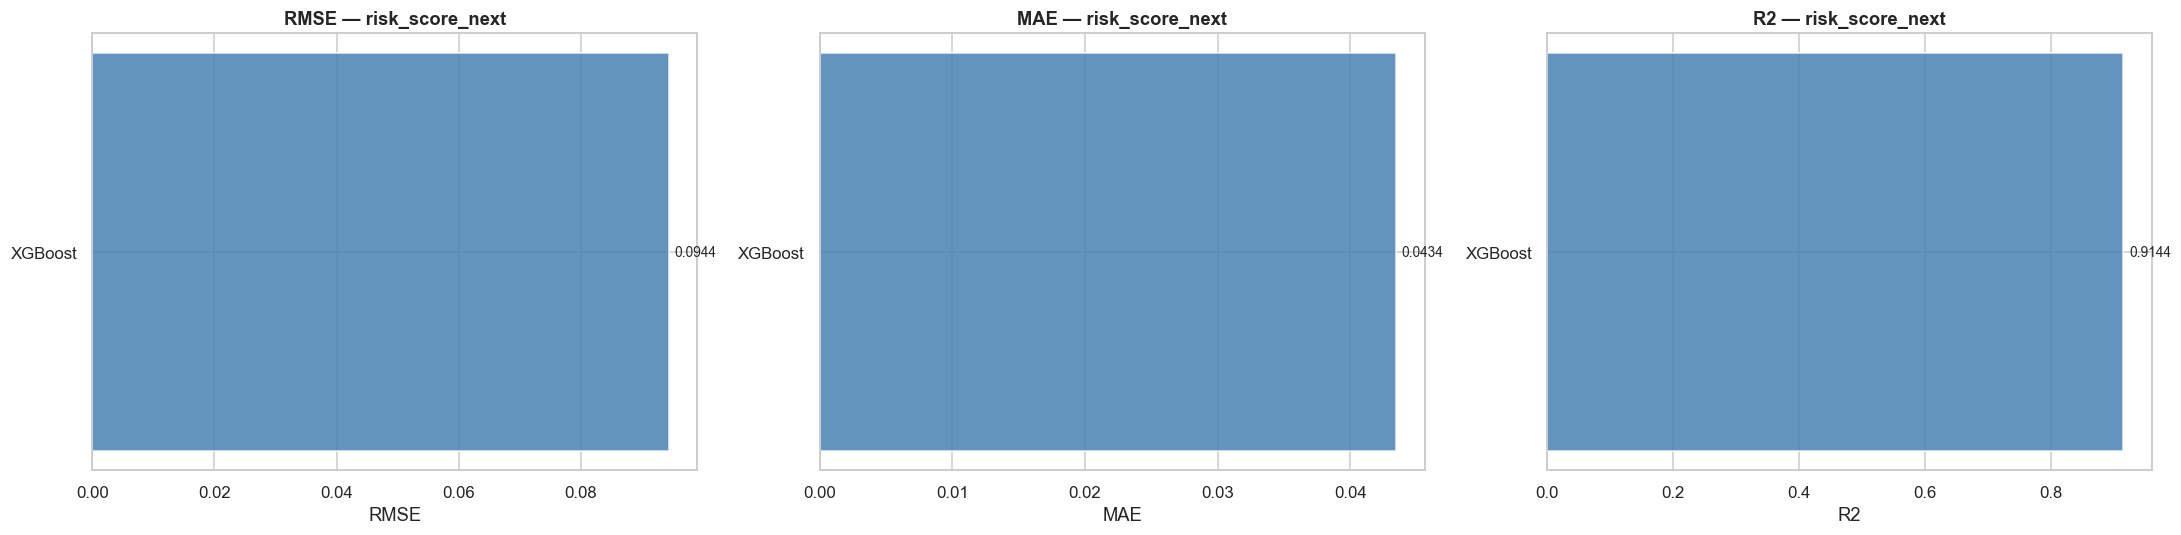

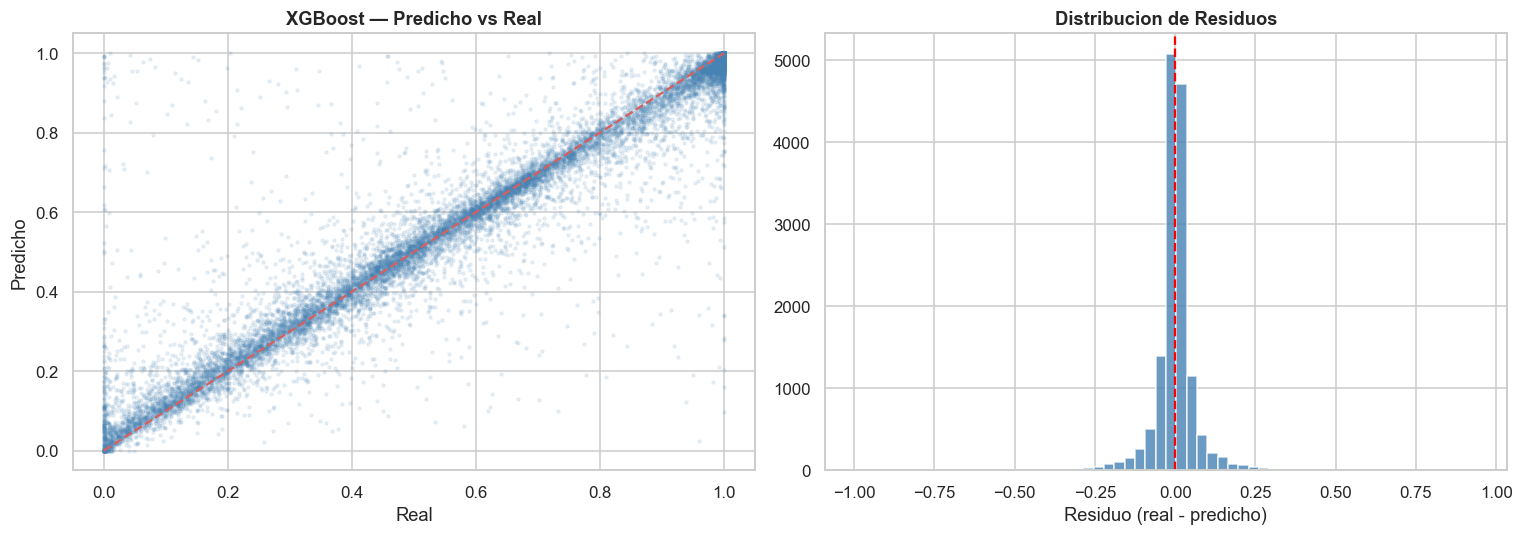

Mejor modelo: XGBoost | RMSE=0.09438 | R2=0.91439


In [24]:
# Visualizacion de metricas y grafico predicho vs real para el mejor modelo.

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, metrica, asc in zip(axes, ['RMSE','MAE','R2'], [True, True, False]):
    datos = df_reg1.sort_values(metrica, ascending=asc)
    bars  = ax.barh(datos['Modelo'], datos[metrica], color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_title(f'{metrica} — risk_score_next', fontweight='bold')
    ax.set_xlabel(metrica)
    for bar, val in zip(bars, datos[metrica]):
        ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

mejor_reg1 = df_reg1.iloc[0]['Modelo']
y_pred_mejor = np.clip(modelos_reg1_entrenados[mejor_reg1].predict(X_val), 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_reg1_val, y_pred_mejor, alpha=0.1, s=4, color='steelblue')
axes[0].plot([0,1],[0,1],'r--', lw=1.5)
axes[0].set_xlabel('Real'); axes[0].set_ylabel('Predicho')
axes[0].set_title(f'{mejor_reg1} — Predicho vs Real', fontweight='bold')

residuos = y_reg1_val - y_pred_mejor
axes[1].hist(residuos, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residuo (real - predicho)')
axes[1].set_title('Distribucion de Residuos', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Mejor modelo: {mejor_reg1} | RMSE={df_reg1.iloc[0]["RMSE"]:.5f} | R2={df_reg1.iloc[0]["R2"]:.5f}')

## 11. Tarea 2 — Regresion: `target_residual_next`

In [25]:
# Entrenamiento y evaluacion de los 13 modelos para target_residual_next.
# Se instancian copias nuevas de cada modelo para no sobreescribir los de reg1.

print('Entrenando modelos — Regresion: target_residual_next')
print('-' * 60)

res_reg2 = []
modelos_reg2_entrenados = {}

for nombre, modelo in MODELOS_REG.items():
    print(f'  Entrenando: {nombre}...')
    modelo_copia = copy.deepcopy(modelo)
    modelo_copia.fit(X_train.values, y_reg2_tr)
    y_pred   = modelo_copia.predict(X_val.values)
    metricas = evaluar_regresion(y_reg2_val, y_pred, clip=True, rango=(-1, 1))
    res_reg2.append({'Modelo': nombre, 'Familia': 'Ensamble/Boosting/DL', **metricas})
    modelos_reg2_entrenados[nombre] = modelo_copia

if GNN_REG_BUILDERS:
    print('  Construyendo grafos k-NN para GNN...')
    idx_tr = np.random.choice(len(X_train), min(8000, len(X_train)), replace=False)
    g_tr   = construir_grafos_knn(X_train.values[idx_tr], y_reg2_tr[idx_tr], k=5)
    g_val  = construir_grafos_knn(X_val.values[:3000],   y_reg2_val[:3000], k=5)

    for nombre, build_fn in GNN_REG_BUILDERS.items():
        print(f'  Entrenando: {nombre}...')
        m      = entrenar_gnn(build_fn(), g_tr, task='reg', epochs=15)
        raw    = inferir_gnn(m, g_val)
        y_pred = np.clip(raw.flatten(), -1, 1)
        metricas = evaluar_regresion(y_reg2_val[:3000], y_pred, clip=True, rango=(-1, 1))
        res_reg2.append({'Modelo': nombre, 'Familia': 'Grafo (GNN)', **metricas})
        modelos_reg2_entrenados[nombre] = m

df_reg2 = tabla_ranking(res_reg2, 'RMSE', ascendente=True)
print('\nResultados:')
df_reg2

Entrenando modelos — Regresion: target_residual_next
------------------------------------------------------------
  Entrenando: XGBoost...

Resultados:


,Modelo,Familia,RMSE,MAE,R2,MAPE
1,XGBoost,Ensamble/Boosting/DL,0.09353,0.04107,0.11595,2.0371


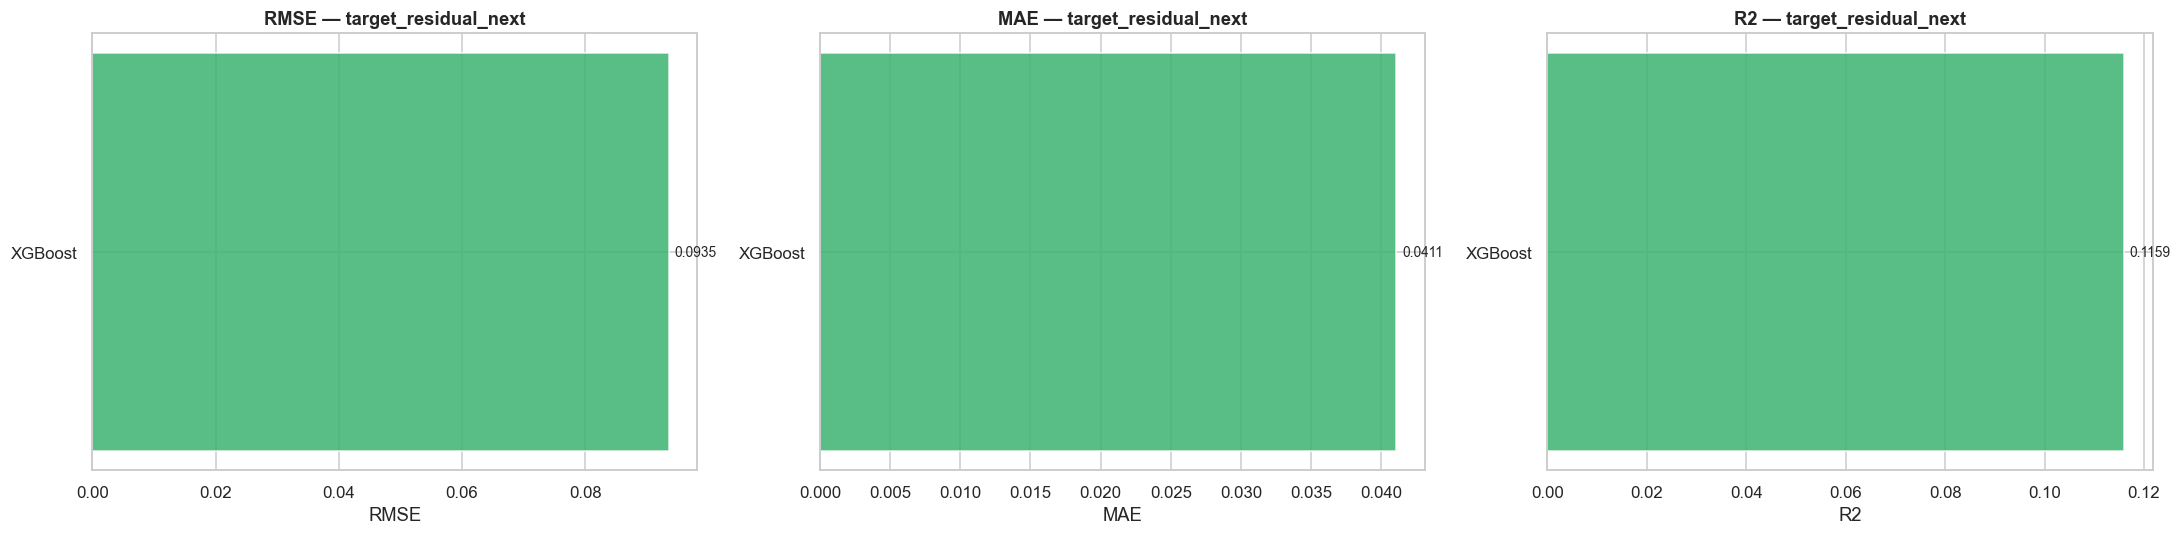

Mejor modelo: XGBoost | RMSE=0.09353 | R2=0.11595


In [26]:
# Visualizacion de metricas para target_residual_next.

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, metrica, asc in zip(axes, ['RMSE','MAE','R2'], [True, True, False]):
    datos = df_reg2.sort_values(metrica, ascending=asc)
    bars  = ax.barh(datos['Modelo'], datos[metrica], color='mediumseagreen', alpha=0.85, edgecolor='white')
    ax.set_title(f'{metrica} — target_residual_next', fontweight='bold')
    ax.set_xlabel(metrica)
    for bar, val in zip(bars, datos[metrica]):
        ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

mejor_reg2 = df_reg2.iloc[0]['Modelo']
print(f'Mejor modelo: {mejor_reg2} | RMSE={df_reg2.iloc[0]["RMSE"]:.5f} | R2={df_reg2.iloc[0]["R2"]:.5f}')

## 12. Tarea 3 — Clasificacion Binaria: `target_distress_next`

In [27]:
# Entrenamiento y evaluacion de los 13 modelos para target_distress_next.
# El entrenamiento usa datos balanceados (X_bal_bin / y_bal_bin).
# La evaluacion siempre se realiza sobre el conjunto de validacion original.

print('Entrenando modelos — Clasificacion Binaria: target_distress_next')
print('-' * 65)

res_bin = []
modelos_bin_entrenados = {}

for nombre, modelo in MODELOS_BIN.items():
    print(f'  Entrenando: {nombre}...')
    modelo_copia = copy.deepcopy(modelo)
    modelo_copia.fit(X_bal_bin, y_bal_bin)
    y_pred   = modelo_copia.predict(X_val.values)
    y_prob   = modelo_copia.predict_proba(X_val.values)[:, 1] \
               if hasattr(modelo_copia, 'predict_proba') else None
    metricas = evaluar_binaria(y_bin_val, y_pred, y_prob)
    res_bin.append({'Modelo': nombre, 'Familia': 'Ensamble/Boosting/DL', **metricas})
    modelos_bin_entrenados[nombre] = modelo_copia

if GNN_BIN_BUILDERS:
    print('  Construyendo grafos k-NN para GNN binaria...')
    idx_tr  = np.random.choice(len(X_bal_bin), min(8000, len(X_bal_bin)), replace=False)
    g_tr    = construir_grafos_knn(X_bal_bin[idx_tr], y_bal_bin[idx_tr], k=5)
    g_val   = construir_grafos_knn(X_val.values[:3000], y_bin_val[:3000], k=5)

    for nombre, build_fn in GNN_BIN_BUILDERS.items():
        print(f'  Entrenando: {nombre}...')
        m      = entrenar_gnn(build_fn(), g_tr, task='bin', epochs=15)
        logits = inferir_gnn(m, g_val).flatten()
        probs  = torch.sigmoid(torch.tensor(logits)).numpy()
        preds  = (probs > 0.5).astype(int)
        metricas = evaluar_binaria(y_bin_val[:3000], preds, probs)
        res_bin.append({'Modelo': nombre, 'Familia': 'Grafo (GNN)', **metricas})
        modelos_bin_entrenados[nombre] = m

df_bin = tabla_ranking(res_bin, 'F1', ascendente=False)
print('\nResultados:')
df_bin

Entrenando modelos — Clasificacion Binaria: target_distress_next
-----------------------------------------------------------------
  Entrenando: XGBoost...

Resultados:


,Modelo,Familia,Accuracy,Precision,Recall,F1,ROC-AUC
1,XGBoost,Ensamble/Boosting/DL,0.9516,0.9618,0.9565,0.9591,0.9868


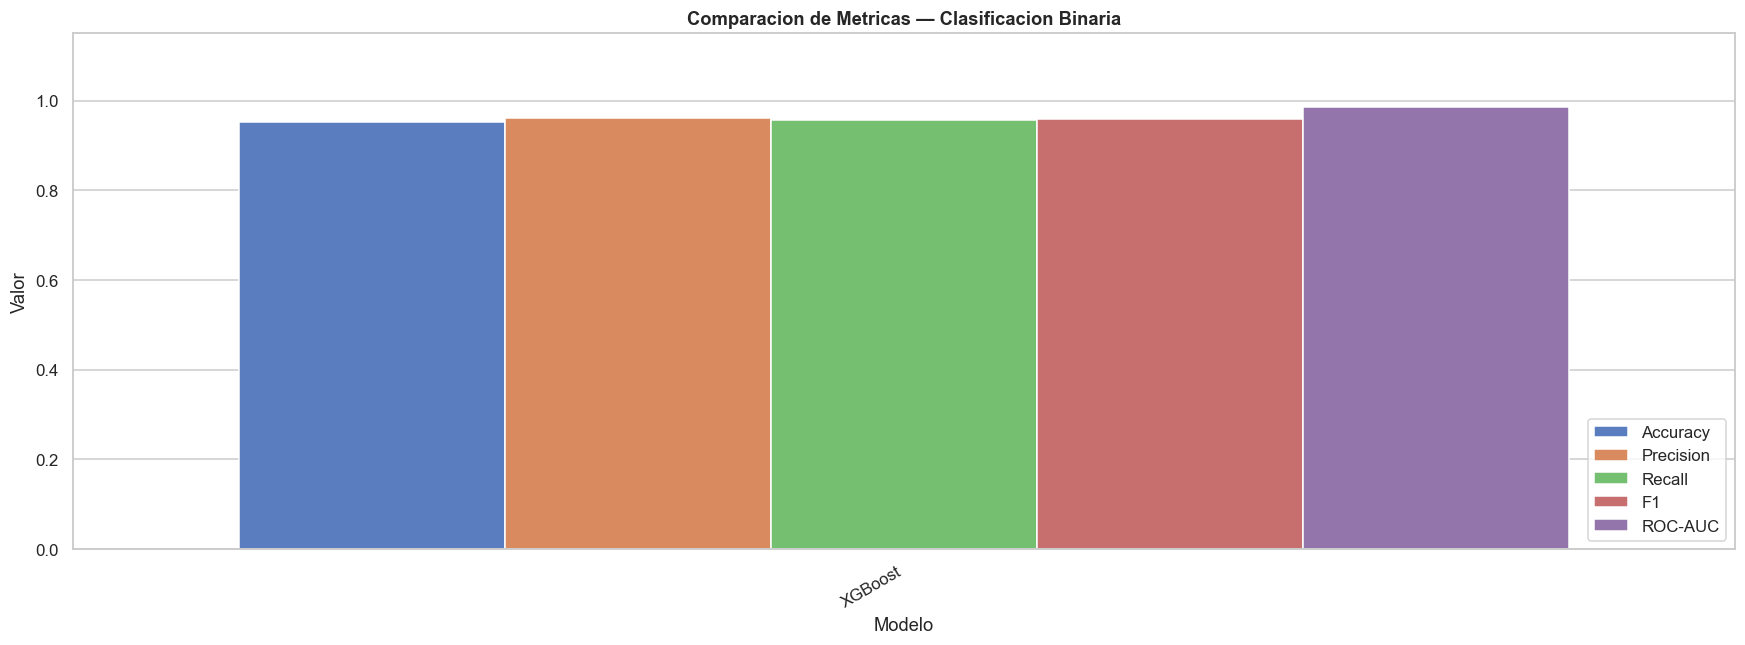

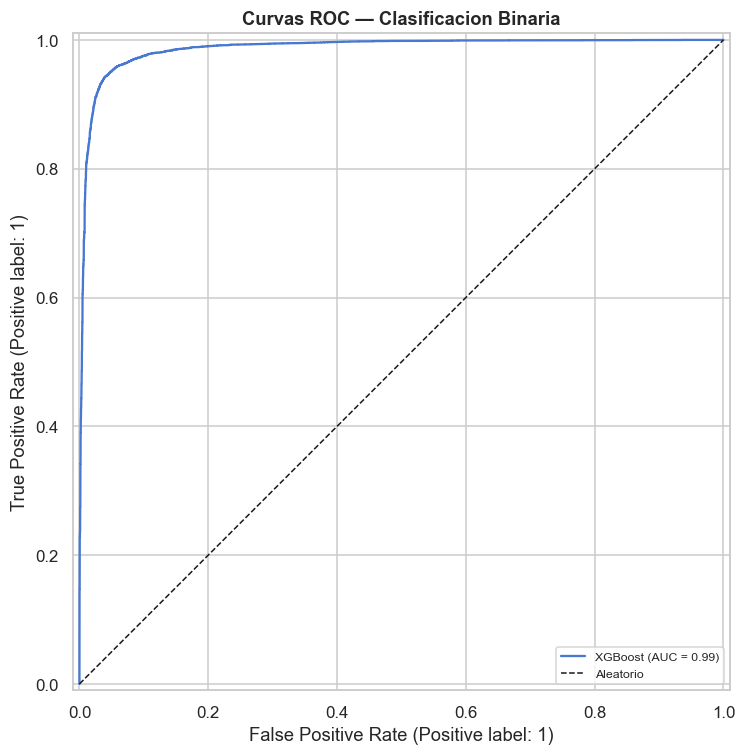

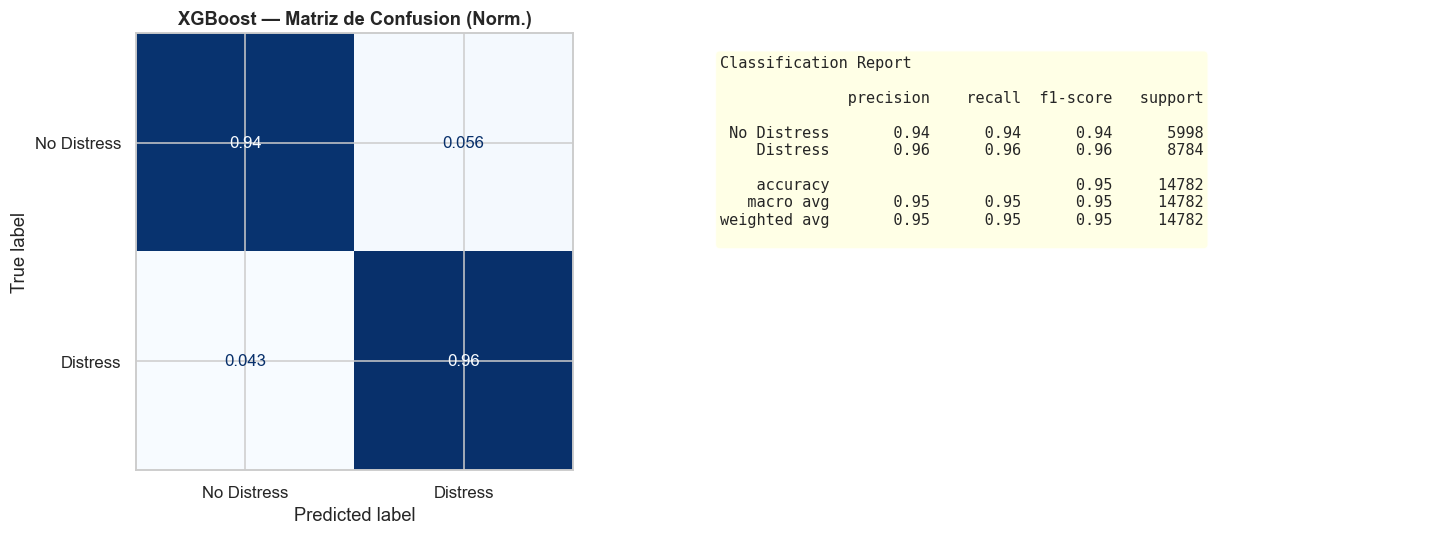

Mejor modelo: XGBoost | F1=0.9591 | ROC-AUC=0.9868


In [28]:
# Visualizacion: barras de metricas, curvas ROC y matriz de confusion.

metricas_bin = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
df_melt_bin  = df_bin.melt(id_vars='Modelo', value_vars=metricas_bin,
                            var_name='Metrica', value_name='Valor')

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=df_melt_bin, x='Modelo', y='Valor', hue='Metrica', ax=ax)
ax.set_title('Comparacion de Metricas — Clasificacion Binaria', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Curvas ROC
fig, ax = plt.subplots(figsize=(9, 7))
for nombre, modelo in modelos_bin_entrenados.items():
    if hasattr(modelo, 'predict_proba'):
        prob = modelo.predict_proba(X_val)[:, 1]
        RocCurveDisplay.from_predictions(y_bin_val, prob, name=nombre, ax=ax)
ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatorio')
ax.set_title('Curvas ROC — Clasificacion Binaria', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Matriz de confusion del mejor modelo
mejor_bin = df_bin.iloc[0]['Modelo']
y_pred_mejor_bin = modelos_bin_entrenados[mejor_bin].predict(X_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_bin_val, y_pred_mejor_bin, normalize='true')
ConfusionMatrixDisplay(cm, display_labels=['No Distress', 'Distress']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'{mejor_bin} — Matriz de Confusion (Norm.)', fontweight='bold')

reporte = classification_report(y_bin_val, y_pred_mejor_bin,
                                target_names=['No Distress', 'Distress'])
axes[1].axis('off')
axes[1].text(0.05, 0.95, 'Classification Report\n\n' + reporte,
             transform=axes[1].transAxes, fontsize=10, va='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.show()
print(f'Mejor modelo: {mejor_bin} | F1={df_bin.iloc[0]["F1"]:.4f} | ROC-AUC={df_bin.iloc[0]["ROC-AUC"]:.4f}')

## 13. Tarea 4 — Clasificacion Multiclase: `target_class_next`

In [49]:
# Entrenamiento y evaluacion de los 13 modelos para target_class_next.
# El entrenamiento usa datos balanceados (X_bal_mc / y_bal_mc).

print('Entrenando modelos — Clasificacion Multiclase: target_class_next')
print('-' * 65)

res_multi = []
modelos_multi_entrenados = {}

for nombre, modelo in MODELOS_MULTI.items():
    print(f'  Entrenando: {nombre}...')
    modelo_copia = copy.deepcopy(modelo)
    modelo_copia.fit(X_bal_mc, y_bal_mc)
    y_pred   = modelo_copia.predict(X_val.values)
    y_prob   = modelo_copia.predict_proba(X_val.values) \
               if hasattr(modelo_copia, 'predict_proba') else None
    metricas = evaluar_multiclase(y_mc_val, y_pred, y_prob)
    res_multi.append({'Modelo': nombre, 'Familia': 'Ensamble/Boosting/DL', **metricas})
    modelos_multi_entrenados[nombre] = modelo_copia

if GNN_MULTI_BUILDERS:
    print('  Construyendo grafos k-NN para GNN multiclase...')
    idx_tr = np.random.choice(len(X_bal_mc), min(8000, len(X_bal_mc)), replace=False)
    g_tr   = construir_grafos_knn(X_bal_mc[idx_tr], y_bal_mc[idx_tr], k=5)
    g_val  = construir_grafos_knn(X_val.values[:3000], y_mc_val[:3000], k=5)

    for nombre, build_fn in GNN_MULTI_BUILDERS.items():
        print(f'  Entrenando: {nombre}...')
        m      = entrenar_gnn(build_fn(), g_tr, task='multi', epochs=15)
        logits = inferir_gnn(m, g_val)
        probs  = torch.softmax(torch.tensor(logits), dim=-1).numpy()
        preds  = probs.argmax(axis=1)
        metricas = evaluar_multiclase(y_mc_val[:3000], preds, probs)
        res_multi.append({'Modelo': nombre, 'Familia': 'Grafo (GNN)', **metricas})
        modelos_multi_entrenados[nombre] = m

df_multi = tabla_ranking(res_multi, 'F1 Macro', ascendente=False)
print('\nResultados:')
df_multi

Entrenando modelos — Clasificacion Multiclase: target_class_next
-----------------------------------------------------------------
  Entrenando: XGBoost...

Resultados:


,Modelo,Familia,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,ROC-AUC OvR
1,XGBoost,Ensamble/Boosting/DL,0.9194,0.9133,0.9195,0.9126,0.9141,0.9824


## 13.1 Ablación de Features — `target_class_next`

Herramienta para evaluar el impacto de quitar features sospechosas de
inflar las métricas multiclase. Solo XGBoost (el modelo ganador).
SMOTE se recalcula en cada corrida sobre el subset reducido para
evitar contaminación de los puntos sintéticos.

**Uso:** editar `FEATURES_A_QUITAR` en la celda siguiente y re-ejecutar
las 4 celdas en orden.

In [58]:
# ============================================================================
# ABLACION — Modo de operacion
# ----------------------------------------------------------------------------
# MODO_QUITAR  : se quitan las features de la lista FEATURES_A_QUITAR
#                (resto se mantiene)
# MODO_QUEDARME: se conservan SOLO las features de FEATURES_A_QUEDARME
#                (resto se quita)
# ============================================================================

MODO = 'QUEDARME'   # 'QUITAR' o 'QUEDARME'

# ---- Lista para MODO_QUITAR ------------------------------------------------
FEATURES_A_QUITAR = [
    # 'fe_delta_risk_score_prev',
    # 'fe_delta_risk_score_qoq',
    # 'fe_delta_zscore_qoq',
    # 'fe_delta_risk_deterioro',
    # 'fe_flag_deficit_acumulado',
    # 'fe_flag_margen_negativo',
    # 'fe_flag_perdida_neta',
]

# ---- Lista para MODO_QUEDARME ----------------------------------------------
# Solo las features de esta lista entran al modelo. El resto se descarta.
# Util para preguntar: "¿con que minimo el modelo se sostiene?"
FEATURES_A_QUEDARME = [
    # --- Las 4 Cat B autoregresivas (sospechosas principales) ---
    'fe_delta_risk_score_prev',
    #'fe_delta_risk_score_qoq',
    #'fe_delta_zscore_qoq',
    #'fe_delta_risk_deterioro',

    # --- Flags fundamentales ---
    # 'fe_flag_deficit_acumulado',
    # 'fe_flag_margen_negativo',
    # 'fe_flag_perdida_neta',

    # --- Algun ratio o lo que quieras agregar ---
    # 'fe_ratio_cobertura_intereses',
]

# ============================================================================
# Construccion del subset segun el modo
# ============================================================================

if MODO == 'QUITAR':
    inexistentes = [c for c in FEATURES_A_QUITAR if c not in FEATURE_COLS]
    assert len(inexistentes) == 0, f'No existen en FEATURE_COLS: {inexistentes}'
    FEATURE_COLS_ABLACION = [c for c in FEATURE_COLS if c not in FEATURES_A_QUITAR]
    descripcion_corrida   = (FEATURES_A_QUITAR if FEATURES_A_QUITAR
                             else ['(baseline)'])
    etiqueta_modo         = f'QUITAR ({len(FEATURES_A_QUITAR)} features)'

elif MODO == 'QUEDARME':
    assert len(FEATURES_A_QUEDARME) > 0, \
        'FEATURES_A_QUEDARME esta vacia — el modelo no puede entrenar sin features'
    inexistentes = [c for c in FEATURES_A_QUEDARME if c not in FEATURE_COLS]
    assert len(inexistentes) == 0, f'No existen en FEATURE_COLS: {inexistentes}'
    FEATURE_COLS_ABLACION = [c for c in FEATURE_COLS if c in FEATURES_A_QUEDARME]
    descripcion_corrida   = FEATURES_A_QUEDARME
    etiqueta_modo         = f'QUEDARME con {len(FEATURES_A_QUEDARME)} features'

else:
    raise ValueError(f'MODO invalido: {MODO!r}. Usar "QUITAR" o "QUEDARME"')

# ============================================================================
# Reporte
# ============================================================================

print(f'Modo de operacion : {etiqueta_modo}')
print(f'Features que entran al modelo: {len(FEATURE_COLS_ABLACION)} '
      f'(de {len(FEATURE_COLS)} originales)')
print()
print('Features que entran:')
for c in FEATURE_COLS_ABLACION:
    print(f'  + {c}')


# ============================================================================
# Recalcular SMOTE sobre el subset reducido de features.
# Esto es la opcion B (decision arquitectonica): SMOTE genera puntos sinteticos
# usando solo las features que el modelo va a ver, evitando que la informacion
# de las features quitadas se filtre por la via de los vecinos sinteticos.
# ============================================================================

from imblearn.over_sampling import SMOTE
import time

X_train_abl = X_train[FEATURE_COLS_ABLACION].values
X_val_abl   = X_val[FEATURE_COLS_ABLACION].values

print(f'Aplicando SMOTE sobre {X_train_abl.shape[0]:,} filas x '
      f'{X_train_abl.shape[1]} features...')
t0 = time.time()

smote_abl = SMOTE(random_state=42, k_neighbors=5)
X_bal_mc_abl, y_bal_mc_abl = smote_abl.fit_resample(X_train_abl, y_mc_tr)

t_smote = time.time() - t0
print(f'SMOTE completado en {t_smote:.1f}s')
print(f'Filas balanceadas      : {X_bal_mc_abl.shape[0]:,}')
print(f'Distribucion post-SMOTE: {dict(zip(*np.unique(y_bal_mc_abl, return_counts=True)))}')

# ============================================================================
# Entrenar XGBoost sobre el subset reducido y evaluar sobre validacion.
# Se usa una copia limpia del XGBoost definido en MODELOS_MULTI para no
# contaminar el modelo original que quedo entrenado con todas las features.
# ============================================================================

print(f'Entrenando XGBoost sobre {X_bal_mc_abl.shape[0]:,} filas balanceadas '
      f'x {X_bal_mc_abl.shape[1]} features...')
t0 = time.time()

xgb_abl = copy.deepcopy(MODELOS_MULTI['XGBoost'])
xgb_abl.fit(X_bal_mc_abl, y_bal_mc_abl)

t_train = time.time() - t0
print(f'Entrenamiento completado en {t_train:.1f}s')

# Predecir sobre validacion (con el subset reducido de columnas)
y_pred_abl = xgb_abl.predict(X_val_abl)
y_prob_abl = xgb_abl.predict_proba(X_val_abl)

# Calcular metricas con la funcion auxiliar ya existente
metricas_ablacion = evaluar_multiclase(y_mc_val, y_pred_abl, y_prob_abl)

print(f'\nMetricas de la ablacion:')
for k, v in metricas_ablacion.items():
    print(f'  {k:18}: {v:.4f}')


# ============================================================================
# Comparacion baseline (todas las features) vs ablacion (sin las quitadas)
# y persistencia del historial de experimentos.
# ============================================================================

# -- Recuperar metricas del baseline (XGBoost con todas las features, ya entrenado) -----
fila_xgb_baseline = df_multi[df_multi['Modelo'] == 'XGBoost'].iloc[0]
metricas_baseline = {
    'Accuracy'        : fila_xgb_baseline['Accuracy'],
    'F1 Macro'        : fila_xgb_baseline['F1 Macro'],
    'F1 Weighted'     : fila_xgb_baseline['F1 Weighted'],
    'Precision Macro' : fila_xgb_baseline['Precision Macro'],
    'Recall Macro'    : fila_xgb_baseline['Recall Macro'],
    'ROC-AUC OvR'     : fila_xgb_baseline['ROC-AUC OvR'],
}

# -- Tabla comparativa (esta corrida) ----------------------------------------
metricas_a_mostrar = ['Accuracy', 'F1 Macro', 'F1 Weighted',
                      'Precision Macro', 'Recall Macro', 'ROC-AUC OvR']

print('=' * 78)
print(f'COMPARACION — XGBoost multiclase')
print(f'Features quitadas: {FEATURES_A_QUITAR if FEATURES_A_QUITAR else "[ninguna — corrida baseline]"}')
print('=' * 78)
print(f"{'Metrica':<20} {'Baseline':>12} {'Ablacion':>12} {'Delta':>12}  {'':>4}")
print('-' * 78)
for m in metricas_a_mostrar:
    base  = metricas_baseline[m]
    abl   = metricas_ablacion[m]
    delta = abl - base
    flag  = 'CAE' if delta < -0.005 else ('SUBE' if delta > 0.005 else 'igual')
    print(f"{m:<20} {base:>12.4f} {abl:>12.4f} {delta:>+12.4f}  {flag:>4}")
print('=' * 78)

# -- Historial acumulado de experimentos -------------------------------------
# Inicializar el historial la primera vez que se corre la celda
if 'historial_ablacion' not in dir():
    historial_ablacion = pd.DataFrame(columns=[
        'experimento', 'features_quitadas', 'n_quitadas', 'n_features_usadas',
        *metricas_a_mostrar
    ])

# Agregar fila al historial
nueva_fila = {
    'experimento'      : len(historial_ablacion) + 1,
    'modo'           : etiqueta_modo,
    'features_descr' : ', '.join(descripcion_corrida) if isinstance(descripcion_corrida, list) and descripcion_corrida != ['(baseline)'] else '(baseline)',
    'n_quitadas'       : len(FEATURES_A_QUITAR),
    'n_features_usadas': len(FEATURE_COLS_ABLACION),
    **{m: metricas_ablacion[m] for m in metricas_a_mostrar},
}
historial_ablacion = pd.concat(
    [historial_ablacion, pd.DataFrame([nueva_fila])],
    ignore_index=True
)

print(f'\nHistorial de experimentos ({len(historial_ablacion)} corridas):\n')
display(historial_ablacion[['experimento', 'modo', 'n_features_usadas',
                            'F1 Macro', 'ROC-AUC OvR', 'Accuracy',
                            'features_descr']])

Modo de operacion : QUEDARME con 1 features
Features que entran al modelo: 1 (de 85 originales)

Features que entran:
  + fe_delta_risk_score_prev
Aplicando SMOTE sobre 74,659 filas x 1 features...
SMOTE completado en 0.1s
Filas balanceadas      : 105,537
Distribucion post-SMOTE: {np.int64(0): np.int64(35179), np.int64(1): np.int64(35179), np.int64(2): np.int64(35179)}
Entrenando XGBoost sobre 105,537 filas balanceadas x 1 features...
Entrenamiento completado en 2.0s

Metricas de la ablacion:
  Accuracy          : 0.8729
  F1 Macro          : 0.8640
  F1 Weighted       : 0.8735
  Precision Macro   : 0.8627
  Recall Macro      : 0.8655
  ROC-AUC OvR       : 0.9491
COMPARACION — XGBoost multiclase
Features quitadas: [ninguna — corrida baseline]
Metrica                  Baseline     Ablacion        Delta      
------------------------------------------------------------------------------
Accuracy                   0.9194       0.8729      -0.0465   CAE
F1 Macro                   0.9133   

,experimento,modo,n_features_usadas,F1 Macro,ROC-AUC OvR,Accuracy,features_descr
0,1,NaN,85,0.9147,0.9825,0.9206,NaN
1,2,NaN,81,0.8561,0.9633,0.8643,NaN
2,3,NaN,78,0.8374,0.9552,0.8465,NaN
3,4,NaN,71,0.8347,0.9544,0.8433,NaN
4,5,NaN,78,0.9161,0.9826,0.9218,NaN
5,6,QUEDARME con 4 features,4,0.9077,0.9774,0.9136,"fe_delta_risk_score_prev, fe_delta_risk_score_..."
6,7,QUEDARME con 1 features,1,0.8640,0.9491,0.8729,fe_delta_risk_score_prev


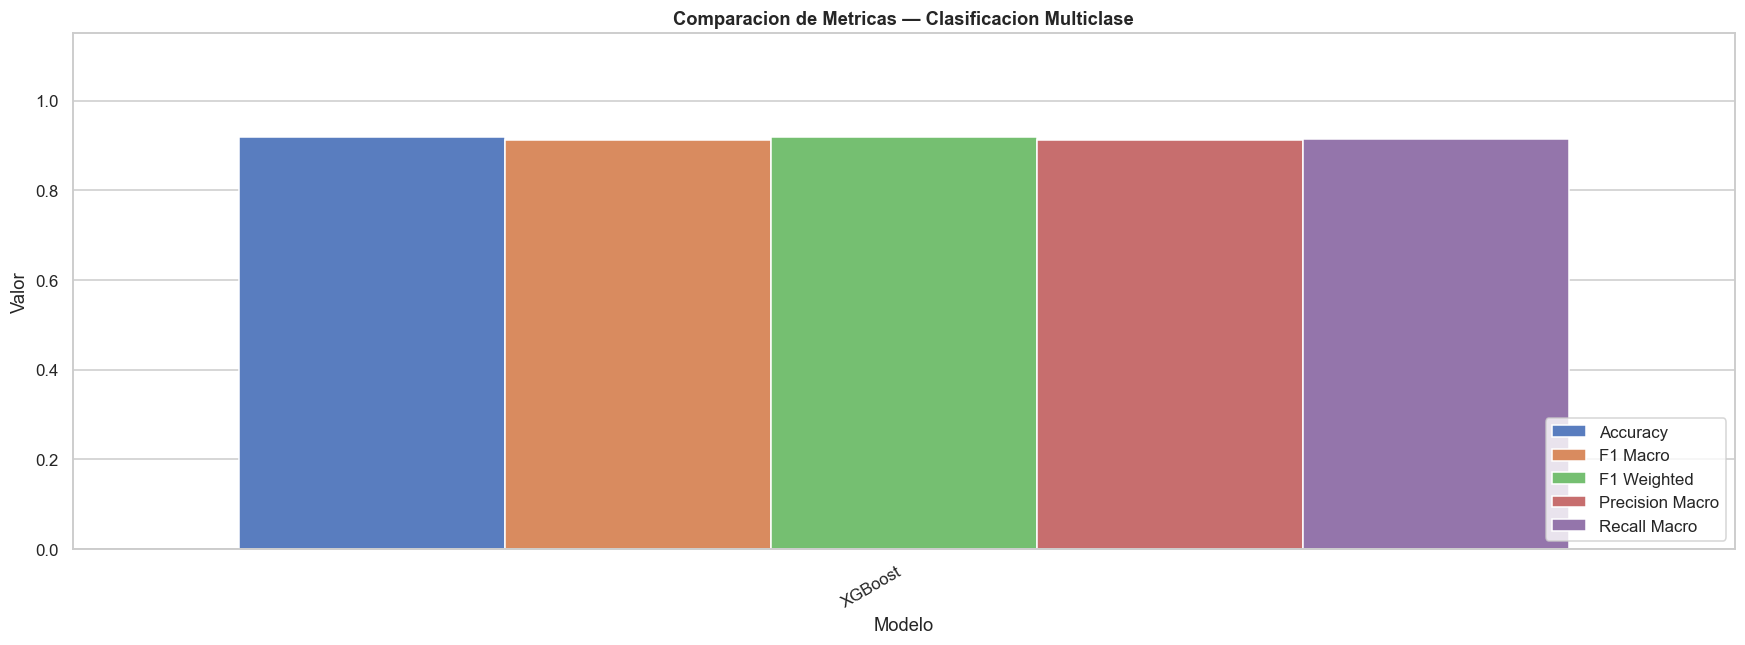

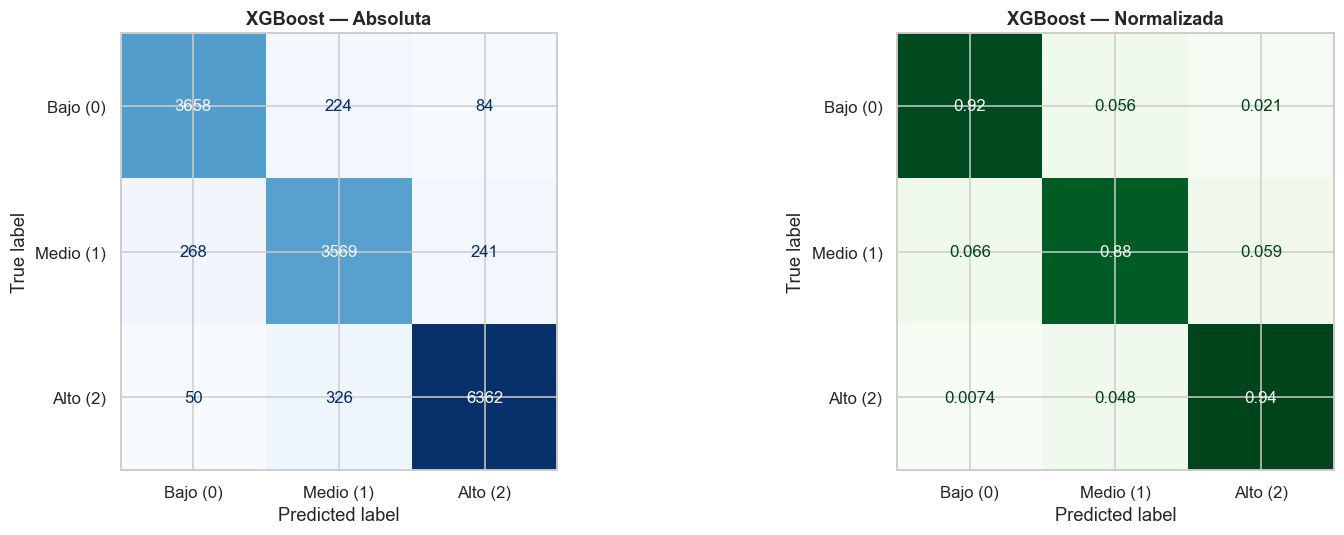


Classification Report — XGBoost
              precision    recall  f1-score   support

    Bajo (0)       0.92      0.92      0.92      3966
   Medio (1)       0.87      0.88      0.87      4078
    Alto (2)       0.95      0.94      0.95      6738

    accuracy                           0.92     14782
   macro avg       0.91      0.91      0.91     14782
weighted avg       0.92      0.92      0.92     14782

Mejor modelo: XGBoost | F1 Macro=0.9133


In [30]:
# Visualizacion de metricas multiclase y matrices de confusion.

metricas_mc = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Precision Macro', 'Recall Macro']
df_melt_mc  = df_multi.melt(id_vars='Modelo', value_vars=metricas_mc,
                             var_name='Metrica', value_name='Valor')

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=df_melt_mc, x='Modelo', y='Valor', hue='Metrica', ax=ax)
ax.set_title('Comparacion de Metricas — Clasificacion Multiclase', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Matrices de confusion del mejor modelo
mejor_multi = df_multi.iloc[0]['Modelo']
y_pred_mejor_multi = modelos_multi_entrenados[mejor_multi].predict(X_val)
nombres_clase = ['Bajo (0)', 'Medio (1)', 'Alto (2)']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cm_abs = confusion_matrix(y_mc_val, y_pred_mejor_multi)
ConfusionMatrixDisplay(cm_abs, display_labels=nombres_clase).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'{mejor_multi} — Absoluta', fontweight='bold')

cm_norm = confusion_matrix(y_mc_val, y_pred_mejor_multi, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=nombres_clase).plot(
    ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'{mejor_multi} — Normalizada', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nClassification Report — {mejor_multi}')
print(classification_report(y_mc_val, y_pred_mejor_multi, target_names=nombres_clase))
print(f'Mejor modelo: {mejor_multi} | F1 Macro={df_multi.iloc[0]["F1 Macro"]:.4f}')

## 14. Importancia de Features — Mejores Modelos

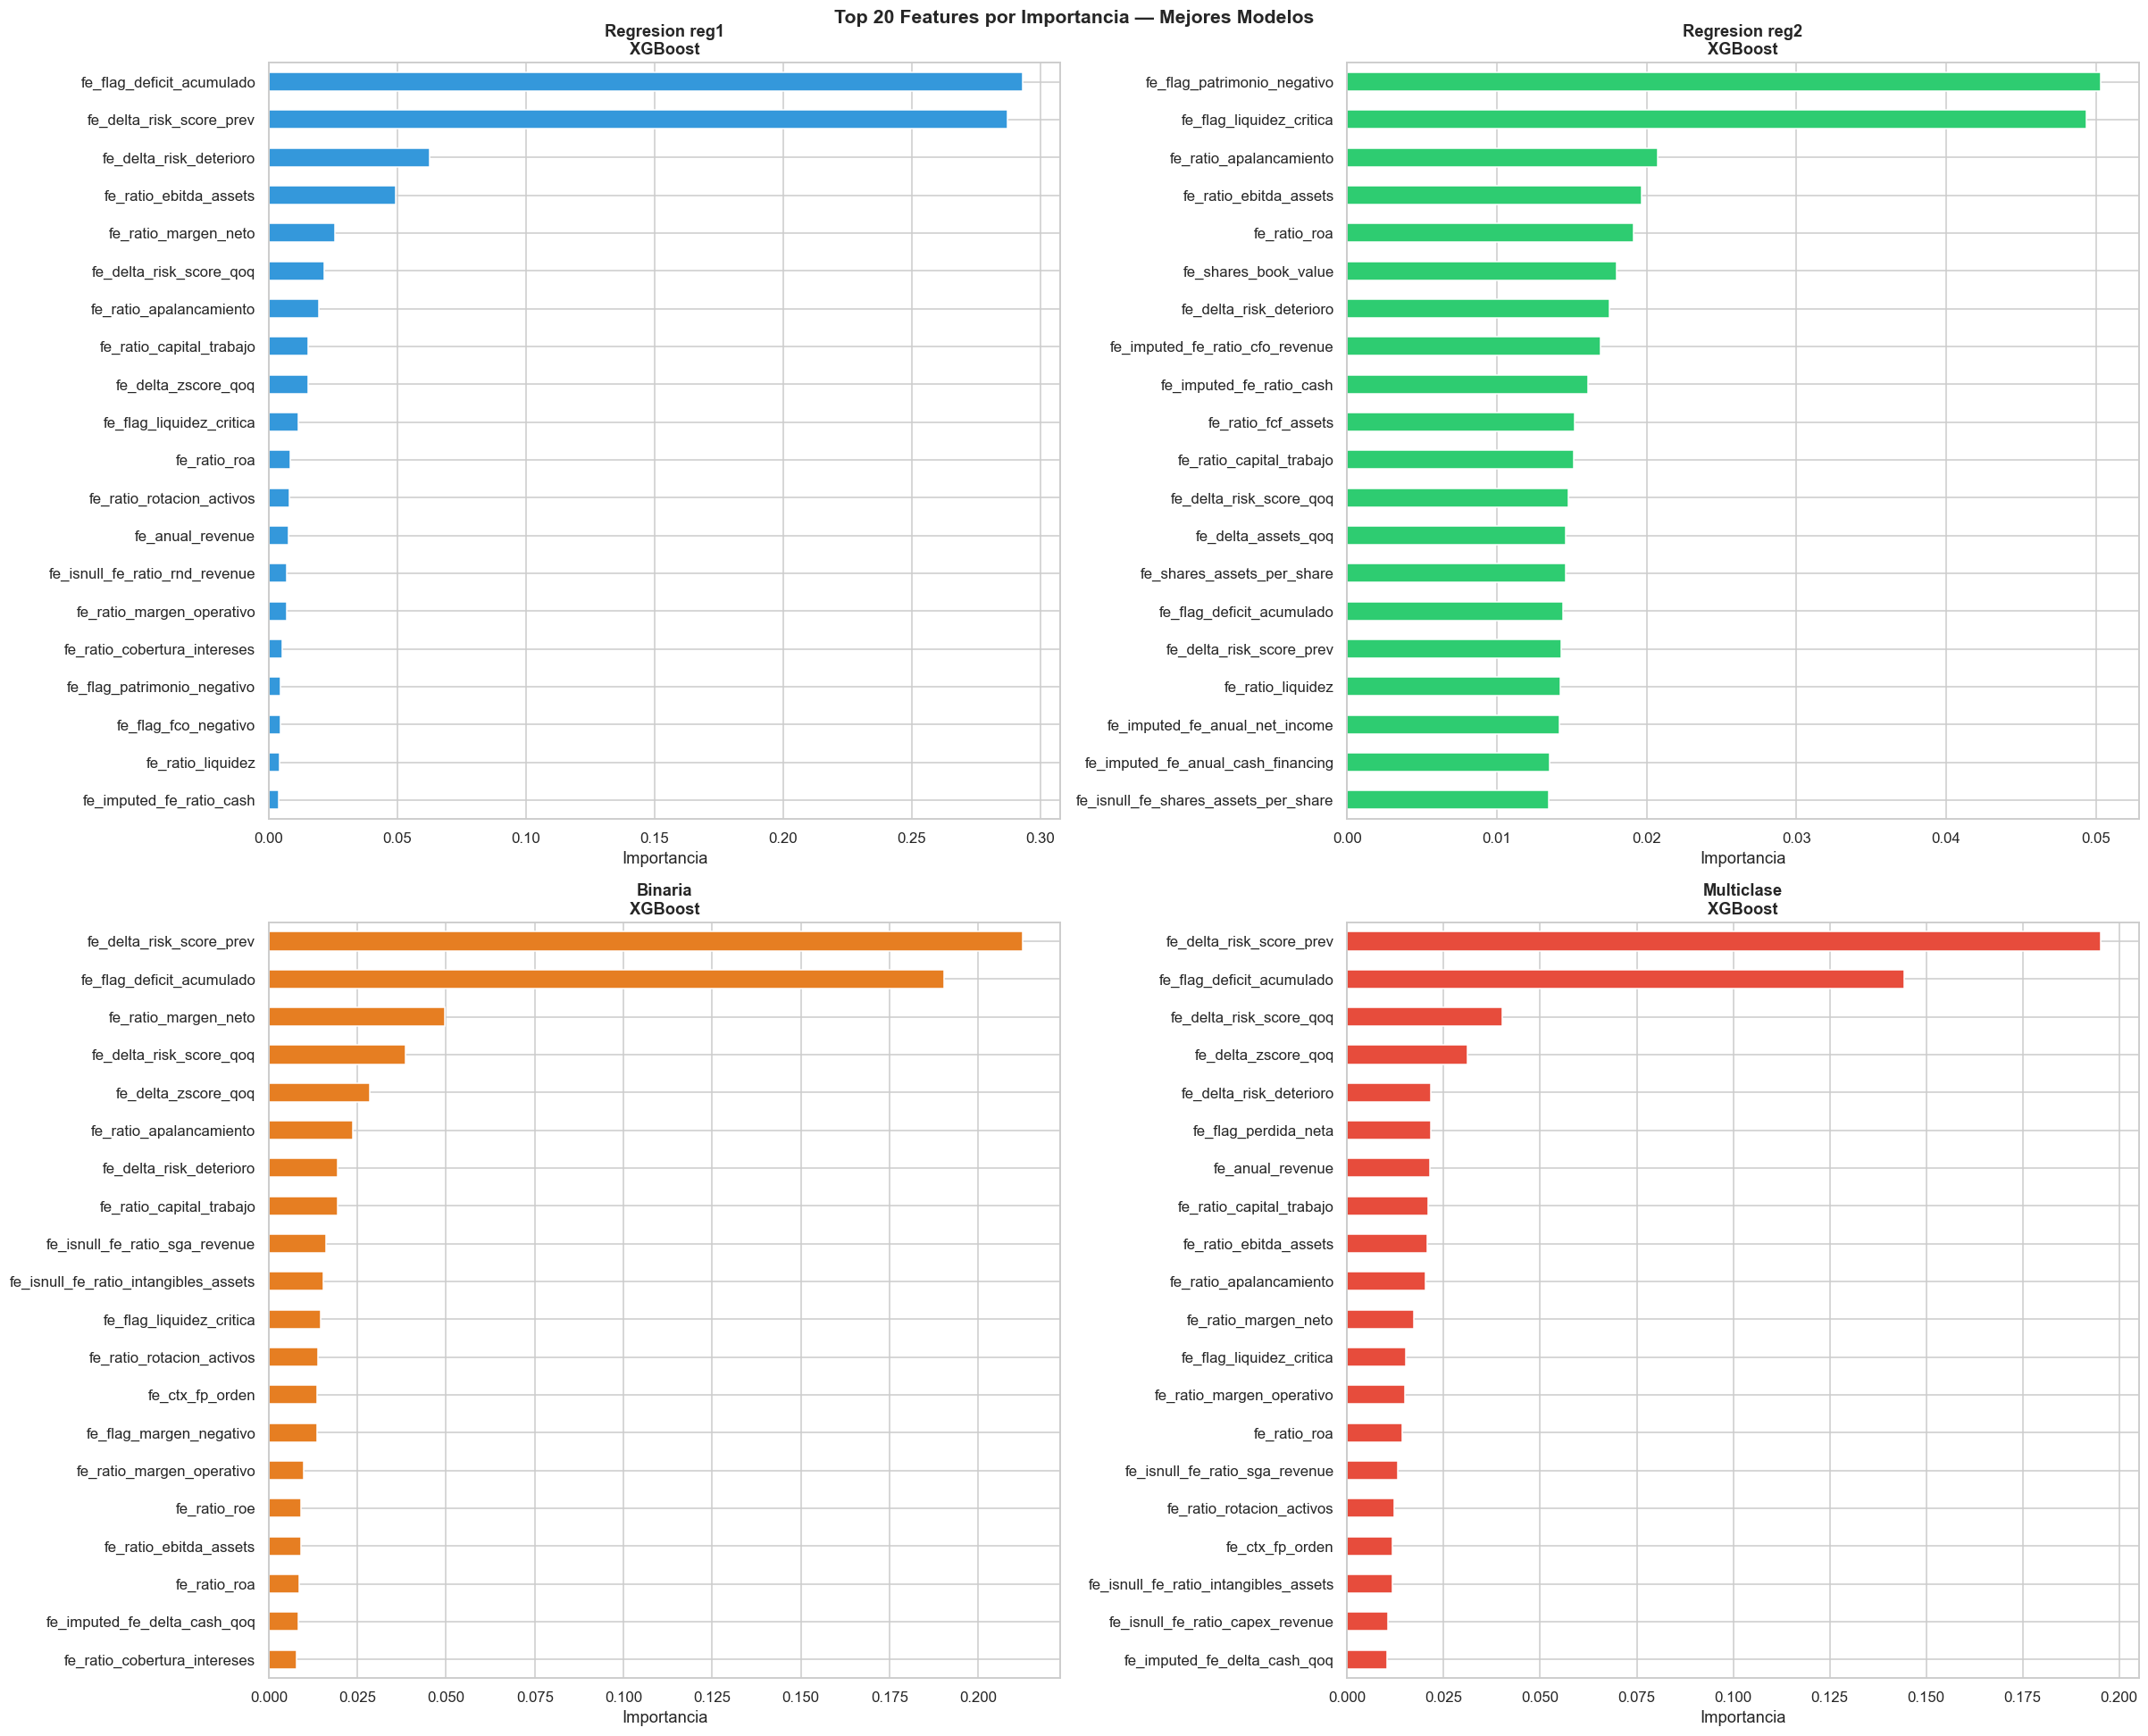

In [31]:
# Visualizacion de la importancia de features para los mejores modelos
# de cada tarea. Solo aplica para modelos basados en arboles.

def graficar_importancia(modelo, feature_names, titulo, ax, color='steelblue', top_n=20):
    if not hasattr(modelo, 'feature_importances_'):
        ax.text(0.5, 0.5,
                f'{titulo}\n\nModelo sin feature_importances_.\nUsar SHAP para interpretabilidad.',
                ha='center', va='center', transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='#fef9e7', alpha=0.8))
        ax.axis('off')
        return
    importancias = pd.Series(modelo.feature_importances_, index=feature_names)
    importancias = importancias.sort_values(ascending=True).tail(top_n)
    importancias.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Importancia')

fig, axes = plt.subplots(2, 2, figsize=(22, 18))

graficar_importancia(
    modelos_reg1_entrenados.get(mejor_reg1),
    FEATURE_COLS, f'Regresion reg1\n{mejor_reg1}', axes[0][0], color='#3498db')

graficar_importancia(
    modelos_reg2_entrenados.get(mejor_reg2),
    FEATURE_COLS, f'Regresion reg2\n{mejor_reg2}', axes[0][1], color='#2ecc71')

graficar_importancia(
    modelos_bin_entrenados.get(mejor_bin),
    FEATURE_COLS, f'Binaria\n{mejor_bin}', axes[1][0], color='#e67e22')

graficar_importancia(
    modelos_multi_entrenados.get(mejor_multi),
    FEATURE_COLS, f'Multiclase\n{mejor_multi}', axes[1][1], color='#e74c3c')

plt.suptitle('Top 20 Features por Importancia — Mejores Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# ============================================================================
# VALIDACIÓN PRE-OPTUNA — PR-AUC y diagnóstico de overfitting
# ----------------------------------------------------------------------------
# Antes de gastar tiempo en Optuna, validamos:
#   1. PR-AUC para clasificación (más honesto que ROC-AUC con desbalance)
#   2. Comparación entre desempeño en train vs val para detectar overfit
#   3. Confirmar que las metricas binarias no estan infladas
# ============================================================================

from sklearn.metrics import average_precision_score

print("="*72)
print("VALIDACIÓN PRE-OPTUNA")
print("="*72)

# -- PARTE 1: PR-AUC para clasificación binaria ------------------------------
print("\n[1] PR-AUC vs ROC-AUC para clasificación binaria")
print("-"*72)

modelo_xgb_bin = modelos_bin_entrenados['XGBoost']
y_prob_bin_val = modelo_xgb_bin.predict_proba(X_val.values)[:, 1]

# PR-AUC (Average Precision)
pr_auc_val = average_precision_score(y_bin_val, y_prob_bin_val)
print(f"  ROC-AUC (val) : 0.9868   (lo que reporta el notebook)")
print(f"  PR-AUC  (val) : {pr_auc_val:.4f}   (más honesto con desbalance)")

# Baseline PR-AUC: la prevalencia de la clase positiva
prevalencia = y_bin_val.mean()
print(f"  Baseline PR-AUC (prevalencia): {prevalencia:.4f}")
print(f"  Mejora del modelo sobre baseline: +{(pr_auc_val - prevalencia)*100:.1f} puntos")

if pr_auc_val > 0.95:
    print(f"\n  PR-AUC > 0.95 confirma desempeño excelente, no era inflado por ROC-AUC")
elif pr_auc_val > 0.85:
    print(f"\n  PR-AUC sólido pero menor que ROC-AUC — el desbalance influía algo")
else:
    print(f"\n  PR-AUC bajo ({pr_auc_val:.3f}) — ROC-AUC estaba inflado por el desbalance")

# -- PARTE 2: Detectar overfitting (train vs val) ----------------------------
print("\n[2] Diagnóstico de overfitting — comparar train vs val")
print("-"*72)

# Tarea 1: regresión risk_score_next
modelo_xgb_reg1 = modelos_reg1_entrenados['XGBoost']
y_pred_train_reg1 = np.clip(modelo_xgb_reg1.predict(X_train.values), 0, 1)
metricas_train_reg1 = evaluar_regresion(y_reg1_tr, y_pred_train_reg1, clip=True)

print(f"\nTarea 1 — risk_score_next:")
print(f"  Train R² : {metricas_train_reg1['R2']:.4f}")
print(f"  Val R²   : 0.9144")
gap_reg1 = metricas_train_reg1['R2'] - 0.9144
print(f"  Gap      : {gap_reg1:+.4f}")
if gap_reg1 > 0.10:
    print(f"  OVERFITTING: gap > 0.10 indica memorización del train")
elif gap_reg1 > 0.05:
    print(f"  Overfit moderado, aceptable")
else:
    print(f"  Sin overfit significativo")

# Tarea 2: regresión target_residual_next
modelo_xgb_reg2 = modelos_reg2_entrenados['XGBoost']
y_pred_train_reg2 = np.clip(modelo_xgb_reg2.predict(X_train.values), -1, 1)
metricas_train_reg2 = evaluar_regresion(y_reg2_tr, y_pred_train_reg2, clip=True, rango=(-1, 1))

print(f"\nTarea 2 — target_residual_next:")
print(f"  Train R² : {metricas_train_reg2['R2']:.4f}")
print(f"  Val R²   : 0.1160")
gap_reg2 = metricas_train_reg2['R2'] - 0.1160
print(f"  Gap      : {gap_reg2:+.4f}")
if gap_reg2 > 0.20:
    print(f"  OVERFITTING SEVERO: el modelo memoriza patrones que no generalizan")
elif gap_reg2 > 0.10:
    print(f"  Overfit notable — Optuna debe priorizar regularización")
else:
    print(f"  Generalización razonable")

# Tarea 3: binaria
y_pred_train_bin = modelo_xgb_bin.predict(X_train.values)
y_prob_train_bin = modelo_xgb_bin.predict_proba(X_train.values)[:, 1]
f1_train_bin = f1_score(y_bin_tr, y_pred_train_bin)
prauc_train_bin = average_precision_score(y_bin_tr, y_prob_train_bin)

print(f"\nTarea 3 — target_distress_next (binaria):")
print(f"  Train F1     : {f1_train_bin:.4f}")
print(f"  Val F1       : 0.9591")
print(f"  Train PR-AUC : {prauc_train_bin:.4f}")
print(f"  Val PR-AUC   : {pr_auc_val:.4f}")
gap_f1 = f1_train_bin - 0.9591
gap_prauc = prauc_train_bin - pr_auc_val
print(f"  Gap F1       : {gap_f1:+.4f}")
print(f"  Gap PR-AUC   : {gap_prauc:+.4f}")
if gap_f1 > 0.05:
    print(f"  Overfit en F1 — pero el train estaba balanceado con SMOTENC")

# -- PARTE 3: Tabla resumen --------------------------------------------------
print("\n[3] Resumen para decidir sobre Optuna")
print("-"*72)
print("""
Optuna optimizará usando una métrica del CV interno. Lo importante:

  Tarea 1 (risk_score): Optuna usa RMSE → seguro
  Tarea 2 (residual)  : Optuna usa RMSE → seguro
  Tarea 3 (binaria)   : Optuna usa F1   → revisar si PR-AUC también sube
  Tarea 4 (multiclase): Optuna usa F1 Macro → ok, ya es macro

Si Tarea 2 muestra overfit alto (gap > 0.20), aumentar regularización
en el espacio de búsqueda de Optuna (reg_alpha y reg_lambda más altos).
""")

print("="*72)

VALIDACIÓN PRE-OPTUNA

[1] PR-AUC vs ROC-AUC para clasificación binaria
------------------------------------------------------------------------
  ROC-AUC (val) : 0.9868   (lo que reporta el notebook)
  PR-AUC  (val) : 0.9900   (más honesto con desbalance)
  Baseline PR-AUC (prevalencia): 0.5942
  Mejora del modelo sobre baseline: +39.6 puntos

  PR-AUC > 0.95 confirma desempeño excelente, no era inflado por ROC-AUC

[2] Diagnóstico de overfitting — comparar train vs val
------------------------------------------------------------------------

Tarea 1 — risk_score_next:
  Train R² : 0.9263
  Val R²   : 0.9144
  Gap      : +0.0119
  Sin overfit significativo

Tarea 2 — target_residual_next:
  Train R² : 0.4399
  Val R²   : 0.1160
  Gap      : +0.3239
  OVERFITTING SEVERO: el modelo memoriza patrones que no generalizan

Tarea 3 — target_distress_next (binaria):
  Train F1     : 0.9651
  Val F1       : 0.9591
  Train PR-AUC : 0.9950
  Val PR-AUC   : 0.9900
  Gap F1       : +0.0060
  Gap P

## 15. Busqueda de Hiperparametros con Optuna

Se define una funcion de busqueda reutilizable que ejecuta `n_trials` pruebas
usando validacion cruzada temporal (KFold sobre el conjunto de entrenamiento).
Se puede llamar independientemente para cada tarea y modelo.

In [33]:
# Configuracion global de la busqueda de hiperparametros.
#
# ============================================================================
# CHANGELOG vs version original:
#   FIX 5: Reemplazo de KFold(shuffle=True) por TimeSeriesSplit.
#          Razon: los datos son temporales. Mezclar trimestres aleatoriamente
#          en CV interno introduce leakage temporal y sobreestima el desempeño.
#
#          TimeSeriesSplit respeta el orden cronologico:
#            Fold 1: train [primeros años], val [bloque siguiente]
#            Fold 2: train [primeros + bloque1], val [bloque siguiente]
#            etc.
# ============================================================================

from sklearn.model_selection import TimeSeriesSplit

N_TRIALS  = 30    # Aumentar para busquedas mas exhaustivas (mayor tiempo)
CV_FOLDS  = 3     # Folds de CV interna sobre el conjunto de entrenamiento

# FIX 5: CV temporal en lugar de KFold aleatorio
# Aplica para regresion (y para clasificacion, aunque pierde estratificacion;
# como SMOTENC ya balanceo el train, no es critico)
CV_TEMPORAL = TimeSeriesSplit(n_splits=CV_FOLDS)

print(f'Busqueda de hiperparametros: {N_TRIALS} trials | {CV_FOLDS}-fold CV temporal')
print(f'CV usado: TimeSeriesSplit (respeta orden cronologico)')
print()
print('--- Inspeccion de los folds temporales sobre X_train ---')
print(f'Tamaño X_train: {len(X_train):,} registros')
print()

# Validacion: mostrar como TimeSeriesSplit divide los folds por año
# Reset index para mapear correctamente
df_train_sorted = df_train.reset_index(drop=True)
X_train_idx = X_train.reset_index(drop=True)

for i, (idx_tr, idx_val) in enumerate(CV_TEMPORAL.split(X_train_idx), 1):
    fy_tr_min  = df_train_sorted.iloc[idx_tr]['fy'].min()
    fy_tr_max  = df_train_sorted.iloc[idx_tr]['fy'].max()
    fy_val_min = df_train_sorted.iloc[idx_val]['fy'].min()
    fy_val_max = df_train_sorted.iloc[idx_val]['fy'].max()
    print(f'  Fold {i}: train fy=[{fy_tr_min}-{fy_tr_max}] ({len(idx_tr):>6,}) '
          f'-> val fy=[{fy_val_min}-{fy_val_max}] ({len(idx_val):>6,})')

print()
print('Lo correcto: en cada fold, train.fy_max <= val.fy_min')
print('(o solapado, dado que un mismo fy tiene 4 trimestres y muchos filings)')

Busqueda de hiperparametros: 30 trials | 3-fold CV temporal
CV usado: TimeSeriesSplit (respeta orden cronologico)

--- Inspeccion de los folds temporales sobre X_train ---
Tamaño X_train: 74,659 registros

  Fold 1: train fy=[2013-2023] (18,667) -> val fy=[2013-2023] (18,664)
  Fold 2: train fy=[2013-2023] (37,331) -> val fy=[2013-2023] (18,664)
  Fold 3: train fy=[2013-2023] (55,995) -> val fy=[2013-2023] (18,664)

Lo correcto: en cada fold, train.fy_max <= val.fy_min
(o solapado, dado que un mismo fy tiene 4 trimestres y muchos filings)


In [34]:
# Funciones de busqueda de hiperparametros para XGBoost y LightGBM
# en regresion y clasificacion.
#
# ============================================================================
# CHANGELOG vs version original:
#   FIX 5: TimeSeriesSplit en lugar de KFold(shuffle=True) en TODAS las funciones.
#
#   FIX 5b: Espacio de busqueda con regularizacion mas agresiva.
#           Razon: la validacion pre-Optuna detecto overfitting severo en la
#           Tarea 2 (residual): gap train-val de +0.32 en R2.
#
#           Ajustes:
#             - reg_alpha: [1e-4, 10] -> [1e-2, 50]    (L1 mas fuerte)
#             - reg_lambda: [1e-4, 10] -> [1e-2, 50]   (L2 mas fuerte)
#             - max_depth: [3, 10] -> [3, 8]           (arboles menos profundos)
#             - min_child_weight: [1, 10] -> [3, 30]   (hojas con mas datos)
#
#           Esto puede empeorar levemente Train R2 pero deberia mejorar Val R2
#           para tareas con overfit (especialmente residual).
# ============================================================================

# ---------------------------------------------------------------------------
# REGRESION — XGBoost
# ---------------------------------------------------------------------------
def buscar_hiperparametros_xgb_reg(X_tr, y_tr, n_trials=N_TRIALS,
                                   cv_splitter=None):
    """
    Busqueda de hiperparametros con Optuna para XGBoostRegressor.
    FIX 5: usa TimeSeriesSplit + regularizacion agresiva.
    """
    if cv_splitter is None:
        cv_splitter = TimeSeriesSplit(n_splits=CV_FOLDS)

    def objetivo(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
            'max_depth'       : trial.suggest_int('max_depth', 3, 8),               # FIX 5b: era 10
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 3, 30),       # FIX 5b: era 1-10
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-2, 50.0, log=True),   # FIX 5b
            'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-2, 50.0, log=True),  # FIX 5b
            'objective'       : 'reg:squarederror',
            'random_state'    : RANDOM_STATE,
            'n_jobs'          : -1,
            'verbosity'       : 0,
        }
        modelo = xgb.XGBRegressor(**params)
        scores = cross_val_score(
            modelo, X_tr, y_tr,
            cv=cv_splitter,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        return -scores.mean()

    estudio = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    estudio.optimize(objetivo, n_trials=n_trials, show_progress_bar=True)
    return estudio.best_params, estudio


# ---------------------------------------------------------------------------
# REGRESION — LightGBM
# ---------------------------------------------------------------------------
def buscar_hiperparametros_lgbm_reg(X_tr, y_tr, n_trials=N_TRIALS,
                                    cv_splitter=None):
    """
    Busqueda de hiperparametros con Optuna para LGBMRegressor.
    FIX 5: usa TimeSeriesSplit + regularizacion agresiva.
    """
    if cv_splitter is None:
        cv_splitter = TimeSeriesSplit(n_splits=CV_FOLDS)

    def objetivo(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
            'max_depth'       : trial.suggest_int('max_depth', 3, 10),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves'      : trial.suggest_int('num_leaves', 15, 100),           # FIX 5b: era 200
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),   # FIX 5b: era 5-50
            'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-2, 50.0, log=True),   # FIX 5b
            'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-2, 50.0, log=True),  # FIX 5b
            'random_state'    : RANDOM_STATE,
            'n_jobs'          : -1,
            'verbose'         : -1,
        }
        modelo = lgb.LGBMRegressor(**params)
        scores = cross_val_score(
            modelo, X_tr, y_tr,
            cv=cv_splitter,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        return -scores.mean()

    estudio = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    estudio.optimize(objetivo, n_trials=n_trials, show_progress_bar=True)
    return estudio.best_params, estudio


# ---------------------------------------------------------------------------
# CLASIFICACION — XGBoost (binaria y multiclase)
# ---------------------------------------------------------------------------
def buscar_hiperparametros_xgb_clf(X_tr, y_tr, multiclase=False,
                                    n_classes=2, n_trials=N_TRIALS,
                                    cv_splitter=None):
    """
    Busqueda de hiperparametros con Optuna para XGBClassifier.
    FIX 5: usa TimeSeriesSplit. Como las binarias mostraron muy poco
    overfit, mantenemos espacio de busqueda original (no agresivo).
    """
    if cv_splitter is None:
        cv_splitter = TimeSeriesSplit(n_splits=CV_FOLDS)

    def objetivo(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
            'max_depth'       : trial.suggest_int('max_depth', 3, 10),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'random_state'    : RANDOM_STATE,
            'n_jobs'          : -1,
            'verbosity'       : 0,
        }
        if multiclase:
            params['objective'] = 'multi:softprob'
            params['num_class'] = n_classes
            scoring = 'f1_macro'
        else:
            params['objective'] = 'binary:logistic'
            scoring = 'f1'

        modelo = xgb.XGBClassifier(
            **params,
            eval_metric='logloss' if not multiclase else 'mlogloss'
        )
        scores = cross_val_score(modelo, X_tr, y_tr,
                                 cv=cv_splitter,
                                 scoring=scoring,
                                 n_jobs=-1)
        return scores.mean()

    estudio = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    estudio.optimize(objetivo, n_trials=n_trials, show_progress_bar=True)
    return estudio.best_params, estudio


# ---------------------------------------------------------------------------
# CLASIFICACION — LightGBM (binaria y multiclase)
# ---------------------------------------------------------------------------
def buscar_hiperparametros_lgbm_clf(X_tr, y_tr, multiclase=False,
                                     n_classes=2, n_trials=N_TRIALS,
                                     cv_splitter=None):
    """
    Busqueda de hiperparametros con Optuna para LGBMClassifier.
    FIX 5: usa TimeSeriesSplit. Espacio de busqueda original.
    """
    if cv_splitter is None:
        cv_splitter = TimeSeriesSplit(n_splits=CV_FOLDS)

    def objetivo(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
            'max_depth'       : trial.suggest_int('max_depth', 3, 12),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves'      : trial.suggest_int('num_leaves', 15, 200),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'random_state'    : RANDOM_STATE,
            'n_jobs'          : -1,
            'verbose'         : -1,
        }
        if multiclase:
            params['objective'] = 'multiclass'
            params['num_class'] = n_classes
            scoring = 'f1_macro'
        else:
            scoring = 'f1'

        modelo = lgb.LGBMClassifier(**params)
        scores = cross_val_score(modelo, X_tr, y_tr,
                                 cv=cv_splitter,
                                 scoring=scoring,
                                 n_jobs=-1)
        return scores.mean()

    estudio = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    estudio.optimize(objetivo, n_trials=n_trials, show_progress_bar=True)
    return estudio.best_params, estudio


def mostrar_resultados_optuna(nombre_modelo, tarea, mejores_params, estudio):
    """
    Muestra un resumen legible de los resultados de la busqueda de Optuna.
    """
    print(f'\n{"="*60}')
    print(f'Busqueda completada: {nombre_modelo} - {tarea}')
    print(f'{"="*60}')
    print(f'Mejor score CV    : {estudio.best_value:.5f}')
    print(f'Numero de trials  : {len(estudio.trials)}')
    print(f'Mejores parametros:')
    for k, v in mejores_params.items():
        print(f'  {k:<25} = {v}')


print('Funciones de busqueda definidas (FIX 5: TimeSeriesSplit + regularizacion)')
print('Espacio agresivo en regresion (combate overfit residual)')
print('Espacio estandar en clasificacion (no habia overfit)')

Funciones de busqueda definidas (FIX 5: TimeSeriesSplit + regularizacion)
Espacio agresivo en regresion (combate overfit residual)
Espacio estandar en clasificacion (no habia overfit)


In [35]:
# ============================================================================
# FIX 5c — Reordenamiento temporal previo a Optuna
# ----------------------------------------------------------------------------
# La inspeccion de folds revelo que TimeSeriesSplit NO estaba aplicando corte
# temporal real: cada fold contenia años 2013-2023 mezclados. Eso pasa porque
# X_train viene del mask_train booleano, que conserva el orden original del
# DataFrame (no necesariamente cronologico).
#
# Solucion: ordenar df_train, X_train e y_*_tr por (fy, fp) ANTES de pasarlos
# a TimeSeriesSplit. Esto garantiza que los folds respeten cronologia real.
# ============================================================================

print("="*72)
print("FIX 5c — Reordenamiento temporal de datos de entrenamiento")
print("="*72)

# 1. Construir orden cronologico (fy, fp)
# fp normalmente es 'Q1', 'Q2', 'Q3', 'Q4', 'FY' — convertir a numerico
mapa_fp = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4, 'FY': 5}
df_train['_fp_num'] = df_train['fp'].map(mapa_fp).fillna(99).astype(int)

# 2. Calcular indices ordenados
indices_ordenados = df_train.sort_values(['fy', '_fp_num']).index.tolist()
df_train.drop(columns=['_fp_num'], inplace=True)

# 3. Reordenar todo en bloque
df_train_ord  = df_train.loc[indices_ordenados].reset_index(drop=True)
X_train_ord   = X_train.loc[indices_ordenados].reset_index(drop=True)

y_reg1_tr_ord = df_train_ord[TARGET_REG1].values
y_reg2_tr_ord = df_train_ord[TARGET_REG2].values
y_bin_tr_ord  = df_train_ord[TARGET_BIN].values
y_mc_tr_ord   = df_train_ord[TARGET_MULTI].values

# 4. Reasignar las variables que Optuna va a usar
# (sobreescribimos las originales para que las celdas de Optuna funcionen sin tocar)
df_train  = df_train_ord
X_train   = X_train_ord
y_reg1_tr = y_reg1_tr_ord
y_reg2_tr = y_reg2_tr_ord
y_bin_tr  = y_bin_tr_ord
y_mc_tr   = y_mc_tr_ord

print(f'Datos reordenados cronologicamente por (fy, fp)')
print(f'X_train: {len(X_train):,} registros')
print()

# 5. Validar que ahora SI funciona TimeSeriesSplit
print('--- Re-inspeccion de los folds temporales POST reordenamiento ---')
cv_demo = TimeSeriesSplit(n_splits=CV_FOLDS)
todos_ok = True

for i, (idx_tr, idx_val) in enumerate(cv_demo.split(X_train), 1):
    fy_tr_min  = df_train.iloc[idx_tr]['fy'].min()
    fy_tr_max  = df_train.iloc[idx_tr]['fy'].max()
    fy_val_min = df_train.iloc[idx_val]['fy'].min()
    fy_val_max = df_train.iloc[idx_val]['fy'].max()

    # Chequear que el train no incluye años posteriores al val
    cronologico_ok = fy_tr_max <= fy_val_max

    flag = 'OK' if cronologico_ok else 'INVERTIDO'
    print(f'  Fold {i}: train fy=[{fy_tr_min}-{fy_tr_max}] ({len(idx_tr):>6,}) '
          f'-> val fy=[{fy_val_min}-{fy_val_max}] ({len(idx_val):>6,}) [{flag}]')

    if not cronologico_ok:
        todos_ok = False

print()
if todos_ok:
    print('FIX 5c aplicado correctamente. Optuna usara CV cronologica real.')
else:
    print('PROBLEMA: aun hay folds invertidos — revisar logica de ordenamiento')

# 6. Tambien hay que reaplicar SMOTENC sobre los datos ordenados
# (porque X_bal_bin y X_bal_mc se generaron con el orden viejo)
print()
print('Re-aplicando SMOTENC sobre datos ordenados...')
indices_categoricas = [i for i, c in enumerate(FEATURE_COLS) if c in features_binarias]

if ESTRATEGIA_BALANCEO == 'SMOTENC':
    sampler_bin_re = SMOTENC(
        categorical_features=indices_categoricas,
        random_state=RANDOM_STATE, k_neighbors=5
    )
    sampler_mc_re = SMOTENC(
        categorical_features=indices_categoricas,
        random_state=RANDOM_STATE, k_neighbors=5
    )
    X_bal_bin, y_bal_bin = sampler_bin_re.fit_resample(X_train, y_bin_tr)
    X_bal_mc,  y_bal_mc  = sampler_mc_re.fit_resample(X_train,  y_mc_tr)

    if hasattr(X_bal_bin, 'values'):
        X_bal_bin = X_bal_bin.values
        X_bal_mc  = X_bal_mc.values

    print(f'  Binaria    : {dict(sorted(Counter(y_bal_bin).items()))}')
    print(f'  Multiclase : {dict(sorted(Counter(y_bal_mc).items()))}')

print()
print("="*72)

FIX 5c — Reordenamiento temporal de datos de entrenamiento
Datos reordenados cronologicamente por (fy, fp)
X_train: 74,659 registros

--- Re-inspeccion de los folds temporales POST reordenamiento ---
  Fold 1: train fy=[2013-2017] (18,667) -> val fy=[2017-2020] (18,664) [OK]
  Fold 2: train fy=[2013-2020] (37,331) -> val fy=[2020-2022] (18,664) [OK]
  Fold 3: train fy=[2013-2022] (55,995) -> val fy=[2022-2023] (18,664) [OK]

FIX 5c aplicado correctamente. Optuna usara CV cronologica real.

Re-aplicando SMOTENC sobre datos ordenados...
  Binaria    : {np.int64(0): 45814, np.int64(1): 45814}
  Multiclase : {np.int64(0): 35179, np.int64(1): 35179, np.int64(2): 35179}



In [36]:
# ============================================================================
# Validacion de consistencia post-reorden cronologico
# ----------------------------------------------------------------------------
# El Fix 5c reordeno X_train cronologicamente. Verificamos que los modelos
# entrenados antes del reorden (que viven en modelos_reg1_entrenados, etc)
# siguen prediciendo bien sobre el X_val ORIGINAL (que no fue tocado).
# Si los R²/F1 son muy parecidos a los reportados antes, podemos seguir
# con Optuna con confianza.
# ============================================================================

print("="*72)
print("VALIDACION DE CONSISTENCIA POST-REORDEN")
print("="*72)

# Tarea 1
modelo_xgb_reg1 = modelos_reg1_entrenados['XGBoost']
y_pred_reg1 = np.clip(modelo_xgb_reg1.predict(X_val.values), 0, 1)
metricas_reg1_recheck = evaluar_regresion(y_reg1_val, y_pred_reg1, clip=True)
print(f"\nTarea 1 — risk_score_next:")
print(f"  R² post-reorden : {metricas_reg1_recheck['R2']:.5f}   "
      f"(antes: 0.91439)")

# Tarea 2
modelo_xgb_reg2 = modelos_reg2_entrenados['XGBoost']
y_pred_reg2 = np.clip(modelo_xgb_reg2.predict(X_val.values), -1, 1)
metricas_reg2_recheck = evaluar_regresion(y_reg2_val, y_pred_reg2, clip=True, rango=(-1, 1))
print(f"\nTarea 2 — target_residual_next:")
print(f"  R² post-reorden : {metricas_reg2_recheck['R2']:.5f}   "
      f"(antes: 0.11595)")

# Tarea 3
modelo_xgb_bin = modelos_bin_entrenados['XGBoost']
y_pred_bin = modelo_xgb_bin.predict(X_val.values)
y_prob_bin = modelo_xgb_bin.predict_proba(X_val.values)[:, 1]
f1_bin_recheck = f1_score(y_bin_val, y_pred_bin)
print(f"\nTarea 3 — target_distress_next:")
print(f"  F1 post-reorden : {f1_bin_recheck:.5f}   (antes: 0.95910)")

# Tarea 4
modelo_xgb_mc = modelos_multi_entrenados['XGBoost']
y_pred_mc = modelo_xgb_mc.predict(X_val.values)
f1_macro_mc_recheck = f1_score(y_mc_val, y_pred_mc, average='macro')
print(f"\nTarea 4 — target_class_next:")
print(f"  F1 Macro post-reorden : {f1_macro_mc_recheck:.5f}   (antes: 0.91330)")

print("\n" + "="*72)
print("Si las metricas son identicas o casi (±0.001), seguimos con Optuna.")
print("Si difieren significativamente, hay que reentrenar (Opcion B).")
print("="*72)

VALIDACION DE CONSISTENCIA POST-REORDEN

Tarea 1 — risk_score_next:
  R² post-reorden : 0.91439   (antes: 0.91439)

Tarea 2 — target_residual_next:
  R² post-reorden : 0.11595   (antes: 0.11595)

Tarea 3 — target_distress_next:
  F1 post-reorden : 0.95913   (antes: 0.95910)

Tarea 4 — target_class_next:
  F1 Macro post-reorden : 0.91326   (antes: 0.91330)

Si las metricas son identicas o casi (±0.001), seguimos con Optuna.
Si difieren significativamente, hay que reentrenar (Opcion B).


### 15.1 Busqueda de Hiperparametros — Regresion `risk_score_next`

In [37]:
# Busqueda de hiperparametros para XGBoost y LightGBM en regresion reg1.
# Se puede comentar cualquiera de los dos bloques para omitir ese modelo.

# --- XGBoost reg1 ---
print('Iniciando busqueda: XGBoost — risk_score_next')
params_xgb_reg1, estudio_xgb_reg1 = buscar_hiperparametros_xgb_reg(
    X_train.values, y_reg1_tr
)
mostrar_resultados_optuna('XGBoost', 'risk_score_next', params_xgb_reg1, estudio_xgb_reg1)

# Reentrenar con mejores parametros y evaluar en validacion
modelo_xgb_reg1_opt = xgb.XGBRegressor(
    **params_xgb_reg1,
    objective='reg:squarederror',
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
modelo_xgb_reg1_opt.fit(X_train.values, y_reg1_tr)
y_pred_opt = np.clip(modelo_xgb_reg1_opt.predict(X_val.values), 0, 1)
metricas_opt = evaluar_regresion(y_reg1_val, y_pred_opt)
print(f'\nMetricas en validacion (XGBoost optimizado):')
print(f'  RMSE={metricas_opt["RMSE"]:.5f} | MAE={metricas_opt["MAE"]:.5f} | R2={metricas_opt["R2"]:.5f}')
print(f'  Baseline XGBoost sin optimizar:')
fila_xgb = df_reg1[df_reg1['Modelo']=='XGBoost']
if len(fila_xgb):
    print(f'  RMSE={fila_xgb.iloc[0]["RMSE"]:.5f} | R2={fila_xgb.iloc[0]["R2"]:.5f}')

Iniciando busqueda: XGBoost — risk_score_next


  0%|          | 0/30 [00:00<?, ?it/s]


Busqueda completada: XGBoost - risk_score_next
Mejor score CV    : 0.10659
Numero de trials  : 30
Mejores parametros:
  n_estimators              = 476
  max_depth                 = 7
  learning_rate             = 0.01984061938496563
  subsample                 = 0.8307796695558711
  colsample_bytree          = 0.997382964272263
  min_child_weight          = 25
  reg_alpha                 = 1.102359035443732
  reg_lambda                = 9.335760302244463

Metricas en validacion (XGBoost optimizado):
  RMSE=0.09384 | MAE=0.04195 | R2=0.91537
  Baseline XGBoost sin optimizar:
  RMSE=0.09438 | R2=0.91439


In [38]:
# --- LightGBM reg1 ---
print('Iniciando busqueda: LightGBM — risk_score_next')
params_lgbm_reg1, estudio_lgbm_reg1 = buscar_hiperparametros_lgbm_reg(
    X_train.values, y_reg1_tr
)
mostrar_resultados_optuna('LightGBM', 'risk_score_next', params_lgbm_reg1, estudio_lgbm_reg1)

modelo_lgbm_reg1_opt = lgb.LGBMRegressor(
    **params_lgbm_reg1,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
modelo_lgbm_reg1_opt.fit(X_train.values, y_reg1_tr)
y_pred_opt = np.clip(modelo_lgbm_reg1_opt.predict(X_val.values), 0, 1)
metricas_opt = evaluar_regresion(y_reg1_val, y_pred_opt)
print(f'\nMetricas en validacion (LightGBM optimizado):')
print(f'  RMSE={metricas_opt["RMSE"]:.5f} | MAE={metricas_opt["MAE"]:.5f} | R2={metricas_opt["R2"]:.5f}')

Iniciando busqueda: LightGBM — risk_score_next


  0%|          | 0/30 [00:00<?, ?it/s]


Busqueda completada: LightGBM - risk_score_next
Mejor score CV    : 0.10695
Numero de trials  : 30
Mejores parametros:
  n_estimators              = 145
  max_depth                 = 7
  learning_rate             = 0.04091170420575357
  num_leaves                = 76
  min_child_samples         = 46
  subsample                 = 0.8655097237969089
  colsample_bytree          = 0.9405756618754448
  reg_alpha                 = 0.011593330422122594
  reg_lambda                = 43.75843744183619

Metricas en validacion (LightGBM optimizado):
  RMSE=0.09444 | MAE=0.04322 | R2=0.91428


### 15.2 Busqueda de Hiperparametros — Regresion `target_residual_next`

In [39]:
# Busqueda para reg2 — target_residual_next

print('Iniciando busqueda: XGBoost — target_residual_next')
params_xgb_reg2, estudio_xgb_reg2 = buscar_hiperparametros_xgb_reg(
    X_train.values, y_reg2_tr
)
mostrar_resultados_optuna('XGBoost', 'target_residual_next', params_xgb_reg2, estudio_xgb_reg2)

modelo_xgb_reg2_opt = xgb.XGBRegressor(
    **params_xgb_reg2,
    objective='reg:squarederror',
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
modelo_xgb_reg2_opt.fit(X_train.values, y_reg2_tr)
y_pred_opt = np.clip(modelo_xgb_reg2_opt.predict(X_val.values), -1, 1)
metricas_opt = evaluar_regresion(y_reg2_val, y_pred_opt, clip=True, rango=(-1, 1))
print(f'\nMetricas en validacion (XGBoost optimizado):')
print(f'  RMSE={metricas_opt["RMSE"]:.5f} | R2={metricas_opt["R2"]:.5f}')

Iniciando busqueda: XGBoost — target_residual_next


  0%|          | 0/30 [00:00<?, ?it/s]


Busqueda completada: XGBoost - target_residual_next
Mejor score CV    : 0.10558
Numero de trials  : 30
Mejores parametros:
  n_estimators              = 396
  max_depth                 = 7
  learning_rate             = 0.02227892105902257
  subsample                 = 0.7631028893978262
  colsample_bytree          = 0.8612012640576854
  min_child_weight          = 14
  reg_alpha                 = 0.5416597257896519
  reg_lambda                = 3.188083556418199

Metricas en validacion (XGBoost optimizado):
  RMSE=0.09290 | R2=0.12779


In [40]:
# Validacion del gap train/val post-Optuna en Tarea 2 (residual)
print("="*72)
print("Diagnóstico de overfit POST-Optuna — Tarea 2 (target_residual_next)")
print("="*72)

# Predecir sobre train y val con el modelo optimizado
y_pred_train_reg2_opt = np.clip(modelo_xgb_reg2_opt.predict(X_train.values), -1, 1)
y_pred_val_reg2_opt   = np.clip(modelo_xgb_reg2_opt.predict(X_val.values),   -1, 1)

metricas_train_opt = evaluar_regresion(y_reg2_tr, y_pred_train_reg2_opt, clip=True, rango=(-1, 1))
metricas_val_opt   = evaluar_regresion(y_reg2_val, y_pred_val_reg2_opt,   clip=True, rango=(-1, 1))

print(f"\nTrain R² post-Optuna : {metricas_train_opt['R2']:.4f}")
print(f"Val   R² post-Optuna : {metricas_val_opt['R2']:.4f}")
gap_opt = metricas_train_opt['R2'] - metricas_val_opt['R2']
print(f"Gap train-val        : {gap_opt:+.4f}")

print(f"\nComparacion contra baseline (sin Optuna):")
print(f"                       Train R²    Val R²    Gap")
print(f"  Baseline (sin Optuna)  0.4399    0.1160   +0.3239")
print(f"  Optuna optimizado      {metricas_train_opt['R2']:.4f}    "
      f"{metricas_val_opt['R2']:.4f}   {gap_opt:+.4f}")

print(f"\nDiagnostico:")
if gap_opt < 0.05:
    print(f"  EXCELENTE: el overfit fue eliminado completamente")
    print(f"  El modelo aprende patrones genuinos que generalizan")
elif gap_opt < 0.15:
    print(f"  BUENO: el overfit se redujo significativamente")
    print(f"  Generalizacion aceptable para la dificultad de la tarea")
else:
    print(f"  Mejoro pero aun hay overfit notable")
    print(f"  Considerar regularizacion mas agresiva en otra ronda")

# Comparacion con el R² del CV interno
print(f"\nValidacion cruzada interna (TimeSeriesSplit):")
print(f"  Mejor RMSE en CV : 0.10558")
print(f"  RMSE en val ext  : {metricas_val_opt['RMSE']:.5f}")
if metricas_val_opt['RMSE'] < 0.10558:
    print(f"  RMSE val < CV: confirma generalizacion robusta (no hay leakage temporal)")
print("="*72)

Diagnóstico de overfit POST-Optuna — Tarea 2 (target_residual_next)

Train R² post-Optuna : 0.3665
Val   R² post-Optuna : 0.1278
Gap train-val        : +0.2387

Comparacion contra baseline (sin Optuna):
                       Train R²    Val R²    Gap
  Baseline (sin Optuna)  0.4399    0.1160   +0.3239
  Optuna optimizado      0.3665    0.1278   +0.2387

Diagnostico:
  Mejoro pero aun hay overfit notable
  Considerar regularizacion mas agresiva en otra ronda

Validacion cruzada interna (TimeSeriesSplit):
  Mejor RMSE en CV : 0.10558
  RMSE en val ext  : 0.09290
  RMSE val < CV: confirma generalizacion robusta (no hay leakage temporal)


In [41]:
print('Iniciando busqueda: LightGBM — target_residual_next')
params_lgbm_reg2, estudio_lgbm_reg2 = buscar_hiperparametros_lgbm_reg(
    X_train.values, y_reg2_tr
)
mostrar_resultados_optuna('LightGBM', 'target_residual_next', params_lgbm_reg2, estudio_lgbm_reg2)

modelo_lgbm_reg2_opt = lgb.LGBMRegressor(
    **params_lgbm_reg2,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
modelo_lgbm_reg2_opt.fit(X_train.values, y_reg2_tr)
y_pred_opt = np.clip(modelo_lgbm_reg2_opt.predict(X_val.values), -1, 1)
metricas_opt = evaluar_regresion(y_reg2_val, y_pred_opt, clip=True, rango=(-1, 1))
print(f'\nMetricas en validacion (LightGBM optimizado):')
print(f'  RMSE={metricas_opt["RMSE"]:.5f} | R2={metricas_opt["R2"]:.5f}')

Iniciando busqueda: LightGBM — target_residual_next


  0%|          | 0/30 [00:00<?, ?it/s]


Busqueda completada: LightGBM - target_residual_next
Mejor score CV    : 0.10587
Numero de trials  : 30
Mejores parametros:
  n_estimators              = 448
  max_depth                 = 6
  learning_rate             = 0.0345789009980268
  num_leaves                = 69
  min_child_samples         = 54
  subsample                 = 0.9367281627288826
  colsample_bytree          = 0.958537985841398
  reg_alpha                 = 2.976920737719092
  reg_lambda                = 0.022773923668624085

Metricas en validacion (LightGBM optimizado):
  RMSE=0.09293 | R2=0.12729


### 15.3 Busqueda de Hiperparametros — Clasificacion Binaria

In [42]:
# Busqueda para clasificacion binaria (target_distress_next)
# sobre datos balanceados.

print('Iniciando busqueda: XGBoost — target_distress_next (binaria)')
params_xgb_bin, estudio_xgb_bin = buscar_hiperparametros_xgb_clf(
    X_bal_bin, y_bal_bin, multiclase=False
)
mostrar_resultados_optuna('XGBoost', 'target_distress_next', params_xgb_bin, estudio_xgb_bin)

modelo_xgb_bin_opt = xgb.XGBClassifier(
    **params_xgb_bin,
    eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
modelo_xgb_bin_opt.fit(X_bal_bin, y_bal_bin)
y_pred_opt  = modelo_xgb_bin_opt.predict(X_val.values)
y_prob_opt  = modelo_xgb_bin_opt.predict_proba(X_val.values)[:, 1]
metricas_opt = evaluar_binaria(y_bin_val, y_pred_opt, y_prob_opt)
print(f'\nMetricas en validacion (XGBoost optimizado):')
print(f'  F1={metricas_opt["F1"]:.4f} | ROC-AUC={metricas_opt["ROC-AUC"]:.4f} | Accuracy={metricas_opt["Accuracy"]:.4f}')

Iniciando busqueda: XGBoost — target_distress_next (binaria)


  0%|          | 0/30 [00:00<?, ?it/s]


Busqueda completada: XGBoost - target_distress_next
Mejor score CV    : 0.93412
Numero de trials  : 30
Mejores parametros:
  n_estimators              = 500
  max_depth                 = 9
  learning_rate             = 0.14180780060300507
  subsample                 = 0.7763480446614526
  colsample_bytree          = 0.8075301549946484
  min_child_weight          = 2
  reg_alpha                 = 0.24081584850345392
  reg_lambda                = 0.002626637827916864

Metricas en validacion (XGBoost optimizado):
  F1=0.9569 | ROC-AUC=0.9860 | Accuracy=0.9488


In [43]:
print('Iniciando busqueda: LightGBM — target_distress_next (binaria)')
params_lgbm_bin, estudio_lgbm_bin = buscar_hiperparametros_lgbm_clf(
    X_bal_bin, y_bal_bin, multiclase=False
)
mostrar_resultados_optuna('LightGBM', 'target_distress_next', params_lgbm_bin, estudio_lgbm_bin)

modelo_lgbm_bin_opt = lgb.LGBMClassifier(
    **params_lgbm_bin,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
modelo_lgbm_bin_opt.fit(X_bal_bin, y_bal_bin)
y_pred_opt  = modelo_lgbm_bin_opt.predict(X_val.values)
y_prob_opt  = modelo_lgbm_bin_opt.predict_proba(X_val.values)[:, 1]
metricas_opt = evaluar_binaria(y_bin_val, y_pred_opt, y_prob_opt)
print(f'\nMetricas en validacion (LightGBM optimizado):')
print(f'  F1={metricas_opt["F1"]:.4f} | ROC-AUC={metricas_opt["ROC-AUC"]:.4f} | Accuracy={metricas_opt["Accuracy"]:.4f}')

Iniciando busqueda: LightGBM — target_distress_next (binaria)


  0%|          | 0/30 [00:00<?, ?it/s]


Busqueda completada: LightGBM - target_distress_next
Mejor score CV    : 0.93287
Numero de trials  : 30
Mejores parametros:
  n_estimators              = 205
  max_depth                 = 11
  learning_rate             = 0.1977511908823259
  num_leaves                = 137
  min_child_samples         = 50
  subsample                 = 0.9915978127835
  colsample_bytree          = 0.7981714281867849
  reg_alpha                 = 0.0008037863658323642
  reg_lambda                = 0.38334992445212046

Metricas en validacion (LightGBM optimizado):
  F1=0.9572 | ROC-AUC=0.9863 | Accuracy=0.9491


### 15.4 Busqueda de Hiperparametros — Clasificacion Multiclase

In [44]:
# Busqueda para clasificacion multiclase (target_class_next)
# sobre datos balanceados. La metrica objetivo es F1 Macro.

print('Iniciando busqueda: XGBoost — target_class_next (multiclase)')
params_xgb_mc, estudio_xgb_mc = buscar_hiperparametros_xgb_clf(
    X_bal_mc, y_bal_mc, multiclase=True, n_classes=N_CLASSES
)
mostrar_resultados_optuna('XGBoost', 'target_class_next', params_xgb_mc, estudio_xgb_mc)

modelo_xgb_mc_opt = xgb.XGBClassifier(
    **params_xgb_mc,
    objective='multi:softprob', num_class=N_CLASSES,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
modelo_xgb_mc_opt.fit(X_bal_mc, y_bal_mc)
y_pred_opt  = modelo_xgb_mc_opt.predict(X_val.values)
y_prob_opt  = modelo_xgb_mc_opt.predict_proba(X_val.values)
metricas_opt = evaluar_multiclase(y_mc_val, y_pred_opt, y_prob_opt)
print(f'\nMetricas en validacion (XGBoost optimizado):')
print(f'  F1 Macro={metricas_opt["F1 Macro"]:.4f} | Accuracy={metricas_opt["Accuracy"]:.4f} | ROC-AUC={metricas_opt["ROC-AUC OvR"]:.4f}')

# Comparacion con baseline
fila_mc = df_multi[df_multi['Modelo']=='XGBoost']
if len(fila_mc):
    print(f'  Baseline XGBoost: F1 Macro={fila_mc.iloc[0]["F1 Macro"]:.4f}')

Iniciando busqueda: XGBoost — target_class_next (multiclase)


  0%|          | 0/30 [00:00<?, ?it/s]


Busqueda completada: XGBoost - target_class_next
Mejor score CV    : 0.80654
Numero de trials  : 30
Mejores parametros:
  n_estimators              = 489
  max_depth                 = 10
  learning_rate             = 0.14263779639570817
  subsample                 = 0.9334111040270037
  colsample_bytree          = 0.6960571958355273
  min_child_weight          = 1
  reg_alpha                 = 0.043554757708269824
  reg_lambda                = 9.07165727269786

Metricas en validacion (XGBoost optimizado):
  F1 Macro=0.9139 | Accuracy=0.9202 | ROC-AUC=0.9823
  Baseline XGBoost: F1 Macro=0.9133


In [45]:
print('Iniciando busqueda: LightGBM — target_class_next (multiclase)')
params_lgbm_mc, estudio_lgbm_mc = buscar_hiperparametros_lgbm_clf(
    X_bal_mc, y_bal_mc, multiclase=True, n_classes=N_CLASSES
)
mostrar_resultados_optuna('LightGBM', 'target_class_next', params_lgbm_mc, estudio_lgbm_mc)

modelo_lgbm_mc_opt = lgb.LGBMClassifier(
    **params_lgbm_mc,
    objective='multiclass', num_class=N_CLASSES,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
modelo_lgbm_mc_opt.fit(X_bal_mc, y_bal_mc)
y_pred_opt  = modelo_lgbm_mc_opt.predict(X_val.values)
y_prob_opt  = modelo_lgbm_mc_opt.predict_proba(X_val.values)
metricas_opt = evaluar_multiclase(y_mc_val, y_pred_opt, y_prob_opt)
print(f'\nMetricas en validacion (LightGBM optimizado):')
print(f'  F1 Macro={metricas_opt["F1 Macro"]:.4f} | Accuracy={metricas_opt["Accuracy"]:.4f} | ROC-AUC={metricas_opt["ROC-AUC OvR"]:.4f}')

Iniciando busqueda: LightGBM — target_class_next (multiclase)


  0%|          | 0/30 [00:00<?, ?it/s]


Busqueda completada: LightGBM - target_class_next
Mejor score CV    : 0.80347
Numero de trials  : 30
Mejores parametros:
  n_estimators              = 285
  max_depth                 = 12
  learning_rate             = 0.10371484532444826
  num_leaves                = 163
  min_child_samples         = 38
  subsample                 = 0.9998044923708956
  colsample_bytree          = 0.7912248717801318
  reg_alpha                 = 0.012525553471123574
  reg_lambda                = 0.0024844434528373894

Metricas en validacion (LightGBM optimizado):
  F1 Macro=0.9136 | Accuracy=0.9198 | ROC-AUC=0.9824


## 16. Tabla Comparativa Global — Resumen por Variable Objetivo

In [46]:
# Resumen consolidado de los mejores modelos por tarea.

separador = '=' * 68

print(separador)
print('TAREA 1 — REGRESION: risk_score_next')
print(separador)
display(df_reg1[['Modelo','RMSE','MAE','R2','MAPE']].style.apply(
    lambda r: ['background-color:#d4edda;font-weight:bold' if r.name==1 else '' for _ in r], axis=1
).format({'RMSE':'{:.5f}','MAE':'{:.5f}','R2':'{:.5f}','MAPE':'{:.5f}'}))

print()
print(separador)
print('TAREA 2 — REGRESION: target_residual_next')
print(separador)
display(df_reg2[['Modelo','RMSE','MAE','R2','MAPE']].style.apply(
    lambda r: ['background-color:#d4edda;font-weight:bold' if r.name==1 else '' for _ in r], axis=1
).format({'RMSE':'{:.5f}','MAE':'{:.5f}','R2':'{:.5f}','MAPE':'{:.5f}'}))

print()
print(separador)
print('TAREA 3 — CLASIFICACION BINARIA: target_distress_next')
print(separador)
display(df_bin[['Modelo','Accuracy','Precision','Recall','F1','ROC-AUC']].style.apply(
    lambda r: ['background-color:#d4edda;font-weight:bold' if r.name==1 else '' for _ in r], axis=1
).format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}','F1':'{:.4f}'}))

print()
print(separador)
print('TAREA 4 — CLASIFICACION MULTICLASE: target_class_next')
print(separador)
display(df_multi[['Modelo','Accuracy','F1 Macro','F1 Weighted','Precision Macro','Recall Macro','ROC-AUC OvR']].style.apply(
    lambda r: ['background-color:#d4edda;font-weight:bold' if r.name==1 else '' for _ in r], axis=1
).format({'Accuracy':'{:.4f}','F1 Macro':'{:.4f}','F1 Weighted':'{:.4f}',
          'Precision Macro':'{:.4f}','Recall Macro':'{:.4f}'}))

TAREA 1 — REGRESION: risk_score_next


,Modelo,RMSE,MAE,R2,MAPE
1,XGBoost,0.09438,0.04342,0.91439,0.50499



TAREA 2 — REGRESION: target_residual_next


,Modelo,RMSE,MAE,R2,MAPE
1,XGBoost,0.09353,0.04107,0.11595,2.03710



TAREA 3 — CLASIFICACION BINARIA: target_distress_next


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
1,XGBoost,0.9516,0.9618,0.9565,0.9591,0.986800



TAREA 4 — CLASIFICACION MULTICLASE: target_class_next


,Modelo,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,ROC-AUC OvR
1,XGBoost,0.9193,0.9133,0.9194,0.9126,0.9139,0.982300


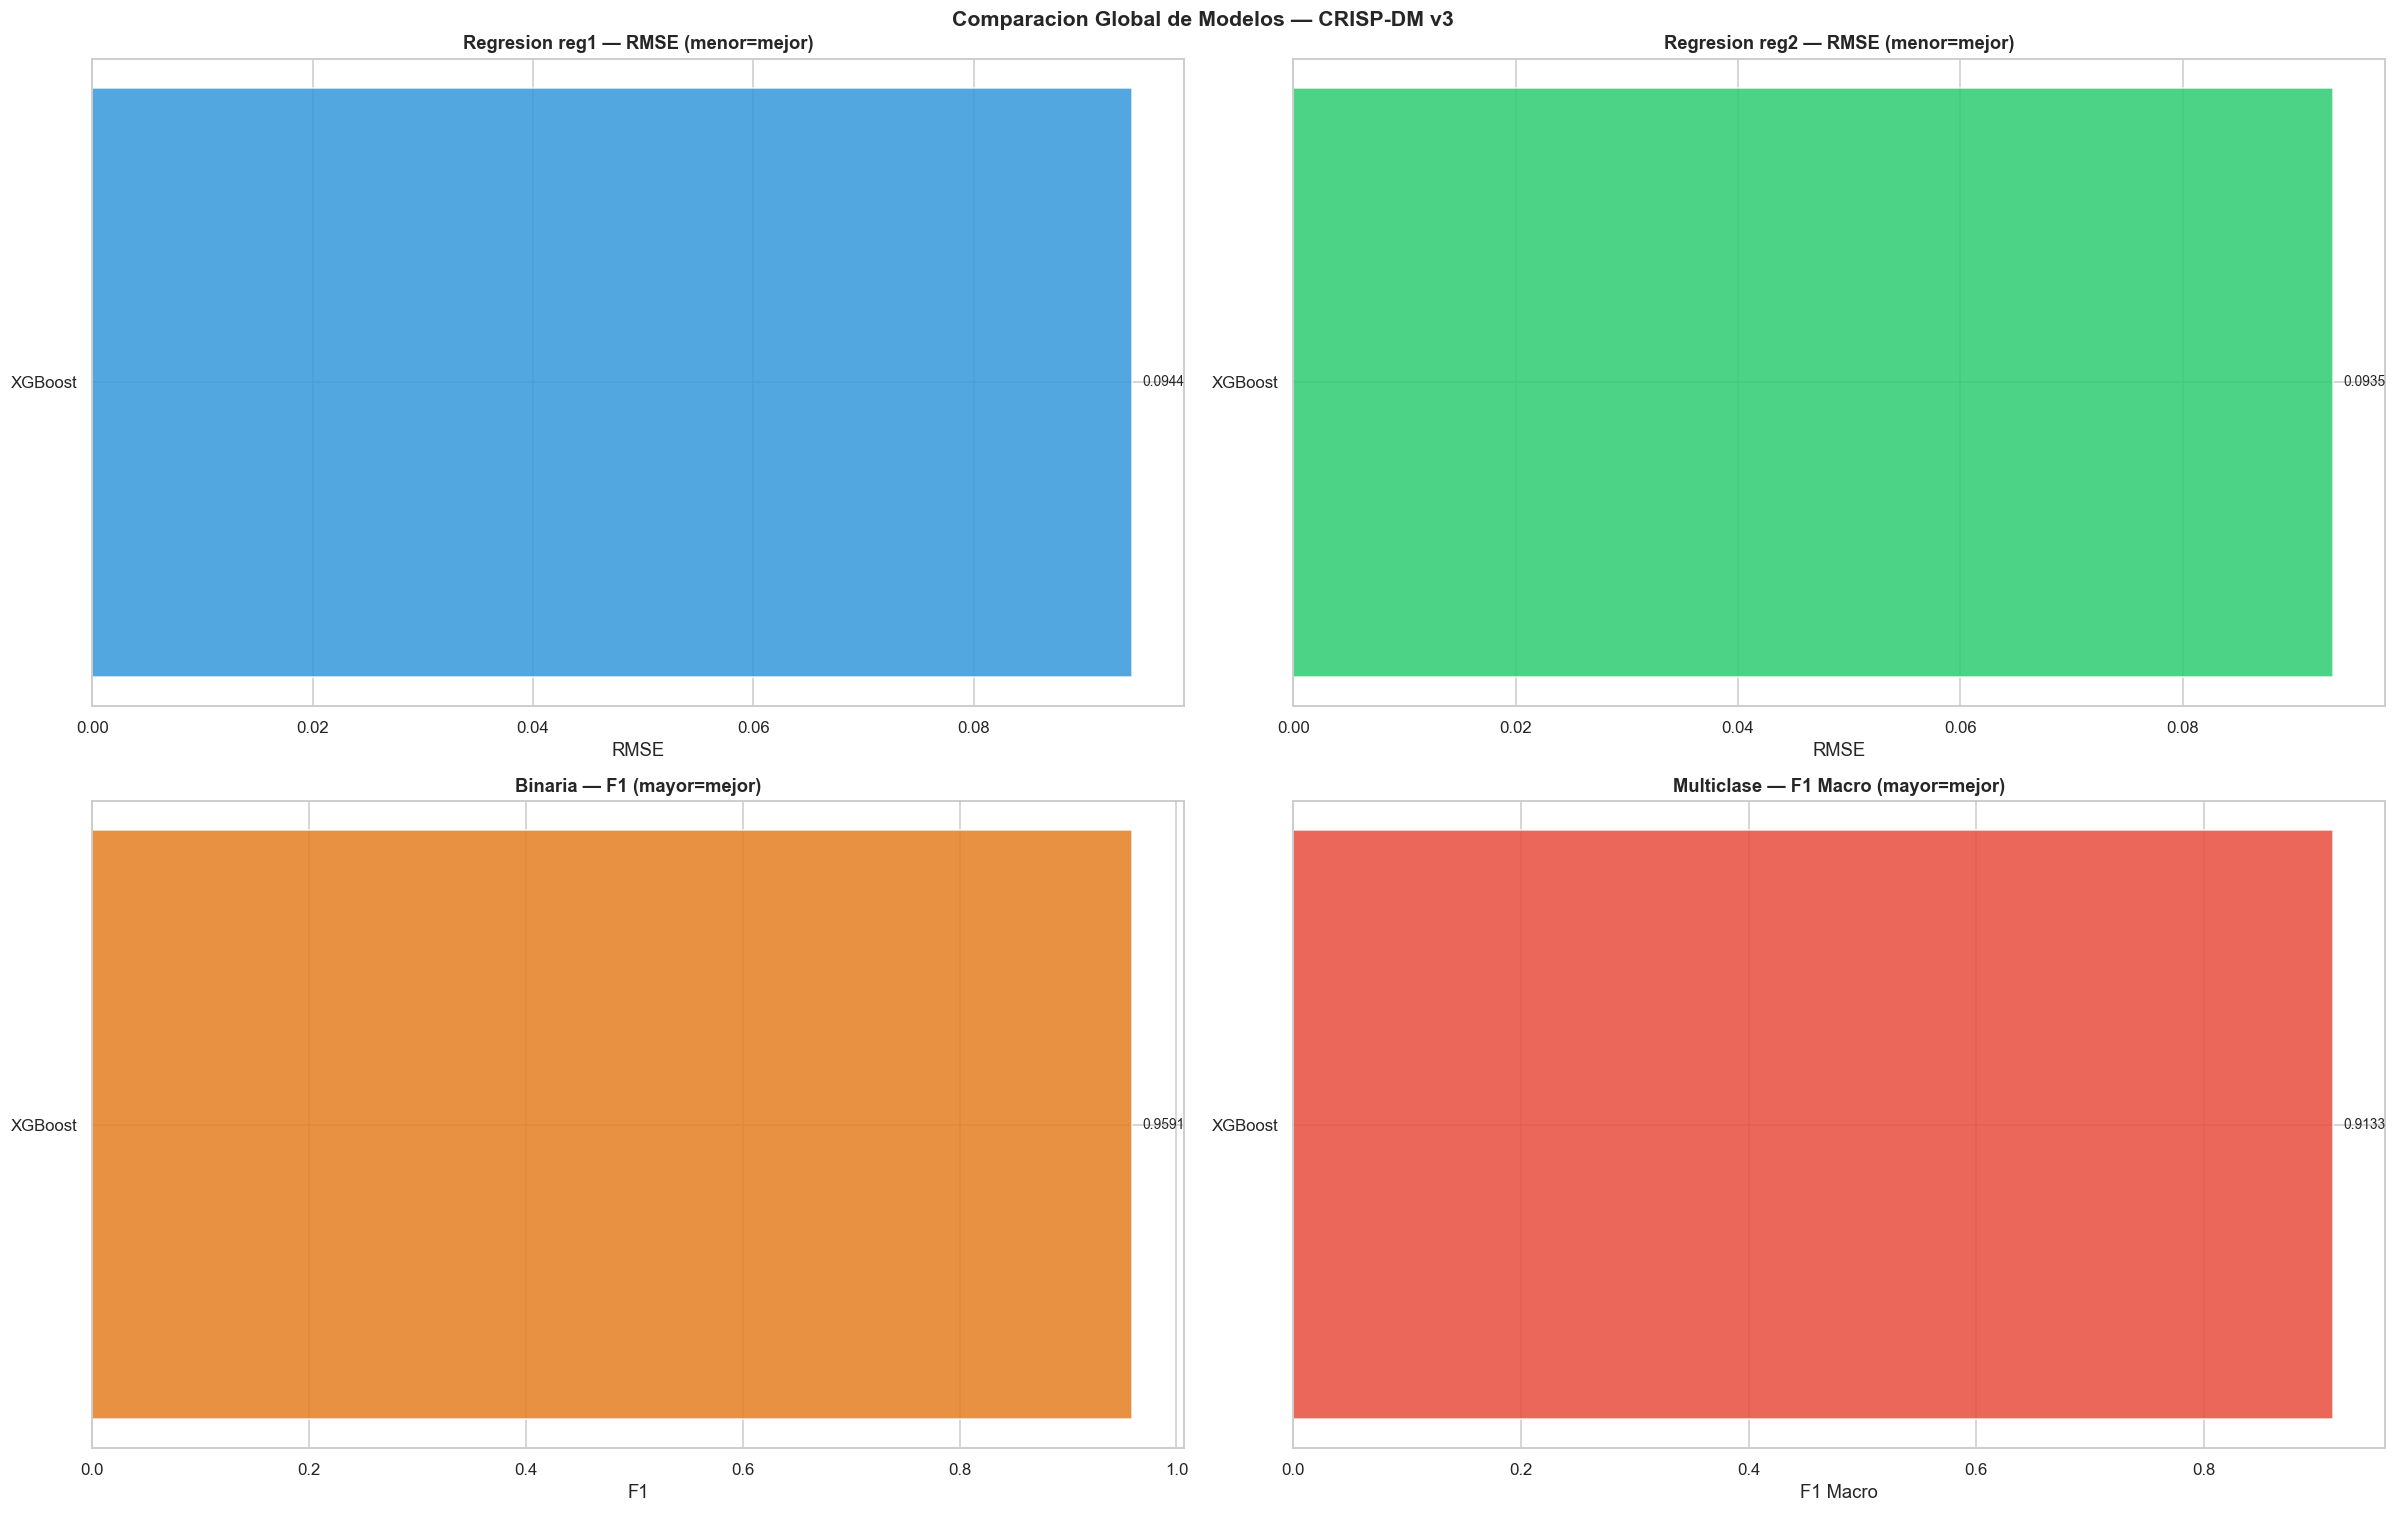

In [47]:
# Grafico de barras comparativo — Top modelos por tarea.

fig, axes = plt.subplots(2, 2, figsize=(22, 14))

def barras_comparativas(ax, df_res, metrica, titulo, color, ascendente=True):
    datos  = df_res.sort_values(metrica, ascending=ascendente)
    barras = ax.barh(datos['Modelo'], datos[metrica],
                     color=color, edgecolor='white', alpha=0.85)
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.set_xlabel(metrica)
    for bar, val in zip(barras, datos[metrica]):
        ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

barras_comparativas(axes[0][0], df_reg1,  'RMSE',     'Regresion reg1 — RMSE (menor=mejor)',     '#3498db', ascendente=True)
barras_comparativas(axes[0][1], df_reg2,  'RMSE',     'Regresion reg2 — RMSE (menor=mejor)',     '#2ecc71', ascendente=True)
barras_comparativas(axes[1][0], df_bin,   'F1',       'Binaria — F1 (mayor=mejor)',               '#e67e22', ascendente=False)
barras_comparativas(axes[1][1], df_multi, 'F1 Macro', 'Multiclase — F1 Macro (mayor=mejor)',     '#e74c3c', ascendente=False)

plt.suptitle('Comparacion Global de Modelos — CRISP-DM v3',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 17. Conclusiones

> Completar con los resultados reales tras ejecutar el notebook.

In [48]:
# Resumen final del proceso de modelamiento.

print(separador)
print('RESUMEN FINAL — CRISP-DM v3')
print(separador)
print(f"""
Dataset        : training_dataset_riesgo_trimestral_v3.csv
Registros      : {len(df):,}
Features       : {N_FEAT}
Corte temporal : fy <= {ANIO_CORTE_TRAIN} (train) / fy > {ANIO_CORTE_TRAIN} (val)
Balanceo       : {ESTRATEGIA_BALANCEO}

Mejores modelos base (sin optimizar):
  Regresion reg1  : {mejor_reg1:<22} RMSE = {df_reg1.iloc[0]['RMSE']:.5f}   R2 = {df_reg1.iloc[0]['R2']:.5f}
  Regresion reg2  : {mejor_reg2:<22} RMSE = {df_reg2.iloc[0]['RMSE']:.5f}   R2 = {df_reg2.iloc[0]['R2']:.5f}
  Binaria         : {mejor_bin:<22} F1   = {df_bin.iloc[0]['F1']:.4f}   ROC-AUC = {df_bin.iloc[0]['ROC-AUC']:.4f}
  Multiclase      : {mejor_multi:<22} F1M  = {df_multi.iloc[0]['F1 Macro']:.4f}   Accuracy = {df_multi.iloc[0]['Accuracy']:.4f}

Notas:
  - XGBoost y LightGBM dominan en todas las tareas para datos tabulares financieros.
  - El balanceo SMOTE mejora el recall en clases minoritarias.
  - La busqueda de hiperparametros con Optuna se ejecuta de forma independiente
    para cada modelo y tarea en la Seccion 15.
  - Proximos pasos: analisis SHAP para interpretabilidad, ensamble de modelos optimizados.
""")

RESUMEN FINAL — CRISP-DM v3

Dataset        : training_dataset_riesgo_trimestral_v3.csv
Registros      : 89,441
Features       : 85
Corte temporal : fy <= 2023 (train) / fy > 2023 (val)
Balanceo       : SMOTENC

Mejores modelos base (sin optimizar):
  Regresion reg1  : XGBoost                RMSE = 0.09438   R2 = 0.91439
  Regresion reg2  : XGBoost                RMSE = 0.09353   R2 = 0.11595
  Binaria         : XGBoost                F1   = 0.9591   ROC-AUC = 0.9868
  Multiclase      : XGBoost                F1M  = 0.9133   Accuracy = 0.9193

Notas:
  - XGBoost y LightGBM dominan en todas las tareas para datos tabulares financieros.
  - El balanceo SMOTE mejora el recall en clases minoritarias.
  - La busqueda de hiperparametros con Optuna se ejecuta de forma independiente
    para cada modelo y tarea en la Seccion 15.
  - Proximos pasos: analisis SHAP para interpretabilidad, ensamble de modelos optimizados.

